# 🔎 Análise exploratória dos dados

Este notebook explora a **tabela analítica** montada na etapa anterior: 1,85 milhão de alunos avaliados, 65 variáveis explicativas e a variável resposta. O objetivo é compreender o comportamento dos dados, avaliar distribuições, detectar correlações e identificar as variáveis relevantes, de modo a fundamentar as **decisões de modelagem** da etapa seguinte.

> **Convenção de trabalho:** o desenvolvimento acontece neste notebook, célula a célula, com os resultados salvos. Ao final da etapa, o código estável é promovido para `src/visualization/prod_02_analise_exploratoria.py`.

**Decisões que governam este notebook** (ver [diário de decisões](../docs/decisoes.md)):
- **D-001, grão de modelagem:** a análise acontece no grão do aluno, que é o grão da predição;
- **D-006, seleção guiada por hipóteses:** cada variável responde a uma hipótese declarada em [`docs/hipoteses.md`](../docs/hipoteses.md), formulada antes da medição.

---

## Roteiro

A análise está organizada em **duas partes**, que vão do simples ao complexo.

A **Parte I** descreve os dados sem relacionar as variáveis entre si: o que se quer prever, onde o problema se concentra, como cada variável se distribui e que problemas de qualidade existem. A **Parte II** confronta as variáveis explicativas com a resposta e entre elas, até chegar ao conjunto de variáveis e aos tratamentos que seguem para a modelagem.

A análise começa pela descrição porque o sentido de uma relação depende da variável envolvida. Na energia elétrica da rede pública, por exemplo, quase todas as redes estão perto de 100%, e uma diferença na taxa de alfabetização entre faixas dessa variável reflete apenas as poucas redes que ficam abaixo desse patamar.

A etapa descritiva também funcionou como controle de qualidade. Foi nela que apareceram três erros de construção da base: o percentual de escolas rurais estava zerado, e as variáveis de alunos por sala e de transporte escolar usavam o denominador errado. Sem essa etapa, a análise de relações teria concluído que ruralidade e transporte não influenciam a alfabetização, quando o problema estava no cálculo das variáveis.

### Parte I · Descrever

| Seção | Etapa | O que responde |
|---|---|---|
| 1 | Visão geral da base | dimensões, tipos e preenchimento das colunas |
| 2 | A variável resposta | o que se quer prever, como se distribui e de onde vem |
| 3 | A resposta no território | onde estão os alunos não alfabetizados, por estado e região |
| 4 | Metas e evolução | quantos municípios estão abaixo da meta pactuada e como o resultado mudou entre os ciclos |
| 5 | Univariada: variáveis numéricas | a forma de cada distribuição |
| 6 | Univariada: variáveis categóricas | frequências e cardinalidade |
| 7 | Qualidade dos dados | valores extremos, assimetria e ausências |

### Parte II · Relacionar

| Seção | Etapa | O que responde |
|---|---|---|
| 8 | Bivariada: numéricas e resposta | a forma e a intensidade da relação de cada variável com a resposta |
| 9 | Correlações | a associação com a resposta e entre as explicativas |
| 10 | Multicolinearidade | quantos conceitos distintos existem de fato entre as variáveis |
| 11 | Variáveis relevantes | o ranking das variáveis, lido contra as hipóteses |
| 12 | Síntese e decisões | o que fica, o que sai e como cada variável será tratada |

O notebook termina com os **principais achados e as questões em aberto**, que amparam o README do projeto.

📌 **Onde estão as variáveis categóricas na Parte II.** A relação entre as categóricas e a resposta não tem seção própria: a rede de ensino é cruzada com a resposta na seção 2, e a UF e a região, na seção 3. Uma seção separada repetiria os mesmos gráficos.

📌 **Duas leituras do mesmo dado.** A predição acontece no grão do aluno, e nesse grão os municípios grandes pesam mais: São Paulo sozinho reúne cerca de 5% dos alunos avaliados no país. As políticas públicas, porém, são decididas no grão do município, onde São Paulo é um entre 5.517. Sempre que as duas leituras divergem, a análise apresenta ambas.

⚠️ **Qual base cada parte usa.** A **Parte I** usa a **base completa**: ela descreve o objeto de estudo, e os achados sobre território, metas e evolução valem para a população inteira de alunos avaliados, e não para uma amostra dela. A **Parte II** usa apenas a **partição de treino**, porque dela saem as decisões do modelo, como quais variáveis manter, como transformá-las e como imputar ausências. Uma decisão tomada depois de examinar o conjunto de teste deixa de ser testável nele, porque a informação já entrou na escolha.

---

## 1. Visão geral da base

**Passos desta seção:** (1.1) configurar o acesso ao data lake; (1.2) carregar a tabela e conferir a partição; (1.3) inventariar as colunas quanto a tipo, preenchimento e cardinalidade.

> 📌 **Nota para reprodução:** este notebook lê `config/config.json`, que não é versionado. Crie o seu a partir de `config/config.example.json`, apontando para o projeto e o bucket onde a pipeline da fase anterior foi executada.

In [290]:
# --- 1.1 Configuração e acesso ao data lake ---
import io
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydata_google_auth
from google.cloud import storage

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 170)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

CFG = json.loads(Path("../config/config.json").read_text(encoding="utf-8"))
PROJETO_GCP = CFG["projeto_gcp"]
BUCKET_LAKE = CFG["bucket_lake"]

ESCOPOS = ["https://www.googleapis.com/auth/cloud-platform"]
credenciais = pydata_google_auth.get_user_credentials(ESCOPOS)
credenciais = credenciais.with_quota_project(PROJETO_GCP)
cliente_storage = storage.Client(project=PROJETO_GCP, credentials=credenciais)


def ler_lake(area: str, tabela: str) -> pd.DataFrame:
    """Lê a partição mais recente de uma tabela do lake.

    O arquivo é baixado e aberto a partir da memória: a leitura pelo
    caminho gs:// depende de I/O assíncrono e trava dentro do kernel do
    Jupyter, comportamento observado na etapa anterior.
    """
    particoes = sorted({
        b.name.split("/")[2]
        for b in cliente_storage.list_blobs(BUCKET_LAKE, prefix=f"{area}/{tabela}/")
        if len(b.name.split("/")) > 2
    })
    if not particoes:
        raise FileNotFoundError(
            f"Tabela '{tabela}' não encontrada em {area}/. "
            "Execute antes src/preprocessing/prod_01_base_analitica.py."
        )
    caminho = f"{area}/{tabela}/{particoes[-1]}/{tabela}.parquet"
    blob = cliente_storage.bucket(BUCKET_LAKE).blob(caminho)
    print(f"  lendo {caminho}")
    return pd.read_parquet(io.BytesIO(blob.download_as_bytes()))


print(f"Lake: gs://{BUCKET_LAKE}/")
print(f"Projeto GCP: {PROJETO_GCP}")
print("Setup ok")

Lake: gs://tech-challenge-fase2-lake-rm373453/
Projeto GCP: tech-challenge-fase2
Setup ok


### 1.2 Carregar a base e conferir a partição

A tabela já vem particionada em treino, validação e teste, com o sorteio feito **por município** para que nenhum aluno de um mesmo território apareça em dois conjuntos. A Parte I deste notebook usa a base completa; a partição de treino é separada aqui para uso na Parte II.

O equilíbrio da partição é conferido numa variável conhecida antes da prova, o desempenho da rede no ciclo anterior, e não na própria resposta: comparar a taxa de alfabetização entre as partições seria olhar o resultado da validação e do teste. Médias próximas nas três partições indicam que o sorteio por município não produziu conjuntos desbalanceados.

In [291]:
# --- 1.2 Carregar a base e conferir a partição ---
abt = ler_lake("ml", "abt_alfabetizacao")
dicionario = pd.read_csv("../reports/dicionario_dados.csv")

# Colunas que não são variáveis explicativas: chave, resposta, controle
# e os carimbos que a gravação acrescenta ao Parquet
CONTROLES = {"ano", "id_municipio", "alvo", "peso_aluno", "particao"}
METADADOS_GRAVACAO = {"_processing_timestamp", "data_processamento"}
FEATURES = [c for c in abt.columns if c not in CONTROLES | METADADOS_GRAVACAO]
NUMERICAS = [c for c in FEATURES if pd.api.types.is_numeric_dtype(abt[c])]
CATEGORICAS = [c for c in FEATURES if c not in NUMERICAS]

# Trava: a tabela e o dicionário precisam falar da mesma coisa
sem_descricao = [c for c in FEATURES if c not in set(dicionario["variavel"])]
if sem_descricao:
    raise RuntimeError(f"Variáveis sem descrição no dicionário: {sem_descricao}")

treino = abt[abt["particao"] == "treino"].copy()

# Parte I (seções 1 a 7) usa a base completa: descreve a população.
# Parte II (seções 8 a 12) usa só o treino: dela saem as decisões do modelo.
base = abt

print()
print("DIMENSÕES")
print(f"  base completa       {len(abt):>10,} linhas x {len(abt.columns):>2} colunas")
print(f"  partição de treino  {len(treino):>10,} linhas  "
      f"({len(treino)/len(abt):.0%})")
print(f"  municípios          {treino['id_municipio'].nunique():>10,}")
print()
print("COMPOSIÇÃO DAS COLUNAS")
print(f"  variáveis explicativas    {len(FEATURES):>3}  "
      f"({len(NUMERICAS)} numéricas, {len(CATEGORICAS)} categóricas)")
print(f"  chave, resposta e controle{len(CONTROLES):>3}")
print()
print("TAMANHO DAS PARTIÇÕES")
print(abt["particao"].value_counts().to_frame("alunos")
      .assign(pct=lambda d: (100*d["alunos"]/len(abt)).round(1)).to_string())
print()
print(f"Taxa de alfabetização na partição de treino: {treino['alvo'].mean():.1%}")
print()
print("CONFERÊNCIA DA PARTIÇÃO, SEM OLHAR A RESPOSTA DAS OUTRAS PARTIÇÕES")
# O equilíbrio é conferido numa variável conhecida antes da prova, o
# desempenho da rede no ciclo anterior. Comparar a própria resposta entre
# as partições seria olhar o resultado da validação e do teste.
print(abt.groupby("particao")["rede_taxa_ant"]
      .agg(media="mean", mediana="median", desvio="std").round(1)
      .reindex(["treino", "validacao", "teste"]).to_string())

  lendo ml/abt_alfabetizacao/data_processamento=2026-09-14/abt_alfabetizacao.parquet

DIMENSÕES
  base completa        1,851,852 linhas x 71 colunas
  partição de treino   1,156,013 linhas  (62%)
  municípios               3,310

COMPOSIÇÃO DAS COLUNAS
  variáveis explicativas     65  (62 numéricas, 3 categóricas)
  chave, resposta e controle  5

TAMANHO DAS PARTIÇÕES
            alunos   pct
particao                
treino     1156013  62.4
validacao   384045  20.7
teste       311794  16.8

Taxa de alfabetização na partição de treino: 59.4%

CONFERÊNCIA DA PARTIÇÃO, SEM OLHAR A RESPOSTA DAS OUTRAS PARTIÇÕES
           media  mediana  desvio
particao                         
treino      56.4     55.6    15.6
validacao   56.1     56.2    14.7
teste       58.1     56.2    16.1


### 1.3 Inventário das colunas

Retrato de cada coluna antes de qualquer gráfico: tipo, preenchimento, valores distintos e medidas de posição.

⚠️ **Motivo deste passo.** Na etapa anterior, a variável `esc_pct_rural` ficou **constante zero** desde que foi criada, porque o filtro na consulta comparava com um texto onde a fonte grava um código, e nunca casou. Ela atravessou a auditoria contra vazamento e o dicionário de dados sem que nada acusasse, porque todas as verificações conferiam **estrutura** (existe, tem descrição, não vaza) e nenhuma olhava o **valor**. Uma coluna inteira de zeros passa em todos aqueles testes.

Três sinalizadores automáticos substituem a inspeção visual: variável sem variação, com cobertura baixa ou concentrada em zero.

In [292]:
# --- 1.3 Inventário e sinalizadores de qualidade ---
def inventariar(df: pd.DataFrame, colunas: list) -> pd.DataFrame:
    """Retrato de cada coluna: tipo, preenchimento, dispersão, concentração."""
    linhas = []
    for col in colunas:
        s = df[col]
        reg = {"variavel": col,
               "tipo": str(s.dtype),
               "preenchido_pct": round(100 * s.notna().mean(), 1),
               "distintos": int(s.nunique(dropna=True))}
        if pd.api.types.is_numeric_dtype(s):
            v = s.dropna()
            if len(v):
                reg.update({"media": round(float(v.mean()), 2),
                            "desvio": round(float(v.std()), 2),
                            "minimo": round(float(v.min()), 2),
                            "mediana": round(float(v.median()), 2),
                            "maximo": round(float(v.max()), 2),
                            "zeros_pct": round(100 * float((v == 0).mean()), 1)})
        linhas.append(reg)
    return pd.DataFrame(linhas)


inventario = inventariar(base, FEATURES).merge(
    dicionario[["variavel", "hipotese", "natureza"]], on="variavel", how="left")

inventario["alerta"] = ""
inventario.loc[inventario["distintos"] <= 1, "alerta"] += "sem variação; "
inventario.loc[inventario["preenchido_pct"] < 80, "alerta"] += "cobertura baixa; "
if "zeros_pct" in inventario.columns:
    inventario.loc[inventario["zeros_pct"] > 90, "alerta"] += "quase tudo zero; "

alertas = inventario[inventario["alerta"] != ""]
print(f"{len(inventario)} variáveis inventariadas · {len(alertas)} com alerta")
print()
if len(alertas):
    print(alertas[["variavel", "hipotese", "preenchido_pct",
                   "distintos", "alerta"]].to_string(index=False))
else:
    print("Nenhuma variável constante, com cobertura baixa ou degenerada.")

COLS = ["variavel", "hipotese", "natureza", "tipo", "preenchido_pct",
        "distintos", "media", "desvio", "minimo", "mediana", "maximo",
        "zeros_pct", "alerta"]
inventario = inventario[[col for col in COLS if col in inventario.columns]]

# O DataFrame fica disponível para inspeção e filtro no próprio notebook.
# Exemplos: inventario.query("hipotese.str.startswith('H1')")
#           inventario.sort_values("preenchido_pct")
inventario

65 variáveis inventariadas · 3 com alerta

             variavel               hipotese  preenchido_pct  distintos            alerta
 mun_participacao_ant H8 inercia territorial            76.9       2483 cobertura baixa; 
mun_taxa_ajustada_ant H8 inercia territorial            76.9       4811 cobertura baixa; 
       mun_alunos_ant     controle de escala            76.9        905 cobertura baixa; 


,variavel,hipotese,natureza,tipo,preenchido_pct,distintos,media,desvio,minimo,mediana,maximo,zeros_pct,alerta
0,rede_nome,controle do aluno,direta,str,100.0,3,NaN,NaN,NaN,NaN,NaN,NaN,
1,rede_taxa_ant,H8 inercia territorial,direta,float64,98.1,4059,56.63,15.55,3.41,56.19,100.00,0.0,
2,rede_media_portugues_ant,H8 inercia territorial,direta,float64,98.1,6397,745.60,20.12,673.30,743.27,868.46,0.0,
3,uf_rede_taxa_ant,H8 inercia territorial,derivada,float64,98.1,46,60.53,13.33,27.53,59.21,93.16,0.0,
4,rede_vs_uf,H8 inercia territorial,derivada,float64,98.1,5245,-3.89,11.59,-66.43,-4.47,58.21,0.4,
5,rede_vs_municipio,H8 inercia territorial,derivada,float64,89.2,1690,0.01,3.56,-65.06,0.00,64.39,54.1,
6,mun_taxa_ant,H8 inercia territorial,direta,float64,89.2,3517,56.70,15.60,4.56,56.01,100.00,0.0,
7,mun_participacao_ant,H8 inercia territorial,direta,float64,76.9,2483,86.60,7.00,27.49,86.78,100.00,0.0,cobertura baixa;
8,mun_taxa_ajustada_ant,H8 inercia territorial,derivada,float64,76.9,4811,50.49,16.19,4.08,49.28,100.00,0.0,cobertura baixa;
9,mun_alunos_ant,controle de escala,direta,float64,76.9,905,3999.27,8554.21,9.00,889.00,44858.00,0.0,cobertura baixa;


---

## 2. A variável resposta

**Passos desta seção:** (2.1) como o alvo se distribui entre as classes; (2.2) de onde ele vem e por que a fronteira é delicada.

O desenho da variável resposta condiciona a escolha do algoritmo, a métrica de avaliação e a interpretação dos resultados, e por isso é examinado antes das variáveis explicativas.

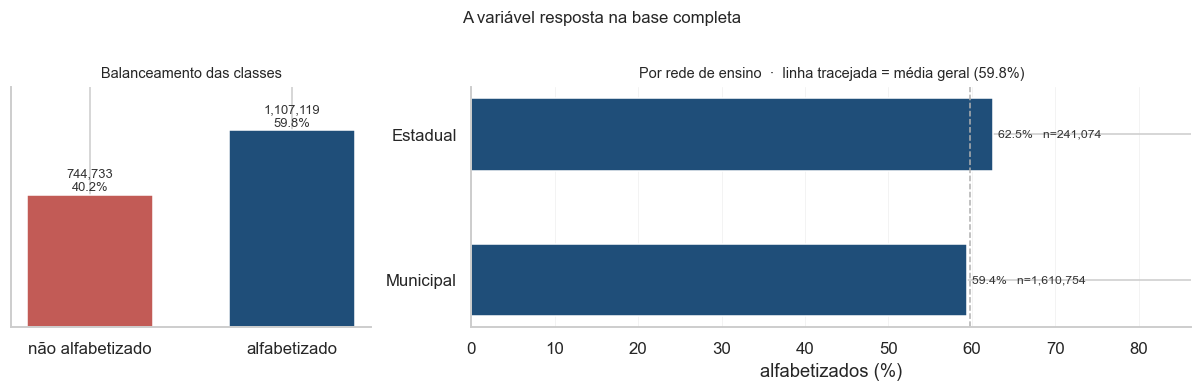

Taxa de alfabetização: 59.8%
Razão entre as classes: 1.49 para 1

Leitura: as classes estão praticamente equilibradas, o que dispensa
técnicas de reamostragem. Isso não torna a acurácia uma boa métrica:
prever sempre a classe majoritária já acerta 59.8%,
sem qualquer capacidade preditiva.


In [293]:
# --- 2.1 Distribuição da variável resposta ---
contagem = base["alvo"].value_counts().sort_index()
taxa = base["alvo"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4),
                               gridspec_kw={"width_ratios": [1, 2]})

barras = ax1.bar(["não alfabetizado", "alfabetizado"], contagem.values,
                 color=["#c25b56", "#1f4e79"], width=.62)
for b, v in zip(barras, contagem.values):
    ax1.text(b.get_x() + b.get_width()/2, v + max(contagem)*.02,
             f"{v:,}\n{100*v/len(base):.1f}%", ha="center",
             fontsize=8.5, color="#333")
ax1.set_ylim(0, max(contagem) * 1.22)
ax1.set_yticks([])
ax1.set_title("Balanceamento das classes", fontsize=9.5)

por_rede = (base.groupby("rede_nome", observed=True)
            .agg(alunos=("alvo", "size"), taxa=("alvo", "mean"))
            .sort_values("alunos", ascending=False))
por_rede = por_rede[por_rede["alunos"] > 100]
ax2.barh(por_rede.index, 100 * por_rede["taxa"], color="#1f4e79", height=.5)
ax2.axvline(100 * taxa, color="#b0b0b0", ls="--", lw=1)
for i, (nome, r) in enumerate(por_rede.iterrows()):
    ax2.text(100*r["taxa"] + .6, i, f"{100*r['taxa']:.1f}%   "
             f"n={int(r['alunos']):,}", va="center", fontsize=8, color="#333")
ax2.set_xlim(0, max(100 * por_rede["taxa"]) * 1.38)
ax2.set_xlabel("alfabetizados (%)")
ax2.set_title(f"Por rede de ensino  ·  linha tracejada = média geral "
              f"({100*taxa:.1f}%)", fontsize=9.5)
ax2.grid(axis="x", alpha=.25, lw=.6)

fig.suptitle("A variável resposta na base completa", fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

print(f"Taxa de alfabetização: {taxa:.1%}")
print(f"Razão entre as classes: {contagem[1]/contagem[0]:.2f} para 1")
print()
print("Leitura: as classes estão praticamente equilibradas, o que dispensa")
print("técnicas de reamostragem. Isso não torna a acurácia uma boa métrica:")
print(f"prever sempre a classe majoritária já acerta {max(contagem)/len(base):.1%},")
print("sem qualquer capacidade preditiva.")

### 2.2 Origem da variável resposta e o ponto de corte

🎓 **Conceito, dicotomização de uma variável contínua:** a variável resposta não é uma observação direta. Ela nasce de um corte na **proficiência**, a nota do aluno na avaliação de alfabetização do 2º ano: quem alcança 743 pontos é classificado como alfabetizado. A nota é calculada por Teoria de Resposta ao Item, o mesmo método do SAEB, em que o valor reflete a dificuldade dos itens acertados e não apenas a quantidade deles.

Transformar uma medida contínua em binária descarta informação, e a posição do corte determina o quanto. Corte em região de baixa densidade deixa poucos alunos próximos da fronteira, e a classificação é estável. Corte no ponto de maior concentração deixa uma parcela grande a poucos pontos de mudar de classe.

> ⚠️ A proficiência **não** é variável explicativa do modelo. Usá-la seria prever `nota >= 743` a partir da própria nota. Ela é lida aqui, da camada Silver, apenas para descrever a origem do alvo.

  lendo silver/alunos/data_processamento=2026-07-11/alunos.parquet


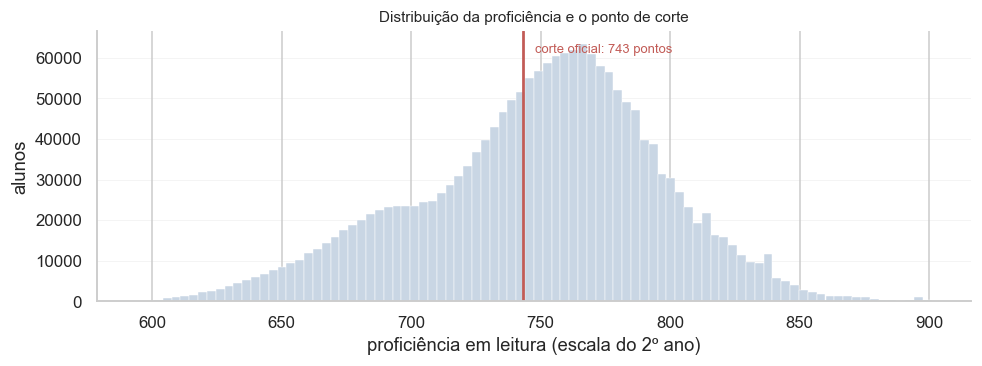

n = 1,851,852    média 749.0    desvio 47.0    mediana 754.0

QUANTOS ALUNOS FICAM PRÓXIMOS DA LINHA DE CORTE
  a menos de  5 pontos de 743:    153,837  ( 8.3%)
  a menos de 10 pontos de 743:    306,759  (16.6%)
  a menos de 20 pontos de 743:    600,301  (32.4%)
  a menos de 30 pontos de 743:    871,142  (47.0%)

Leitura: o corte cai praticamente sobre a moda da distribuição, que é
a região mais densa. Para a parcela que fica a poucos pontos da linha,
a diferença entre as duas classes é estreita e sujeita a ruído.


In [294]:
# --- 2.2 A distribuição de origem e a linha de corte ---
CORTE = 743
prof = ler_lake("silver", "alunos")
# Apenas os municípios da base analítica
prof = prof[prof["id_municipio"].isin(base["id_municipio"].unique())]
prof = prof.loc[prof["presente"] & (prof["ano"] == 2024), "proficiencia"].dropna()

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist(prof, bins=90, color="#c9d6e4", edgecolor="white", linewidth=.3)
ax.axvline(CORTE, color="#c25b56", lw=1.8)
ax.text(CORTE + 5, ax.get_ylim()[1] * .92,
        f"corte oficial: {CORTE} pontos", color="#c25b56", fontsize=8.5)
ax.set_xlabel("proficiência em leitura (escala do 2º ano)")
ax.set_ylabel("alunos")
ax.set_title("Distribuição da proficiência e o ponto de corte",
             fontsize=10)
ax.grid(axis="y", alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

print(f"n = {len(prof):,}    média {prof.mean():.1f}    "
      f"desvio {prof.std():.1f}    mediana {prof.median():.1f}")
print()
print("QUANTOS ALUNOS FICAM PRÓXIMOS DA LINHA DE CORTE")
for j in (5, 10, 20, 30):
    n = int(((prof >= CORTE - j) & (prof < CORTE + j)).sum())
    print(f"  a menos de {j:>2} pontos de {CORTE}:  {n:>9,}  ({n/len(prof):>5.1%})")
print()
print("Leitura: o corte cai praticamente sobre a moda da distribuição, que é")
print("a região mais densa. Para a parcela que fica a poucos pontos da linha,")
print("a diferença entre as duas classes é estreita e sujeita a ruído.")

📌 **Implicações para a modelagem.**

O ponto de corte cai sobre a região de maior densidade da proficiência: 32% dos alunos estão a menos de 20 pontos da linha. Duas consequências decorrem disso.

1. **A acurácia será modesta, qualquer que seja o algoritmo.** A dificuldade está nos dados, e não no modelo: alunos a poucos pontos do corte são quase indistinguíveis entre si, e trocar de algoritmo não muda isso. Por essa razão, a acurácia não serve como métrica principal.

2. **O modelo deve ser lido pela probabilidade, e não apenas pela classe.** A maior parte dos classificadores não produz a classe diretamente: estima a probabilidade de cada classe, e a classe resulta de um limiar aplicado a ela, por padrão 50%. No Scikit-learn, `predict_proba` devolve a probabilidade e `predict` devolve a classe com o limiar já aplicado. Um aluno com 51% de chance de ser alfabetizado e outro com 95% recebem a mesma classe, mas pedem ações diferentes, e só a probabilidade distingue os dois. A avaliação usará, por isso, métricas de probabilidade, como AUC e calibração, em vez de acurácia. A calibração mede o quanto a probabilidade estimada corresponde à frequência observada; alguns algoritmos, como as florestas aleatórias, costumam precisar de ajuste para isso. A escolha do algoritmo não é feita aqui: ela depende da forma das relações, examinada na seção 8, e da redundância entre as variáveis, na seção 10, e fica registrada na seção 12.

⚠️ **Alternativa considerada e descartada: prever a proficiência contínua e aplicar o corte depois.** A ideia seria aproveitar a informação que o corte descarta. Ela não funciona com esta base, porque todas as variáveis explicativas estão no grão da rede e do município: a base tem 6.536 perfis distintos de variáveis, exatamente o número de combinações de município e rede. Qualquer modelo dá a mesma previsão a todos os alunos de uma mesma rede, e uma regressão sobre a nota estimaria apenas a proficiência média da rede. Aplicar o corte a essa média classificaria a rede inteira de um lado só, quando os alunos de uma mesma rede se espalham por toda a escala: o desvio padrão da proficiência dentro da rede é de 40,5 pontos, contra 47 no conjunto dos alunos. A probabilidade de um classificador binário, ao contrário, estima a fração de alunos alfabetizados da rede, que é a informação útil para a decisão.

---

## 3. A resposta no território

**Passos desta seção:** (3.1) a taxa de cada região, contando alunos e contando municípios; (3.2) a dispersão entre os municípios de cada região; (3.3) a taxa por estado, no mapa; (3.4) o estado de São Paulo por dentro, município a município; (3.5) a rede estadual diante da municipal.

A primeira pergunta de um gestor público diante de um indicador é onde o problema se concentra. Esta seção responde a ela antes de qualquer análise de variáveis, e é também onde as duas variáveis categóricas territoriais, a UF e a região, são cruzadas com a resposta.

🎓 **Conceito, contar alunos ou contar municípios.** A taxa de uma região pode ser calculada de duas formas, e as duas estão certas. Um exemplo com dois municípios:

| | Alunos | Alfabetizados | Taxa |
|---|---:|---:|---:|
| Cidade grande | 1.000 | 500 | 50% |
| Cidade pequena | 10 | 9 | 90% |

- **Taxa entre os alunos:** 509 alfabetizados em 1.010 alunos, ou 50,4%. A cidade grande domina a conta.
- **Média das taxas municipais:** (50% + 90%) / 2, ou 70%. Cada município pesa o mesmo.

A primeira responde quantas crianças da região estão alfabetizadas; a segunda, como está o município típico da região. Quando as duas divergem, é porque municípios grandes e pequenos vivem realidades distintas. Para a política pública, a diferença define o alvo: alcançar o maior número de crianças leva às cidades grandes, e priorizar municípios leva a outro retrato.

> 📌 As estatísticas municipais desta seção usam apenas municípios com ao menos 20 alunos avaliados. Abaixo disso, a taxa oscila por tamanho de amostra: um município com 8 alunos só pode ter taxas múltiplas de 12,5%. O corte exclui 203 municípios, que reúnem 0,16% dos alunos. Ele não elimina todos os valores extremos, porque há municípios maiores com taxas de 0% ou 100%, que são observações legítimas.

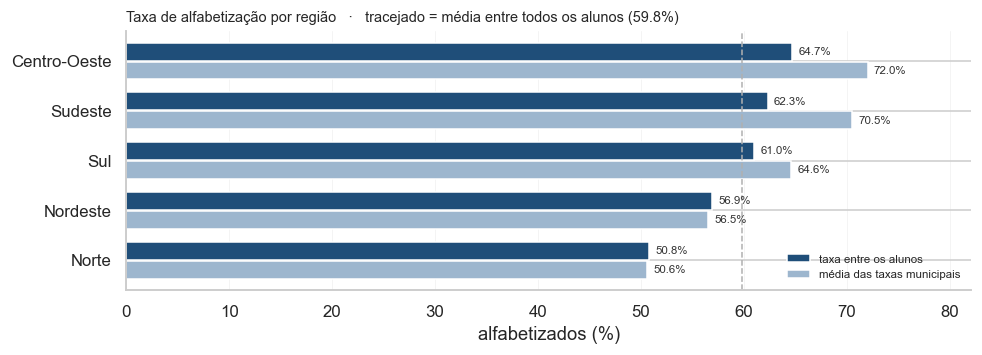

O PESO DAS CIDADES GRANDES NO SUDESTE
  os 10 municípios com mais alunos reúnem 28.1% dos alunos da região
  taxa conjunta desses 10 municípios: 59.0%
  São Paulo capital: 94,373 alunos, taxa 56.6%



,alunos,municipios,taxa_entre_alunos,media_das_taxas_municipais,efeito_do_peso
nome_regiao,,,,,
Norte,188119,432,50.8,50.6,0.2
Nordeste,465488,1750,56.9,56.5,0.4
Sul,278403,1075,61.0,64.6,-3.6
Sudeste,744637,1601,62.3,70.5,-8.2
Centro-Oeste,175205,456,64.7,72.0,-7.3


In [295]:
# --- 3.1 A taxa de cada região, contando alunos e contando municípios ---
if base["sigla_uf"].isna().any() or base["nome_regiao"].isna().any():
    raise RuntimeError(
        "Há alunos sem UF ou região na base. Execute novamente o desenv_01, "
        "que passou a obter o território do Censo Demográfico de 2022.")

taxa_media = 100 * float(base["alvo"].mean())
MIN_ALUNOS = 20   # abaixo disso, a taxa municipal oscila por tamanho de amostra

# Taxa observada de cada município, sem ponderação.
# Serve para descrever o problema; não é variável do modelo, porque é a
# própria resposta agregada.
por_municipio = (base.groupby("id_municipio")
                 .agg(sigla_uf=("sigla_uf", "first"),
                      nome_regiao=("nome_regiao", "first"),
                      alunos=("alvo", "size"),
                      taxa=("alvo", "mean"))
                 .assign(taxa=lambda d: 100 * d["taxa"]))
municipios_estaveis = por_municipio[por_municipio["alunos"] >= MIN_ALUNOS]


def taxa_nos_dois_calculos(chave: str) -> pd.DataFrame:
    """Taxa entre os alunos e média das taxas municipais, por grupo.

    A diferença entre as duas mede o peso dos municípios grandes: ela é
    negativa quando os municípios com mais alunos têm taxa menor.
    """
    return (pd.DataFrame({
                "alunos": base.groupby(chave).size(),
                "municipios": municipios_estaveis.groupby(chave).size(),
                "taxa_entre_alunos": 100 * base.groupby(chave)["alvo"].mean(),
                "media_das_taxas_municipais":
                    municipios_estaveis.groupby(chave)["taxa"].mean()})
            .assign(efeito_do_peso=lambda d: d["taxa_entre_alunos"]
                    - d["media_das_taxas_municipais"])
            .round(1))


por_regiao = taxa_nos_dois_calculos("nome_regiao").sort_values("taxa_entre_alunos")

fig, ax = plt.subplots(figsize=(9, 3.3))
y = np.arange(len(por_regiao))
ax.barh(y + .19, por_regiao["taxa_entre_alunos"], height=.36, color="#1f4e79",
        label="taxa entre os alunos")
ax.barh(y - .19, por_regiao["media_das_taxas_municipais"], height=.36,
        color="#9db6ce", label="média das taxas municipais")
for yi, (a, m) in enumerate(zip(por_regiao["taxa_entre_alunos"],
                                por_regiao["media_das_taxas_municipais"])):
    ax.text(a + .6, yi + .19, f"{a:.1f}%", va="center", fontsize=7.5, color="#333")
    ax.text(m + .6, yi - .19, f"{m:.1f}%", va="center", fontsize=7.5, color="#333")
ax.axvline(taxa_media, color="#b0b0b0", ls="--", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(por_regiao.index)
ax.set_xlim(0, por_regiao[["taxa_entre_alunos",
                           "media_das_taxas_municipais"]].max().max() * 1.14)
ax.set_xlabel("alfabetizados (%)")
ax.set_title(f"Taxa de alfabetização por região   ·   tracejado = média entre "
             f"todos os alunos ({taxa_media:.1f}%)", fontsize=9.5, loc="left")
ax.legend(loc="lower right", fontsize=7.5, frameon=False)
ax.grid(axis="x", alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

# O que puxa a taxa entre os alunos do Sudeste para baixo
sudeste = por_municipio[por_municipio["nome_regiao"] == "Sudeste"]
maiores = sudeste.nlargest(10, "alunos")
print("O PESO DAS CIDADES GRANDES NO SUDESTE")
print(f"  os 10 municípios com mais alunos reúnem "
      f"{maiores['alunos'].sum() / sudeste['alunos'].sum():.1%} dos alunos da região")
print(f"  taxa conjunta desses 10 municípios: "
      f"{np.average(maiores['taxa'], weights=maiores['alunos']):.1f}%")
if "3550308" in por_municipio.index:
    sp = por_municipio.loc["3550308"]
    print(f"  São Paulo capital: {int(sp['alunos']):,} alunos, taxa {sp['taxa']:.1f}%")
print()

por_regiao

**Leitura.** Contando alunos, a taxa vai de 50,8% no Norte a 64,7% no Centro-Oeste. A média das taxas municipais conta outra história em três regiões. No Sudeste, 62,3% dos alunos são alfabetizados, mas a média dos municípios é de 70,5%: a diferença de 8,2 pontos é o peso das cidades grandes. Os dez municípios do Sudeste com mais alunos reúnem 28% dos alunos da região e têm taxa conjunta de 59,0%; só São Paulo capital tem 94 mil alunos, com taxa de 56,6%. O mesmo ocorre, em escala menor, no Centro-Oeste (7,3 pontos) e no Sul (3,6). No Norte e no Nordeste as duas contas praticamente coincidem: ali, municípios grandes e pequenos têm taxas parecidas.

📌 **Consequência para a modelagem.** Uma métrica calculada sobre os alunos será dominada pelas cidades grandes. O desempenho do modelo nos municípios pequenos, que são a maioria das unidades de decisão da política pública, precisa ser verificado à parte na etapa de avaliação.

### 3.2 A dispersão entre os municípios de cada região

A média resume a região num único número; esta célula mostra o quanto os municípios se afastam dela. A tabela traz as estatísticas descritivas da taxa municipal, e o boxplot mostra a mesma informação em forma de distribuição.

🎓 **Conceito, como ler as medidas de dispersão:** o **desvio padrão** mede o afastamento típico em relação à média, em pontos percentuais. O **intervalo entre quartis**, de Q1 a Q3, contém a metade central dos municípios. O **coeficiente de variação** divide o desvio pela média e permite comparar a dispersão de regiões com médias diferentes. Quando a média fica acima da mediana, a distribuição é assimétrica à direita: a maioria dos municípios está abaixo da média, e uma cauda de valores altos a puxa para cima.

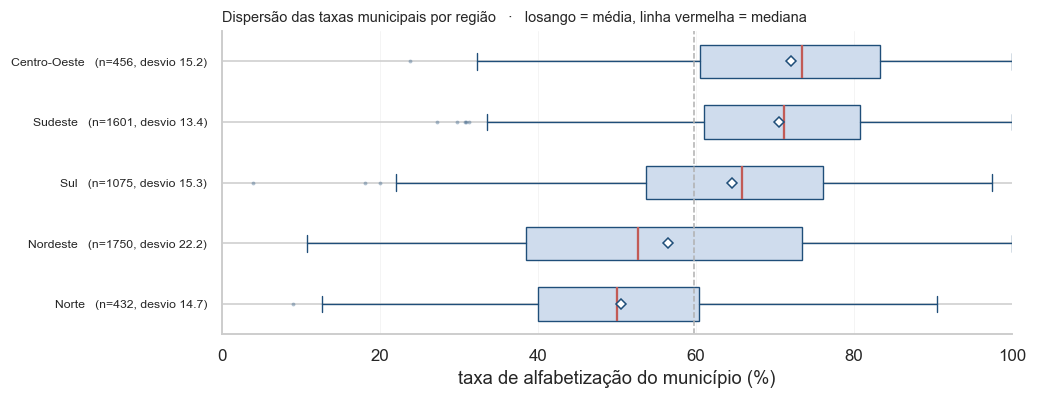

,municipios,media,desvio,minimo,q1,mediana,q3,maximo,coef_variacao
Norte,432,50.6,14.7,9.1,40.1,50.0,60.4,90.5,0.29
Nordeste,1750,56.5,22.2,10.8,38.5,52.6,73.4,100.0,0.39
Sul,1075,64.6,15.3,4.0,53.7,65.8,76.1,97.5,0.24
Sudeste,1601,70.5,13.4,27.3,61.0,71.1,80.7,100.0,0.19
Centro-Oeste,456,72.0,15.2,23.8,60.5,73.4,83.3,100.0,0.21
Brasil,5314,63.2,18.8,4.0,49.2,64.3,77.7,100.0,0.30


In [296]:
# --- 3.2 A dispersão entre os municípios de cada região ---
ordem_regioes = por_regiao.index.tolist()


def descrever(serie: pd.Series) -> dict:
    """Estatísticas descritivas da taxa municipal."""
    q = serie.quantile([.25, .5, .75])
    return {"municipios": len(serie), "media": serie.mean(),
            "desvio": serie.std(), "minimo": serie.min(), "q1": q[.25],
            "mediana": q[.5], "q3": q[.75], "maximo": serie.max(),
            "coef_variacao": serie.std() / serie.mean()}


descritiva_regiao = pd.DataFrame(
    {regiao: descrever(grupo["taxa"])
     for regiao, grupo in municipios_estaveis.groupby("nome_regiao")}
).T.reindex(ordem_regioes)
descritiva_regiao.loc["Brasil"] = descrever(municipios_estaveis["taxa"])
descritiva_regiao = descritiva_regiao.astype(float).round(
    {"media": 1, "desvio": 1, "minimo": 1, "q1": 1, "mediana": 1, "q3": 1,
     "maximo": 1, "coef_variacao": 2})
descritiva_regiao["municipios"] = descritiva_regiao["municipios"].astype(int)

fig, ax = plt.subplots(figsize=(9.5, 3.7))
dados = [municipios_estaveis.loc[municipios_estaveis["nome_regiao"] == r, "taxa"]
         for r in ordem_regioes]
caixas = ax.boxplot(
    dados, vert=False, patch_artist=True, widths=.55, showmeans=True,
    medianprops={"color": "#c25b56", "linewidth": 1.5},
    meanprops={"marker": "D", "markerfacecolor": "white",
               "markeredgecolor": "#1f4e79", "markersize": 5},
    flierprops={"marker": "o", "markersize": 2.5, "alpha": .35,
                "markerfacecolor": "#1f4e79", "markeredgecolor": "none"})
for caixa in caixas["boxes"]:
    caixa.set(facecolor="#cfdced", edgecolor="#1f4e79", linewidth=.9)
for parte in ("whiskers", "caps"):
    for artista in caixas[parte]:
        artista.set(color="#1f4e79", linewidth=.9)
ax.set_yticklabels([f"{r}   (n={len(d)}, desvio {d.std():.1f})"
                    for r, d in zip(ordem_regioes, dados)], fontsize=8)
ax.axvline(taxa_media, color="#b0b0b0", ls="--", lw=1)
ax.set_xlim(0, 100)
ax.set_xlabel("taxa de alfabetização do município (%)")
ax.set_title("Dispersão das taxas municipais por região   ·   "
             "losango = média, linha vermelha = mediana",
             fontsize=9.5, loc="left")
ax.grid(axis="x", alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

descritiva_regiao

**Leitura.** Entre os municípios do país, a taxa média é de 63,2%, com desvio padrão de 18,8 pontos. A dispersão muda muito de uma região para outra. O **Nordeste é a região mais heterogênea**: desvio de 22,2 pontos e coeficiente de variação de 0,39, com a metade central dos municípios entre 38,5% e 73,4%. O Sudeste é a mais homogênea, com desvio de 13,4 e coeficiente de 0,19.

A média do Nordeste fica acima da mediana (56,5% contra 52,6%), sinal de assimetria: a maior parte dos municípios está abaixo da média, e uma cauda de municípios com taxas altas a puxa para cima. A seção 3.3 mostra que é no Nordeste que convivem o estado de menor taxa e o de maior.

📌 **Consequência para a política pública.** Com heterogeneidade tão alta, a região não é uma boa unidade de decisão: tratar o Nordeste como um bloco esconderia municípios em situações opostas. É mais um argumento para que a análise e a priorização aconteçam no município.

### 3.3 A taxa por estado, no mapa

O mapa usa uma escala divergente centrada na média entre todos os alunos: vai do vermelho, nos estados mais abaixo dela, ao azul, nos mais acima, passando pelo amarelo nos estados próximos da média. Ao lado, cada estado aparece com os dois cálculos da seção 3.1, ligados por uma linha cujo comprimento mostra o peso das cidades grandes no estado.

> 📌 Os contornos dos estados vêm da API de malhas territoriais do IBGE, lida diretamente, sem bibliotecas geográficas adicionais.

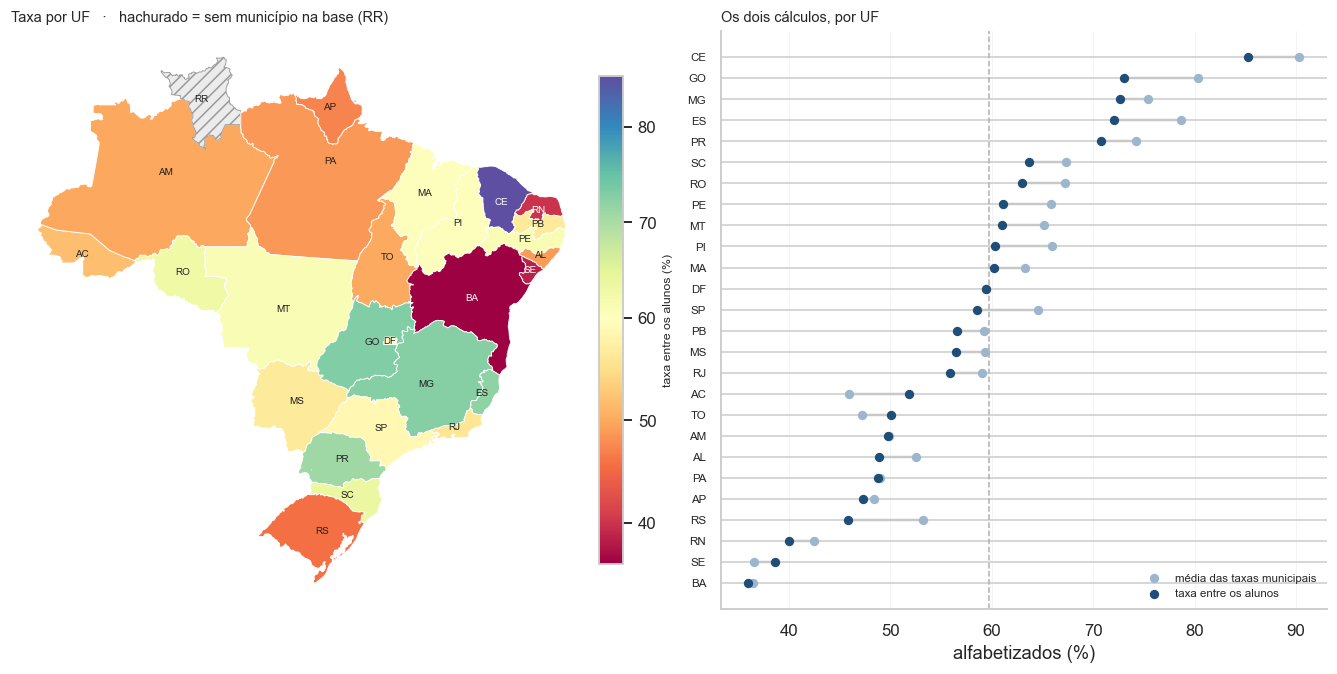

Amplitude entre UFs, contando os alunos: 49.3 pontos percentuais
UFs sem município na base: RR

Estados em que as cidades grandes mais pesam:
          alunos  municipios  taxa_entre_alunos  media_das_taxas_municipais  efeito_do_peso
sigla_uf                                                                                   
RS         89562         399               45.8                        53.2            -7.4
GO         70799         237               73.0                        80.3            -7.3
ES         42751          78               72.1                        78.7            -6.6
SP        395444         615               58.6                        64.6            -6.1
PI         31105         219               60.3                        65.9            -5.6


,alunos,municipios,taxa_entre_alunos,media_das_taxas_municipais,efeito_do_peso
sigla_uf,,,,,
BA,104069,406,36.0,36.5,-0.6
SE,17802,72,38.6,36.6,2.0
RN,22848,154,40.0,42.5,-2.6
RS,89562,399,45.8,53.2,-7.4
AP,11214,16,47.3,48.4,-1.1
PA,83193,144,48.8,49.0,-0.3
AL,31575,102,48.9,52.5,-3.5
AM,46628,62,49.8,49.9,-0.1
TO,16823,136,50.1,47.2,3.0


In [297]:
# --- 3.3 A taxa por estado, no mapa e nos dois cálculos ---
import gzip
import urllib.request

import matplotlib as mpl
from matplotlib.patches import Polygon

# Código IBGE de cada UF, para casar a base com a malha territorial
CODIGO_UF = {"RO": "11", "AC": "12", "AM": "13", "RR": "14", "PA": "15",
             "AP": "16", "TO": "17", "MA": "21", "PI": "22", "CE": "23",
             "RN": "24", "PB": "25", "PE": "26", "AL": "27", "SE": "28",
             "BA": "29", "MG": "31", "ES": "32", "RJ": "33", "SP": "35",
             "PR": "41", "SC": "42", "RS": "43", "MS": "50", "MT": "51",
             "GO": "52", "DF": "53"}
SIGLA_DO_CODIGO = {codigo: sigla for sigla, codigo in CODIGO_UF.items()}


def baixar_malha_ufs() -> list:
    """Contornos das UFs pela API de malhas do IBGE.

    A resposta vem comprimida em gzip, e é descomprimida antes da leitura.
    """
    url = ("https://servicodados.ibge.gov.br/api/v3/malhas/paises/BR"
           "?formato=application/vnd.geo+json&intrarregiao=UF&qualidade=minima")
    with urllib.request.urlopen(url, timeout=60) as resposta:
        bruto = resposta.read()
    if bruto[:2] == b"\x1f\x8b":
        bruto = gzip.decompress(bruto)
    return json.loads(bruto.decode("utf-8"))["features"]


def contornos(geometria: dict) -> list:
    """Contorno externo de cada polígono que compõe a UF."""
    if geometria["type"] == "Polygon":
        return [np.array(geometria["coordinates"][0])]
    return [np.array(poligono[0]) for poligono in geometria["coordinates"]]


por_uf = taxa_nos_dois_calculos("sigla_uf").sort_values("taxa_entre_alunos")
ausentes = sorted(set(CODIGO_UF) - set(por_uf.index))
malha = baixar_malha_ufs()

fig, (ax_mapa, ax_uf) = plt.subplots(
    1, 2, figsize=(13, 6.2), gridspec_kw={"width_ratios": [1.15, 1]})

# mapa: escala divergente em torno da média entre todos os alunos
norma = mpl.colors.TwoSlopeNorm(vcenter=taxa_media,
                                vmin=por_uf["taxa_entre_alunos"].min(),
                                vmax=por_uf["taxa_entre_alunos"].max())
# do vermelho, abaixo da média, ao azul, acima dela, passando pelo amarelo
paleta = plt.get_cmap("Spectral")
for feicao in malha:
    sigla = SIGLA_DO_CODIGO[feicao["properties"]["codarea"]]
    partes = contornos(feicao["geometry"])
    presente = sigla in por_uf.index
    cor = (paleta(norma(por_uf.loc[sigla, "taxa_entre_alunos"]))
           if presente else "#ececec")
    for anel in partes:
        ax_mapa.add_patch(Polygon(anel, closed=True, facecolor=cor,
                                  edgecolor="white" if presente else "#9a9a9a",
                                  linewidth=.6, hatch=None if presente else "///"))
    maior = max(partes, key=len)
    # rótulo claro sobre preenchimento escuro, para continuar legível
    r, g, b = mpl.colors.to_rgb(cor)
    escuro = 0.299 * r + 0.587 * g + 0.114 * b < 0.5
    ax_mapa.text(maior[:, 0].mean(), maior[:, 1].mean(), sigla,
                 ha="center", va="center", fontsize=6.5,
                 color="white" if escuro else "#222")
ax_mapa.autoscale_view()
ax_mapa.set_aspect("equal")
ax_mapa.axis("off")
barra = fig.colorbar(mpl.cm.ScalarMappable(norm=norma, cmap=paleta),
                     ax=ax_mapa, fraction=.035, pad=.01)
barra.set_label("taxa entre os alunos (%)", fontsize=8)
nota_ausentes = (f"   ·   hachurado = sem município na base ({', '.join(ausentes)})"
                 if ausentes else "")
ax_mapa.set_title(f"Taxa por UF{nota_ausentes}", fontsize=9.5, loc="left")

# os dois cálculos lado a lado, ligados por uma linha
y = np.arange(len(por_uf))
ax_uf.hlines(y, por_uf["media_das_taxas_municipais"], por_uf["taxa_entre_alunos"],
             color="#c8c8c8", lw=1.6)
ax_uf.scatter(por_uf["media_das_taxas_municipais"], y, color="#9db6ce", s=26,
              zorder=3, label="média das taxas municipais")
ax_uf.scatter(por_uf["taxa_entre_alunos"], y, color="#1f4e79", s=26, zorder=3,
              label="taxa entre os alunos")
ax_uf.axvline(taxa_media, color="#b0b0b0", ls="--", lw=1)
ax_uf.set_yticks(y)
ax_uf.set_yticklabels(por_uf.index, fontsize=7.5)
ax_uf.set_xlabel("alfabetizados (%)")
ax_uf.set_title("Os dois cálculos, por UF", fontsize=9.5, loc="left")
ax_uf.legend(loc="lower right", fontsize=7.5, frameon=False)
ax_uf.grid(axis="x", alpha=.22, lw=.6)

plt.tight_layout()
plt.show()

print(f"Amplitude entre UFs, contando os alunos: "
      f"{por_uf['taxa_entre_alunos'].max() - por_uf['taxa_entre_alunos'].min():.1f} "
      f"pontos percentuais")
print(f"UFs sem município na base: {', '.join(ausentes) or 'nenhuma'}")
print()
print("Estados em que as cidades grandes mais pesam:")
print(por_uf.nsmallest(5, "efeito_do_peso").to_string())

por_uf

**Leitura.** A variação entre estados é bem maior que entre regiões: contando os alunos, vai de 36,0% na Bahia a 85,3% no Ceará, uma amplitude de 49,3 pontos percentuais. A região esconde parte dela, porque o Nordeste reúne tanto o estado de menor taxa quanto o de maior. O Ceará destaca-se com folga, e é o caso mais citado na literatura de política educacional brasileira por manter, desde 2007, uma política estadual de alfabetização em colaboração com os municípios.

Dois resultados contrariam a intuição socioeconômica. O Rio Grande do Sul, estado de renda alta, está entre as cinco menores taxas (45,8%), e a seção 4 mostra que isso decorre de uma queda abrupta em 2024. E a ordem dos estados não acompanha a riqueza, o que antecipa o resultado da seção 8, em que as variáveis de renda não mostraram gradiente com a alfabetização.

📌 **Roraima não aparece na base.** Nenhum aluno do estado consta da camada de alunos da pipeline de dados, e por isso ele está hachurado no mapa. Para a modelagem, há um segundo ponto a registrar: o Distrito Federal, que é um município único, caiu fora da partição de treino. O modelo encontrará essa UF pela primeira vez na validação ou no teste, e a codificação da UF precisa tratar categorias não vistas no treino.

### 3.4 Um estado por dentro: São Paulo, município a município

A seção 3.1 mostrou que, no Sudeste, as cidades grandes puxam para baixo a taxa entre os alunos. São Paulo é o caso mais nítido: o estado tem a maior rede do país, e a capital sozinha concentra quase um quarto dos alunos paulistas. Este recorte olha o estado por dentro, município a município, para mostrar que a média estadual esconde situações muito distintas e para ver onde a capital se posiciona entre elas.

> 📌 Aparecem hachurados apenas os municípios com menos de 20 alunos avaliados, pelo critério definido na seção 3.1.

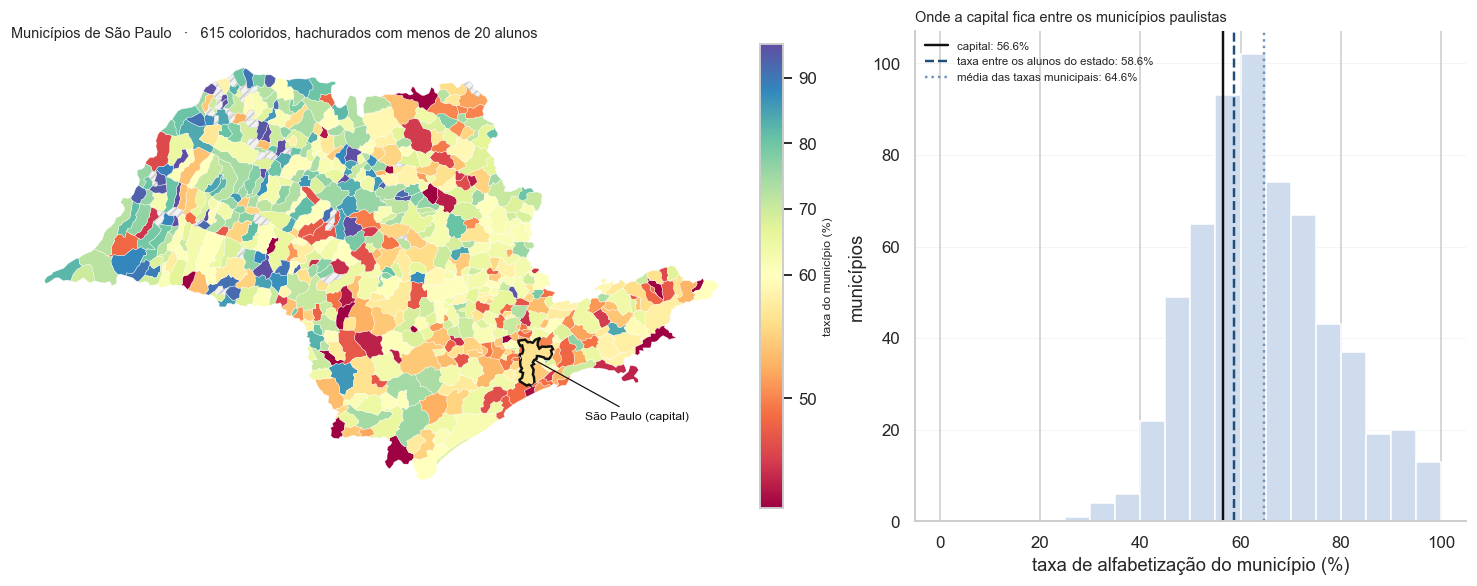

SÃO PAULO POR DENTRO
  municípios na malha do estado                    645
  com ao menos 20 alunos                         615
  alunos do estado                             395,444
  alunos da capital                             94,373  (23.9% do estado)
  taxa da capital                                 56.6%
  municípios paulistas com taxa maior            70.6%

Estatísticas descritivas das taxas municipais do estado:
municipios       615.00
media             64.64
desvio            13.44
minimo            29.82
q1                55.14
mediana           63.08
q3                73.33
maximo           100.00
coef_variacao      0.21


In [298]:
# --- 3.4 São Paulo por dentro, município a município ---
UF_ZOOM, CODIGO_ZOOM, CAPITAL = "SP", "35", "3550308"


def baixar_malha_municipios(codigo_uf: str) -> list:
    """Contornos dos municípios de uma UF, pela mesma API de malhas do IBGE."""
    url = (f"https://servicodados.ibge.gov.br/api/v3/malhas/estados/{codigo_uf}"
           "?formato=application/vnd.geo+json&intrarregiao=municipio&qualidade=minima")
    with urllib.request.urlopen(url, timeout=90) as resposta:
        bruto = resposta.read()
    if bruto[:2] == b"\x1f\x8b":
        bruto = gzip.decompress(bruto)
    return json.loads(bruto.decode("utf-8"))["features"]


malha_sp = baixar_malha_municipios(CODIGO_ZOOM)
estaveis_sp = municipios_estaveis[municipios_estaveis["sigla_uf"] == UF_ZOOM]
resumo_sp = por_uf.loc[UF_ZOOM]
capital = por_municipio.loc[CAPITAL]

fig, (ax_mapa, ax_dist) = plt.subplots(
    1, 2, figsize=(13.5, 5.4), gridspec_kw={"width_ratios": [1.4, 1]})

# mapa municipal, na mesma paleta do mapa dos estados
norma_sp = mpl.colors.TwoSlopeNorm(
    vcenter=taxa_media,
    vmin=min(estaveis_sp["taxa"].quantile(.02), taxa_media - 1),
    vmax=max(estaveis_sp["taxa"].quantile(.98), taxa_media + 1))
for feicao in malha_sp:
    codigo = feicao["properties"]["codarea"]
    partes = contornos(feicao["geometry"])
    if codigo in estaveis_sp.index:
        cor = paleta(norma_sp(estaveis_sp.loc[codigo, "taxa"]))
        borda, hachura = "white", None
    else:
        cor, borda, hachura = "#f2f2f2", "#c8c8c8", "////"
    for anel in partes:
        ax_mapa.add_patch(Polygon(anel, closed=True, facecolor=cor,
                                  edgecolor=borda, linewidth=.25, hatch=hachura))
    if codigo == CAPITAL:
        for anel in partes:
            ax_mapa.add_patch(Polygon(anel, closed=True, fill=False,
                                      edgecolor="#111", linewidth=1.6))
        maior = max(partes, key=len)
        ax_mapa.annotate("São Paulo (capital)",
                         xy=(maior[:, 0].mean(), maior[:, 1].mean()),
                         xytext=(35, -40), textcoords="offset points",
                         fontsize=8, color="#111",
                         arrowprops={"arrowstyle": "-", "color": "#111", "lw": .8})
ax_mapa.autoscale_view()
ax_mapa.set_aspect("equal")
ax_mapa.axis("off")
barra = fig.colorbar(mpl.cm.ScalarMappable(norm=norma_sp, cmap=paleta),
                     ax=ax_mapa, fraction=.03, pad=.01)
barra.set_label("taxa do município (%)", fontsize=8)
ax_mapa.set_title(f"Municípios de São Paulo   ·   {len(estaveis_sp)} coloridos, "
                  f"hachurados com menos de {MIN_ALUNOS} alunos",
                  fontsize=9.5, loc="left")

# a distribuição das taxas municipais, com a capital e as duas médias
ax_dist.hist(estaveis_sp["taxa"], bins=np.arange(0, 101, 5), color="#cfdced",
             edgecolor="white")
linhas = [(capital["taxa"], "#111", "-", f"capital: {capital['taxa']:.1f}%"),
          (resumo_sp["taxa_entre_alunos"], "#1f4e79", "--",
           f"taxa entre os alunos do estado: {resumo_sp['taxa_entre_alunos']:.1f}%"),
          (resumo_sp["media_das_taxas_municipais"], "#6f94b8", ":",
           f"média das taxas municipais: {resumo_sp['media_das_taxas_municipais']:.1f}%")]
for valor, cor, estilo, rotulo in linhas:
    ax_dist.axvline(valor, color=cor, ls=estilo, lw=1.6, label=rotulo)
ax_dist.set_xlabel("taxa de alfabetização do município (%)")
ax_dist.set_ylabel("municípios")
ax_dist.set_title("Onde a capital fica entre os municípios paulistas",
                  fontsize=9.5, loc="left")
ax_dist.legend(fontsize=7.5, frameon=False, loc="upper left")
ax_dist.grid(axis="y", alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

acima_da_capital = (estaveis_sp["taxa"] > capital["taxa"]).mean()
print("SÃO PAULO POR DENTRO")
print("=" * 70)
print(f"  municípios na malha do estado                {len(malha_sp):>7,}")
print(f"  com ao menos {MIN_ALUNOS} alunos                     {len(estaveis_sp):>7,}")
print(f"  alunos do estado                             {int(resumo_sp['alunos']):>7,}")
print(f"  alunos da capital                            {int(capital['alunos']):>7,}  "
      f"({capital['alunos'] / resumo_sp['alunos']:.1%} do estado)")
print(f"  taxa da capital                              {capital['taxa']:>7.1f}%")
print(f"  municípios paulistas com taxa maior          {acima_da_capital:>7.1%}")
print()
print("Estatísticas descritivas das taxas municipais do estado:")
print(pd.Series(descrever(estaveis_sp["taxa"])).round(2).to_string())

**Leitura.** Dos 615 municípios paulistas analisados, sete em cada dez (70,6%) têm taxa de alfabetização maior que a da capital. A capital concentra 23,9% dos alunos do estado e alfabetiza 56,6% deles. A média das taxas municipais do estado é de 64,6%, com desvio de 13,4 pontos e metade dos municípios entre 55,1% e 73,3%. É isso que deixa a taxa entre os alunos do estado (58,6%) 6,1 pontos abaixo da média municipal: no resultado paulista contado por aluno, o peso da capital é grande.

📌 **Consequência para a política pública.** A média estadual não descreve bem nem a capital nem o interior. São Paulo reúne dois problemas distintos: uma rede muito grande, com desempenho abaixo da média nacional, onde está cerca de um quarto das crianças não alfabetizadas do estado; e um interior de desempenho mais alto, com variação considerável entre municípios, onde a priorização precisa ser feita município a município.

### 3.5 Rede estadual e rede municipal

O aluno estuda numa rede mantida pelo município ou pelo estado, e as duas diferem em orçamento, carreira docente e gestão. Esta seção testa uma hipótese formulada antes da medição:

> **Hipótese:** as redes estaduais dispõem de mais recursos que as municipais, estruturam melhor as suas escolas e, por isso, alfabetizam mais.

A hipótese tem duas partes, e as duas precisam ser verificadas. Se a rede estadual alfabetizar mais sem ter infraestrutura melhor, o mecanismo proposto não se sustenta.

Há uma explicação concorrente: a rede estadual pode alfabetizar mais porque atende **famílias em melhor condição**, e não por ter mais recursos. Por isso a comparação inclui, além da infraestrutura, os professores das duas redes e o nível socioeconômico das famílias atendidas (INSE), e confere se a vantagem da rede estadual persiste quando as duas redes atendem públicos semelhantes.

🎓 **Conceito, a armadilha da composição.** A rede estadual só oferece o 2º ano em parte dos municípios, e não nos mesmos lugares que a municipal. Comparar a média nacional das duas redes mistura o efeito da rede com o efeito do território onde cada uma está. A comparação justa é feita **dentro do mesmo município**, onde as duas redes coexistem: cada município contribui com a diferença entre a sua rede estadual e a sua rede municipal, e o resultado é a mediana dessas diferenças.

> 📌 Entram na comparação os municípios com ao menos 20 alunos em cada uma das duas redes, e o gráfico por UF mostra apenas os estados com ao menos 10 municípios nessa condição.

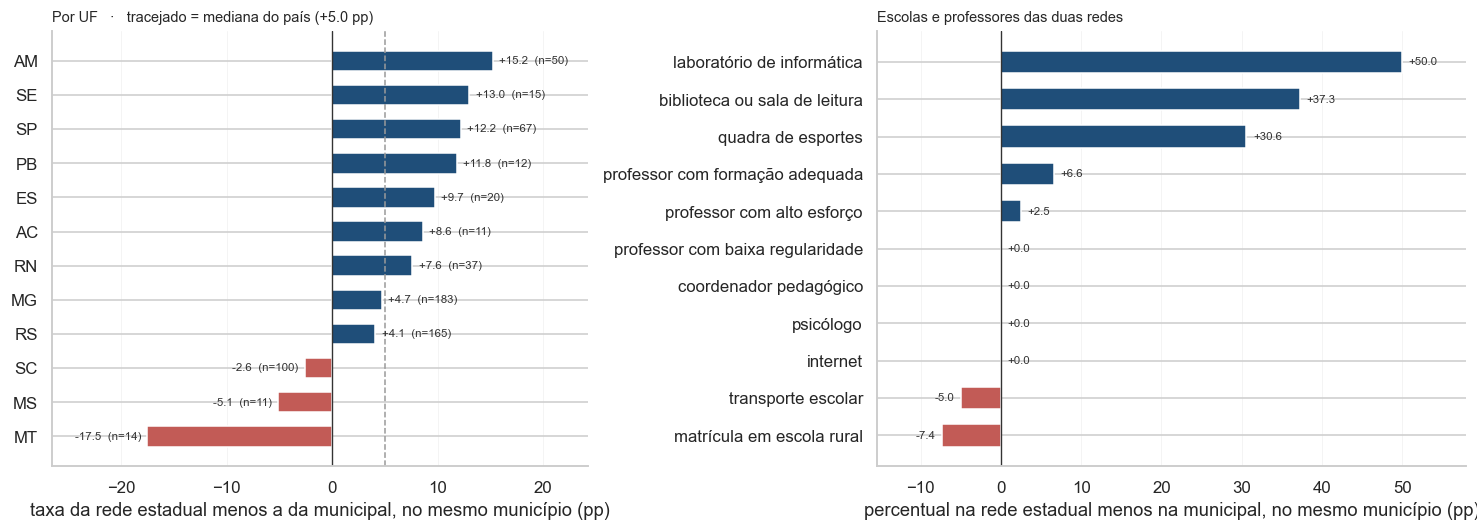

REDE ESTADUAL E REDE MUNICIPAL
Sem controle de território:
            alunos  municipios  taxa
rede_nome                           
Estadual    241074        1085  62.5
Municipal  1610754        5450  59.4

Dentro do mesmo município (732 municípios com as duas redes e ao menos 20 alunos em cada):
  diferença mediana, estadual menos municipal   +5.0 pontos percentuais
  municípios em que a rede estadual alfabetiza mais   62.7%

Escolas, professores e público, estadual menos municipal, no mesmo município:
                                          diferenca_mediana  estadual_maior_pct
biblioteca ou sala de leitura                          37.3                88.8
laboratório de informática                             50.0                92.9
quadra de esportes                                     30.6                80.3
internet                                                0.0                30.5
coordenador pedagógico                                  0.0                47.3
psicólogo 

,municipios,diferenca_mediana,estadual_melhor_pct,alunos_na_estadual_pct
sigla_uf,,,,
MT,14,-17.5,14.3,3.1
MS,11,-5.1,45.5,1.9
SC,100,-2.6,38.0,22.8
RS,165,4.1,63.0,31.8
MG,183,4.7,64.5,21.2
RN,37,7.6,70.3,15.5
AC,11,8.6,72.7,43.8
ES,20,9.7,85.0,5.2
PB,12,11.8,58.3,3.8


In [299]:
# --- 3.5 Rede estadual e rede municipal, dentro do mesmo município ---
REDES = ["Estadual", "Municipal"]
MIN_PARES = 10   # municípios com as duas redes para exibir a UF
INFRA_REDE = {"esc_pct_biblioteca_ou_sala_leitura": "biblioteca ou sala de leitura",
              "esc_pct_lab_informatica": "laboratório de informática",
              "esc_pct_quadra": "quadra de esportes",
              "esc_pct_internet": "internet",
              "esc_pct_coordenador": "coordenador pedagógico",
              "esc_pct_psicologo": "psicólogo",
              "esc_pct_rural": "matrícula em escola rural",
              "esc_pct_transporte": "transporte escolar",
              "esc_alunos_por_sala": "alunos por sala",
              "turma_media_alunos": "alunos por turma",
              "esc_pct_docentes_formacao_adequada": "professor com formação adequada",
              "esc_pct_docentes_baixa_regularidade": "professor com baixa regularidade",
              "esc_pct_docentes_alto_esforco": "professor com alto esforço",
              "esc_alunos_por_docente": "alunos por professor",
              "esc_horas_aula_diarias": "horas-aula diárias",
              "esc_inse_medio": "nível socioeconômico das famílias (INSE)"}
FAIXA_INSE = 0.05   # diferença de INSE entre as redes tratada como semelhante

redes = base[base["rede_nome"].isin(REDES)]

# 1. sem controle de território
sem_controle = (redes.groupby("rede_nome", observed=True)
                .agg(alunos=("alvo", "size"),
                     municipios=("id_municipio", "nunique"),
                     taxa=("alvo", "mean"))
                .assign(taxa=lambda d: (100 * d["taxa"]).round(1)))

# 2. dentro do mesmo município: uma linha por município e rede
por_rede = (redes.groupby(["id_municipio", "rede_nome"], observed=True)
            .agg(sigla_uf=("sigla_uf", "first"),
                 alunos=("alvo", "size"),
                 taxa=("alvo", "mean"),
                 **{v: (v, "first") for v in INFRA_REDE})
            .reset_index())
por_rede["taxa"] = 100 * por_rede["taxa"]
por_rede = por_rede[por_rede["alunos"] >= MIN_ALUNOS]
largo = por_rede.pivot(index="id_municipio", columns="rede_nome")
pares = largo.dropna(subset=[("taxa", "Estadual"), ("taxa", "Municipal")])
diferenca = pares[("taxa", "Estadual")] - pares[("taxa", "Municipal")]
uf_do_par = pares[("sigla_uf", "Estadual")].rename("sigla_uf")

por_uf_rede = pd.DataFrame({
    "municipios": diferenca.groupby(uf_do_par).size(),
    "diferenca_mediana": diferenca.groupby(uf_do_par).median(),
    "estadual_melhor_pct": 100 * (diferenca > 0).groupby(uf_do_par).mean(),
}).round(1)
alunos_uf_rede = redes.groupby(["sigla_uf", "rede_nome"], observed=True).size().unstack()
por_uf_rede["alunos_na_estadual_pct"] = (
    100 * alunos_uf_rede["Estadual"] / alunos_uf_rede.sum(axis=1)).round(1)
comparaveis = (por_uf_rede[por_uf_rede["municipios"] >= MIN_PARES]
               .sort_values("diferenca_mediana"))

# 3. escolas, professores e público das duas redes, no mesmo município
infra_rede = pd.DataFrame({
    rotulo: {"diferenca_mediana":
                 (pares[(v, "Estadual")] - pares[(v, "Municipal")]).median(),
             "estadual_maior_pct":
                 100 * ((pares[(v, "Estadual")] - pares[(v, "Municipal")]) > 0).mean()}
    for v, rotulo in INFRA_REDE.items()}).T.round(1)

# 4. o público atendido: a vantagem da estadual depende de ela atender
#    famílias de nível socioeconômico diferente do da municipal?
dif_inse = pares[("esc_inse_medio", "Estadual")] - pares[("esc_inse_medio", "Municipal")]
grupo_inse = pd.cut(dif_inse, [-float("inf"), -FAIXA_INSE, FAIXA_INSE, float("inf")],
                    labels=["estadual atende famílias de nível menor",
                            "nível semelhante",
                            "estadual atende famílias de nível maior"])
por_publico = (pd.DataFrame({"diferenca": diferenca, "grupo": grupo_inse})
               .dropna()
               .groupby("grupo", observed=True)["diferenca"]
               .agg(municipios="size", diferenca_mediana="median",
                    estadual_melhor_pct=lambda d: 100 * (d > 0).mean())
               .round(1))
com_inse = dif_inse.notna()
correlacao_publico = dif_inse[com_inse].corr(diferenca[com_inse], method="spearman")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.9),
                               gridspec_kw={"width_ratios": [1, 1.1]})

cores = ["#1f4e79" if v > 0 else "#c25b56" for v in comparaveis["diferenca_mediana"]]
ax1.barh(comparaveis.index, comparaveis["diferenca_mediana"], color=cores, height=.6)
ax1.axvline(0, color="#333", lw=.9)
ax1.axvline(diferenca.median(), color="#9a9a9a", ls="--", lw=1)
for i, (v, n) in enumerate(zip(comparaveis["diferenca_mediana"], comparaveis["municipios"])):
    ax1.text(v + (.6 if v >= 0 else -.6), i, f"{v:+.1f}  (n={int(n)})", va="center",
             ha="left" if v >= 0 else "right", fontsize=7.5, color="#333")
ax1.set_xlim(comparaveis["diferenca_mediana"].min() - 9,
             comparaveis["diferenca_mediana"].max() + 9)
ax1.set_xlabel("taxa da rede estadual menos a da municipal, no mesmo município (pp)")
ax1.set_title(f"Por UF   ·   tracejado = mediana do país ({diferenca.median():+.1f} pp)",
              fontsize=9.5, loc="left")
ax1.grid(axis="x", alpha=.22, lw=.6)

percentuais = infra_rede.loc[[r for v, r in INFRA_REDE.items() if v.startswith("esc_pct")]]
percentuais = percentuais.sort_values("diferenca_mediana")
cores2 = ["#1f4e79" if v > 0 else "#c25b56" for v in percentuais["diferenca_mediana"]]
ax2.barh(percentuais.index, percentuais["diferenca_mediana"], color=cores2, height=.6)
ax2.axvline(0, color="#333", lw=.9)
for i, v in enumerate(percentuais["diferenca_mediana"]):
    ax2.text(v + (.8 if v >= 0 else -.8), i, f"{v:+.1f}", va="center",
             ha="left" if v >= 0 else "right", fontsize=7.5, color="#333")
ax2.set_xlim(percentuais["diferenca_mediana"].min() - 8,
             percentuais["diferenca_mediana"].max() + 8)
ax2.set_xlabel("percentual na rede estadual menos na municipal, no mesmo município (pp)")
ax2.set_title("Escolas e professores das duas redes", fontsize=9.5, loc="left")
ax2.grid(axis="x", alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

print("REDE ESTADUAL E REDE MUNICIPAL")
print("=" * 72)
print("Sem controle de território:")
print(sem_controle.to_string())
print()
print(f"Dentro do mesmo município ({len(pares):,} municípios com as duas redes "
      f"e ao menos {MIN_ALUNOS} alunos em cada):")
print(f"  diferença mediana, estadual menos municipal   {diferenca.median():+.1f} pontos percentuais")
print(f"  municípios em que a rede estadual alfabetiza mais   {(diferenca > 0).mean():.1%}")
print()
print("Escolas, professores e público, estadual menos municipal, no mesmo município:")
print(infra_rede.to_string())
print()
print(f"Diferença de taxa conforme o público atendido "
      f"(INSE semelhante: diferença menor que {FAIXA_INSE} na escala do INEP):")
print(por_publico.to_string())
print(f"  correlação de postos entre a diferença de INSE e a diferença de taxa: "
      f"{correlacao_publico:.2f}")
print()
print("São Paulo capital:")
capital_redes = por_rede[por_rede["id_municipio"] == CAPITAL].set_index("rede_nome")
print(capital_redes[["alunos", "taxa"] + list(INFRA_REDE)].round(1).T.to_string())
print()
print(f"UFs em que a rede estadual quase não oferece o 2º ano "
      f"(menos de {MIN_PARES} municípios com as duas redes):")
print(por_uf_rede[por_uf_rede["municipios"] < MIN_PARES]
      [["municipios", "alunos_na_estadual_pct"]].to_string())

comparaveis

**Leitura.** Sem controle de território, a rede estadual alfabetiza 62,5% dos seus alunos e a municipal, 59,4%. Comparando as duas dentro do mesmo município, nos 732 em que ambas têm ao menos 20 alunos, a estadual alfabetiza, na mediana, 5,0 pontos percentuais a mais, e fica à frente em 62,7% desses municípios.

A rede estadual também tem mais recursos: mais escolas com laboratório de informática (50,0 pontos a mais, na mediana), com biblioteca ou sala de leitura (37,3) e com quadra (30,6). Os professores das duas redes são parecidos: a estadual tem 6,6 pontos a mais de disciplinas dadas por professor com formação adequada, e nas demais medidas docentes a diferença mediana é zero.

O que mais acompanha a vantagem é o público atendido. Onde a rede estadual atende famílias de nível socioeconômico maior que o da municipal (424 municípios), ela alfabetiza 7,5 pontos a mais. Onde as duas atendem famílias de nível semelhante (154 municípios), a diferença cai para 1,8 ponto.

**Resultado da hipótese.** Não confirmada. A rede estadual alfabetiza mais e tem mais recursos, mas a vantagem acompanha sobretudo o nível socioeconômico das famílias que ela atende.

📌 **Consequência para a modelagem.** O nível socioeconômico da rede (`esc_inse_medio`) tende a absorver parte do que hoje aparece como efeito de `rede_nome`. A diferença entre as redes também varia de estado para estado, de −17,5 pontos em Mato Grosso a +15,2 no Amazonas, o que favorece algoritmos capazes de combinar rede e UF, como os baseados em árvores.

---

## 4. Metas e evolução

**Passos desta seção:** (4.1) a situação dos municípios diante da meta pactuada para 2024; (4.2) a persistência do resultado entre 2023 e 2024.

Duas perguntas de negócio do projeto dependem desta seção: prever quais municípios não atingirão a meta, e entender se o resultado de um ciclo antecipa o do seguinte. A primeira define o uso prático do modelo; a segunda mede, antes de qualquer modelagem, o peso que a inércia territorial (H8) deve ter.

⚠️ **Sobre as taxas municipais de 2024 usadas aqui.** Elas são calculadas a partir de todos os alunos da base, sem ponderação amostral, para descrever o problema. Não entram no modelo como variável, porque seriam a própria resposta agregada. A diferença para a taxa ponderada é pequena na base inteira: 59,8% contra 59,2%.

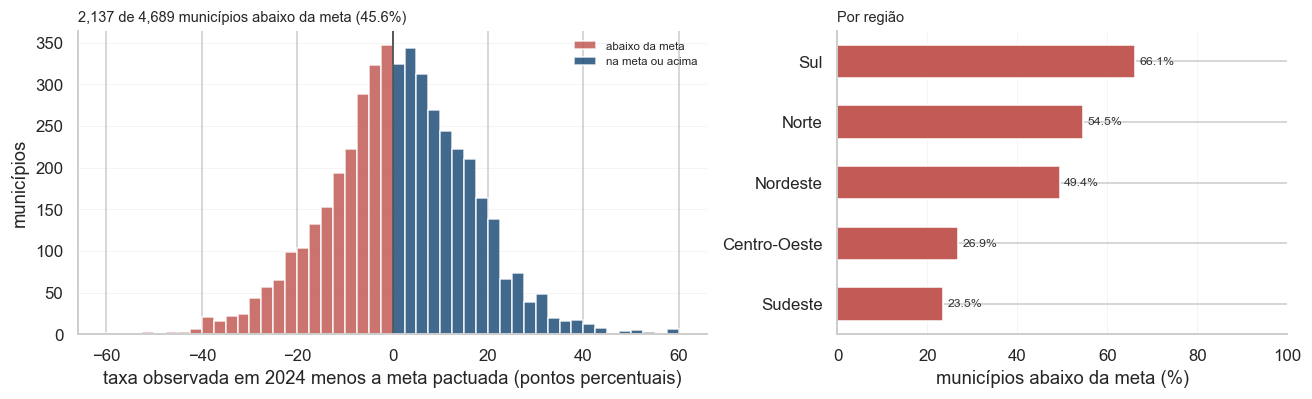

SITUAÇÃO DIANTE DA META PACTUADA PARA 2024
  municípios com meta pactuada                 4,689 de 5,517
  abaixo da meta                               2,137  (45.6%)
  distância mediana dos que ficaram abaixo       8.6 pp
  alunos nesses municípios                   716,393  (38.7% da base)

A região Sul, decomposta por estado:
          municipios  pct_abaixo
sigla_uf                        
PR               395        52.4
SC               238        43.7
RS               421        91.7
  Sul sem o Rio Grande do Sul: 49.1% abaixo da meta


,municipios,pct_abaixo
sigla_uf,,
RS,421,91.7
BA,394,81.0
PA,136,64.0
AM,48,60.4
AP,16,56.2
RJ,90,55.6
PR,395,52.4
RN,139,50.4
RO,52,50.0


In [300]:
# --- 4.1 Municípios diante da meta pactuada para 2024 ---
metas = (base.groupby("id_municipio")
         .agg(meta=("mun_meta_ciclo", "first"),
              taxa_2023=("mun_taxa_ant", "first"))
         .join(por_municipio))
com_meta = metas.dropna(subset=["meta"]).copy()
com_meta["distancia"] = com_meta["taxa"] - com_meta["meta"]
com_meta["abaixo"] = com_meta["distancia"] < 0
alunos_abaixo = base["id_municipio"].isin(com_meta.index[com_meta["abaixo"]])

abaixo_por_regiao = (100 * com_meta.groupby("nome_regiao")["abaixo"].mean()
                     ).round(1).sort_values()
abaixo_por_uf = (com_meta.groupby("sigla_uf")
                 .agg(municipios=("abaixo", "size"), pct_abaixo=("abaixo", "mean"))
                 .assign(pct_abaixo=lambda d: (100 * d["pct_abaixo"]).round(1))
                 .sort_values("pct_abaixo", ascending=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.7),
                               gridspec_kw={"width_ratios": [1.4, 1]})
faixas = np.arange(-60, 61, 2.5)
distancia = com_meta["distancia"].clip(-60, 60)
ax1.hist(distancia[distancia < 0], bins=faixas, color="#c25b56", alpha=.85,
         label="abaixo da meta")
ax1.hist(distancia[distancia >= 0], bins=faixas, color="#1f4e79", alpha=.85,
         label="na meta ou acima")
ax1.axvline(0, color="#333", lw=1)
ax1.set_xlabel("taxa observada em 2024 menos a meta pactuada (pontos percentuais)")
ax1.set_ylabel("municípios")
ax1.set_title(f"{com_meta['abaixo'].sum():,} de {len(com_meta):,} municípios "
              f"abaixo da meta ({com_meta['abaixo'].mean():.1%})",
              fontsize=9.5, loc="left")
ax1.legend(fontsize=7.5, frameon=False)
ax1.grid(axis="y", alpha=.22, lw=.6)

ax2.barh(abaixo_por_regiao.index, abaixo_por_regiao.values,
         color="#c25b56", height=.55)
for i, v in enumerate(abaixo_por_regiao.values):
    ax2.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=8, color="#333")
ax2.set_xlim(0, 100)
ax2.set_xlabel("municípios abaixo da meta (%)")
ax2.set_title("Por região", fontsize=9.5, loc="left")
ax2.grid(axis="x", alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

print("SITUAÇÃO DIANTE DA META PACTUADA PARA 2024")
print("=" * 70)
print(f"  municípios com meta pactuada               "
      f"{len(com_meta):>7,} de {len(metas):,}")
print(f"  abaixo da meta                             "
      f"{com_meta['abaixo'].sum():>7,}  ({com_meta['abaixo'].mean():.1%})")
print(f"  distância mediana dos que ficaram abaixo   "
      f"{-com_meta.loc[com_meta['abaixo'], 'distancia'].median():>7.1f} pp")
print(f"  alunos nesses municípios                   "
      f"{alunos_abaixo.sum():>7,}  ({alunos_abaixo.mean():.1%} da base)")
print()
print("A região Sul, decomposta por estado:")
print(abaixo_por_uf.loc[[u for u in ["PR", "SC", "RS"]
                         if u in abaixo_por_uf.index]].to_string())
sul_sem_rs = com_meta[com_meta["sigla_uf"].isin(["PR", "SC"])]
print(f"  Sul sem o Rio Grande do Sul: "
      f"{100 * sul_sem_rs['abaixo'].mean():.1f}% abaixo da meta")

abaixo_por_uf

**Leitura.** Dos 4.689 municípios com meta pactuada, 2.137 (45,6%) ficaram abaixo dela em 2024, a uma distância mediana de 8,6 pontos percentuais. Eles concentram 38,7% dos alunos.

A distribuição regional tem uma anomalia: o Sul, que tem a terceira maior taxa, aparece com a maior fração de municípios abaixo da meta (66,1%). A decomposição mostra que o resultado vem de um único estado. No Rio Grande do Sul, 91,7% dos municípios ficaram abaixo da meta, contra 49,1% no restante da região. Sem o estado gaúcho, o Sul se alinha às demais regiões.

Estar bem posicionado e estar no caminho da meta são informações distintas. Goiás, Minas Gerais, Espírito Santo e Ceará têm menos de um quarto dos municípios abaixo da meta, mas o Paraná, com mediana municipal de 75,0%, tem mais da metade. Para a política pública, o que interessa prever é a segunda informação, e não a primeira.

### 4.2 Persistência do resultado entre 2023 e 2024

O gráfico de dispersão coloca cada município na posição da sua taxa em 2023 e em 2024. Se o resultado fosse perfeitamente persistente, os pontos ficariam sobre a diagonal tracejada. Só entram municípios com ao menos 20 alunos avaliados: abaixo disso, a taxa oscila demais de um ano para o outro por puro tamanho de amostra. O painel ao lado resume a mesma informação por estado: cada município é comparado consigo mesmo, e o estado recebe a mediana dessas variações, além da fração de municípios que piorou.

🎓 **Conceito, comparação pareada:** para medir quanto um grupo mudou entre dois momentos, há duas contas possíveis. Subtrair a mediana de um ano da mediana do outro confronta dois retratos, em que os municípios podem ter trocado de posição. Comparar cada município consigo mesmo e tomar a mediana das variações mede a mudança de fato ocorrida, e é a conta correta quando as mesmas unidades são observadas nos dois momentos. A diferença entre as duas chega a quase quatro pontos: na Paraíba, a diferença das medianas indica melhora de 1,8 ponto, e a mediana das variações, de 5,5.

🎓 **Conceito, regressão à média:** quando uma medida tem componente aleatório, os valores extremos de um período tendem a se aproximar da média no período seguinte, sem que nada tenha mudado de fato. Um município com taxa muito baixa num ano pode ter tido, além de dificuldades reais, um ano ruim; no ano seguinte, a parte aleatória se desfaz e a taxa sobe. O fenômeno importa para a política pública, porque uma melhora observada nos piores municípios pode ser atribuída por engano a uma intervenção. E importa para o modelo, porque o desempenho anterior prevê bem a direção do resultado, mas superestima a distância entre os extremos.

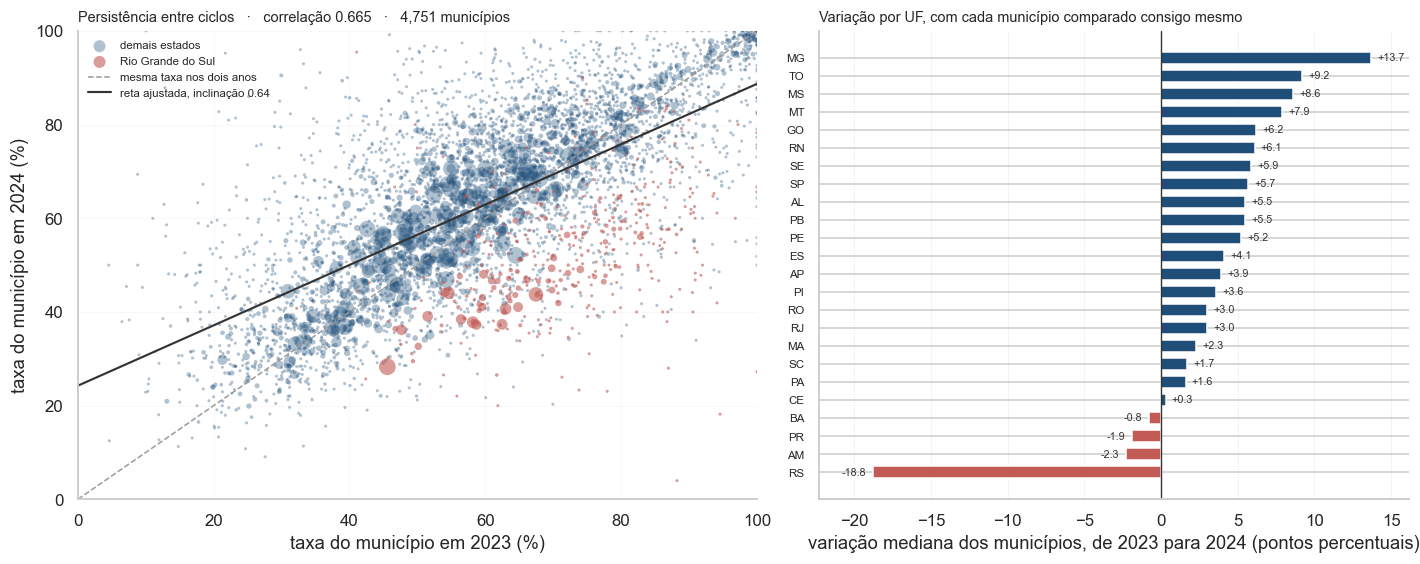

Correlação entre as taxas de 2023 e 2024: 0.665
Reta ajustada: taxa_2024 = 24.3 + 0.64 x taxa_2023
Variação mediana: +2.6 pp   municípios que melhoraram: 58.6%

VARIAÇÃO POR QUARTIL DA TAXA DE 2023, COM TODOS OS MUNICÍPIOS
               taxa_2023  taxa_2024  variacao
quartil                                      
Q1 mais baixo       35.1       42.4       8.2
Q2                  54.0       60.5       6.3
Q3                  68.0       70.3       2.7
Q4 mais alto        83.6       80.3      -3.4

A MESMA TABELA, SEM O RIO GRANDE DO SUL
               taxa_2023  taxa_2024  variacao
quartil                                      
Q1 mais baixo       34.1       41.1       8.3
Q2                  52.4       60.1       7.4
Q3                  66.5       70.8       4.2
Q4 mais alto        83.0       82.5      -1.4


,municipios,variacao_mediana,pct_que_piorou
sigla_uf,,,
RS,399,-18.8,93.2
AM,62,-2.3,58.1
PR,392,-1.9,62.2
BA,406,-0.8,54.2
CE,184,0.3,42.9
PA,144,1.6,42.4
SC,283,1.7,42.8
MA,216,2.3,46.8
RJ,92,3.0,30.4


In [301]:
# --- 4.2 Persistência do resultado entre 2023 e 2024 ---
MIN_ALUNOS = 20   # abaixo disso, a taxa municipal oscila demais entre anos

evolucao = metas.dropna(subset=["taxa_2023"])
evolucao = evolucao[evolucao["alunos"] >= MIN_ALUNOS].copy()
evolucao["variacao"] = evolucao["taxa"] - evolucao["taxa_2023"]

correlacao = evolucao["taxa_2023"].corr(evolucao["taxa"])
inclinacao, intercepto = np.polyfit(evolucao["taxa_2023"], evolucao["taxa"], 1)

# Comparação pareada: cada município contra si mesmo, e a mediana por UF
variacao_uf = (evolucao.groupby("sigla_uf")
               .agg(municipios=("variacao", "size"),
                    variacao_mediana=("variacao", "median"),
                    pct_que_piorou=("variacao", lambda s: 100 * (s < 0).mean()))
               .round(1).sort_values("variacao_mediana"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2),
                               gridspec_kw={"width_ratios": [1.15, 1]})

rs = evolucao["sigla_uf"] == "RS"
tamanho = np.clip(evolucao["alunos"] / 40, 4, 120)
ax1.scatter(evolucao.loc[~rs, "taxa_2023"], evolucao.loc[~rs, "taxa"],
            s=tamanho[~rs], color="#1f4e79", alpha=.35, edgecolor="none",
            label="demais estados")
ax1.scatter(evolucao.loc[rs, "taxa_2023"], evolucao.loc[rs, "taxa"],
            s=tamanho[rs], color="#c25b56", alpha=.6, edgecolor="none",
            label="Rio Grande do Sul")
x = np.array([0, 100])
ax1.plot(x, x, color="#9a9a9a", ls="--", lw=1, label="mesma taxa nos dois anos")
ax1.plot(x, intercepto + inclinacao * x, color="#333", lw=1.4,
         label=f"reta ajustada, inclinação {inclinacao:.2f}")
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)
ax1.set_xlabel("taxa do município em 2023 (%)")
ax1.set_ylabel("taxa do município em 2024 (%)")
ax1.set_title(f"Persistência entre ciclos   ·   correlação {correlacao:.3f}   ·   "
              f"{len(evolucao):,} municípios", fontsize=9.5, loc="left")
ax1.legend(fontsize=7.5, frameon=False, loc="upper left")
ax1.grid(alpha=.18, lw=.5)

cores = ["#c25b56" if v < 0 else "#1f4e79" for v in variacao_uf["variacao_mediana"]]
ax2.barh(variacao_uf.index, variacao_uf["variacao_mediana"], color=cores, height=.65)
ax2.axvline(0, color="#333", lw=.9)
ax2.set_xlim(variacao_uf["variacao_mediana"].min() - 3.5,
             variacao_uf["variacao_mediana"].max() + 2.5)
for i, v in enumerate(variacao_uf["variacao_mediana"]):
    ax2.text(v + (.4 if v >= 0 else -.4), i, f"{v:+.1f}", va="center",
             ha="left" if v >= 0 else "right", fontsize=7, color="#333")
ax2.set_xlabel("variação mediana dos municípios, de 2023 para 2024 (pontos percentuais)")
ax2.set_title("Variação por UF, com cada município comparado consigo mesmo",
              fontsize=9.5, loc="left")
ax2.tick_params(axis="y", labelsize=7.5)
ax2.grid(axis="x", alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

ROTULOS_QUARTIL = ["Q1 mais baixo", "Q2", "Q3", "Q4 mais alto"]


def variacao_por_quartil(df: pd.DataFrame) -> pd.DataFrame:
    """Mediana da taxa e da variação em cada quartil da taxa de 2023."""
    return (df.assign(quartil=pd.qcut(df["taxa_2023"], 4, labels=ROTULOS_QUARTIL))
              .groupby("quartil", observed=True)
              .agg(taxa_2023=("taxa_2023", "median"),
                   taxa_2024=("taxa", "median"),
                   variacao=("variacao", "median"))
              .round(1))


print(f"Correlação entre as taxas de 2023 e 2024: {correlacao:.3f}")
print(f"Reta ajustada: taxa_2024 = {intercepto:.1f} + {inclinacao:.2f} x taxa_2023")
print(f"Variação mediana: {evolucao['variacao'].median():+.1f} pp   "
      f"municípios que melhoraram: {(evolucao['variacao'] > 0).mean():.1%}")
print()
print("VARIAÇÃO POR QUARTIL DA TAXA DE 2023, COM TODOS OS MUNICÍPIOS")
print(variacao_por_quartil(evolucao).to_string())
print()
print("A MESMA TABELA, SEM O RIO GRANDE DO SUL")
print(variacao_por_quartil(evolucao[~rs]).to_string())

variacao_uf

**Leitura.** A correlação entre as taxas municipais de 2023 e 2024 é de 0,665: o resultado de um ciclo antecipa bem o do seguinte, o que explica o domínio da H8 na seção 8. A reta ajustada tem inclinação de 0,64, e não de 1, e a tabela por quartis mostra a regressão à média: os municípios do quartil mais baixo em 2023 ganharam, na mediana, 8,2 pontos percentuais; os do quartil mais alto perderam 3,4. Mais da metade dessa perda vem do Rio Grande do Sul, cujos municípios estavam no alto da distribuição em 2023: sem o estado, a perda do quartil mais alto cai para 1,4 ponto, enquanto o ganho do quartil mais baixo se mantém em 8,3.

O painel por estado isola o caso gaúcho. No Rio Grande do Sul, a variação mediana dos municípios entre 2023 e 2024 foi de −18,8 pontos percentuais, e 93,2% deles pioraram. Nenhum outro estado teve variação mediana abaixo de −2,3, a do Amazonas. A queda coincide com as enchentes de abril e maio de 2024, o mesmo ano da avaliação. A hipótese plausível é que o desastre tenha comprometido o ano letivo: escolas danificadas ou ocupadas como abrigo, aulas suspensas por semanas e calendário refeito, justamente no ano em que as crianças avaliadas deveriam consolidar a alfabetização. A hipótese não é testada aqui, porque as fontes usadas não trazem uma medida de quanto cada município foi atingido, o que permitiria comparar os mais e os menos afetados. O padrão observado, porém, é o de um choque pontual e disseminado pelo estado, e não o de uma característica estrutural do território.

⚠️ **Consequência para a modelagem.** Nos municípios gaúchos, o desempenho de 2023 é um mau preditor do de 2024, e o modelo vai aprender, para esse estado, a partir de um ano atípico. A decisão sobre como tratar o caso (manter, sinalizar com um indicador ou avaliar o estado à parte) fica registrada na seção 12, e ele entra nas limitações do trabalho.

---

## 5. Análise univariada: variáveis numéricas

**Passos desta seção:** (5.1) estatísticas descritivas das variáveis numéricas; (5.2) forma das distribuições, agrupadas por hipótese.

Cada variável é examinada isoladamente, sem relação com a resposta. O que se busca aqui é a forma de cada distribuição: onde está a massa, qual a dispersão, se há concentração em um valor e se a cauda é longa. Essas características determinam a transformação necessária no pré-processamento e antecipam quais variáveis exigem cuidado na modelagem.

### 5.1 Estatísticas descritivas

🎓 **Conceito, medidas de posição e dispersão:** média e mediana descrevem o centro; quando divergem, a distribuição é assimétrica, e a mediana representa melhor o caso típico. Desvio padrão e amplitude interquartil descrevem a dispersão; o desvio é sensível a valores extremos, a amplitude interquartil não. Comparar os dois pares revela a forma da distribuição antes de qualquer gráfico.

A razão entre desvio padrão e média, chamada **coeficiente de variação**, permite comparar a dispersão de variáveis em escalas diferentes, o que é necessário aqui, onde convivem percentuais de 0 a 100, valores monetários na casa dos milhares e índices entre 0 e 1.

In [302]:
# --- 5.1 Estatísticas descritivas das variáveis numéricas ---
mapa_hipotese = dict(zip(dicionario["variavel"], dicionario["hipotese"]))

linhas = []
for col in NUMERICAS:
    v = pd.to_numeric(base[col], errors="coerce").dropna()
    if len(v) == 0:
        continue
    media = float(v.mean())
    q25, q75 = float(v.quantile(.25)), float(v.quantile(.75))
    linhas.append({
        "variavel": col,
        "hipotese": mapa_hipotese.get(col, "não declarada"),
        "n": int(len(v)),
        "media": round(media, 2),
        "mediana": round(float(v.median()), 2),
        "desvio": round(float(v.std()), 2),
        "amplitude_iq": round(q75 - q25, 2),
        # o coeficiente de variação compara dispersões em escalas diferentes;
        # só tem sentido sem valores negativos: nas variáveis de diferença,
        # a média perto de zero infla a razão
        "coef_variacao": (round(float(v.std()) / media, 2)
                          if v.min() >= 0 and media > 0 else np.nan),
        "media_menos_mediana": round(media - float(v.median()), 2),
        "minimo": round(float(v.min()), 2),
        "p01": round(float(v.quantile(.01)), 2),
        "p99": round(float(v.quantile(.99)), 2),
        "maximo": round(float(v.max()), 2),
    })

descritiva = pd.DataFrame(linhas).set_index("variavel")

print(f"{len(descritiva)} variáveis numéricas descritas")
print()
print("MAIOR DISPERSÃO RELATIVA (coeficiente de variação)")
print("=" * 78)
print(descritiva.nlargest(8, "coef_variacao")[
    ["hipotese", "media", "mediana", "desvio", "coef_variacao"]].to_string())
print()
print("Leitura: coeficiente de variação acima de 1 indica desvio padrão maior")
print("que a média, típico de distribuições com cauda longa à direita. Nessas")
print("variáveis, média e mediana divergem e a média deixa de representar o")
print("caso típico.")

# O DataFrame fica disponível para inspeção e ordenação no próprio notebook.
# Exemplos: descritiva.sort_values("coef_variacao", ascending=False)
#           descritiva.query("hipotese.str.startswith('H2')")
descritiva

62 variáveis numéricas descritas

MAIOR DISPERSÃO RELATIVA (coeficiente de variação)
                                                      hipotese       media   mediana      desvio  coef_variacao
variavel                                                                                                       
esc_pct_area_diferenciada  H13 contexto linguistico e cultural        4.20       0.0       10.87           2.59
esc_pct_assistente_social             H5 suporte especializado        7.64       0.0       19.24           2.52
mun_populacao                               controle de escala  1133740.87  117995.0  2854529.82           2.52
mun_porte_atual                             controle de escala     9818.99    1305.0    24384.35           2.48
mun_alunos_ant                              controle de escala     3999.27     889.0     8554.21           2.14
rede_porte_atual                            controle de escala     6608.97    1111.0    14035.49           2.12
esc_pct_psicologo  

,hipotese,n,media,mediana,desvio,amplitude_iq,coef_variacao,media_menos_mediana,minimo,p01,p99,maximo
variavel,,,,,,,,,,,,
rede_taxa_ant,H8 inercia territorial,1816270,56.63,56.19,15.55,19.26,0.27,0.44,3.41,22.55,97.88,100.00
rede_media_portugues_ant,H8 inercia territorial,1816270,745.60,743.27,20.12,20.21,0.03,2.33,673.30,707.44,819.84,868.46
uf_rede_taxa_ant,H8 inercia territorial,1816270,60.53,59.21,13.33,10.19,0.22,1.32,27.53,36.02,93.16,93.16
rede_vs_uf,H8 inercia territorial,1816270,-3.89,-4.47,11.59,14.26,NaN,0.58,-66.43,-27.86,31.08,58.21
rede_vs_municipio,H8 inercia territorial,1651052,0.01,0.00,3.56,0.06,NaN,0.01,-65.06,-9.50,12.38,64.39
mun_taxa_ant,H8 inercia territorial,1652243,56.70,56.01,15.60,21.60,0.28,0.69,4.56,22.55,97.90,100.00
mun_participacao_ant,H8 inercia territorial,1423733,86.60,86.78,7.00,9.26,0.08,-0.19,27.49,69.72,100.00,100.00
mun_taxa_ajustada_ant,H8 inercia territorial,1423733,50.49,49.28,16.19,20.56,0.32,1.21,4.08,19.08,95.23,100.00
mun_alunos_ant,controle de escala,1423733,3999.27,889.00,8554.21,2890.00,2.14,3110.27,9.00,34.00,44858.00,44858.00


**Leitura.** As estatísticas desta seção contam alunos, e não municípios: cada município pesa pelo número de alunos que tem. Por isso o caso típico descrito aqui é o de um aluno de cidade grande e urbana. Contando cada combinação de município e rede uma vez, o quadro muda: a mediana da população vai de 118 mil para 13 mil habitantes, a de alunos do 2º ano em escola rural, de 4,8% para 13,1%, e a da população com esgoto adequado, de 68,6% para 34,3%. É o mesmo efeito do peso das cidades grandes visto na seção 3.1.

As variáveis de maior dispersão relativa são as de porte (população, alunos e escolas) e as de presença rara, como escola em área diferenciada, psicólogo e assistente social: nelas, a maior parte das redes tem valor zero e poucas têm valores altos.

📌 **Duas notas técnicas.** O coeficiente de variação é calculado só para variáveis sem valores negativos; nas variáveis de diferença, como `rede_vs_municipio`, a média fica perto de zero e a razão perde sentido. E um município de Goiás (código 5204250, 97 alunos) tem valor adicionado total negativo no PIB de 2021, por causa de um valor negativo na indústria, e por isso aparece com −41,9% de agropecuária e −42,0% de serviços. O dado é da fonte, mas o percentual não tem interpretação, e a correção fica registrada para a base analítica.

### 5.2 Forma das distribuições

Os histogramas abaixo estão agrupados pela hipótese que cada variável responde, o que permite comparar variáveis que medem facetas de um mesmo conceito.

🎓 **Conceito, o que observar em um histograma nesta etapa:** três padrões orientam decisões posteriores. **Concentração em um extremo**, comum em variáveis de cobertura onde a maioria das redes está próxima de 100%, reduz o poder discriminante da variável, porque poucas observações ocupam a faixa em que há variação. **Cauda longa** indica necessidade de transformação para modelos lineares. **Multimodalidade**, isto é, mais de um pico, sugere que a variável mistura populações distintas, e que uma variável de segmentação pode estar faltando.

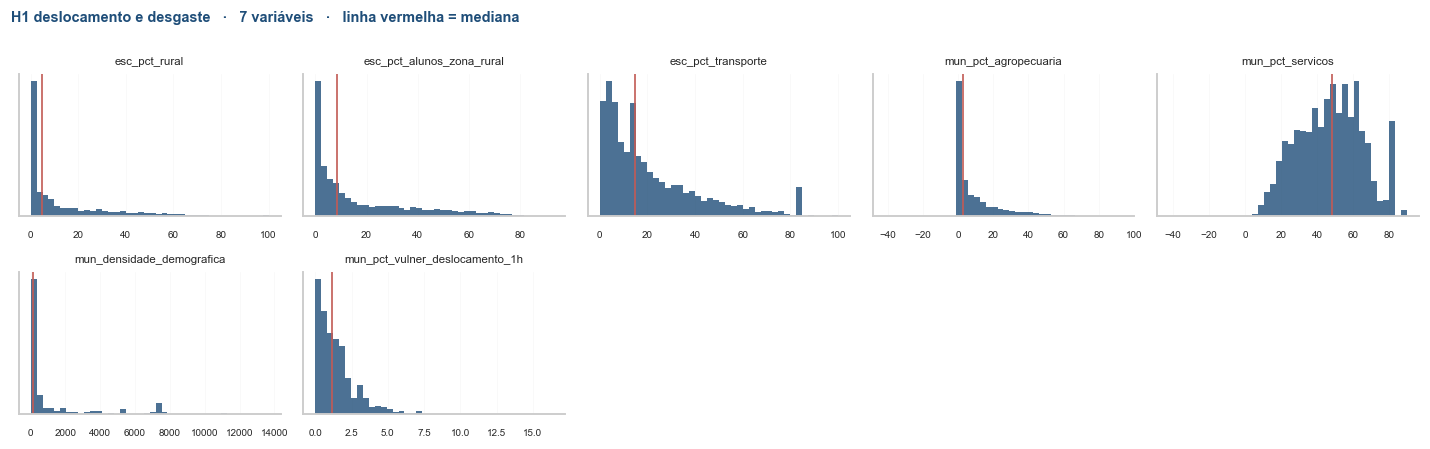

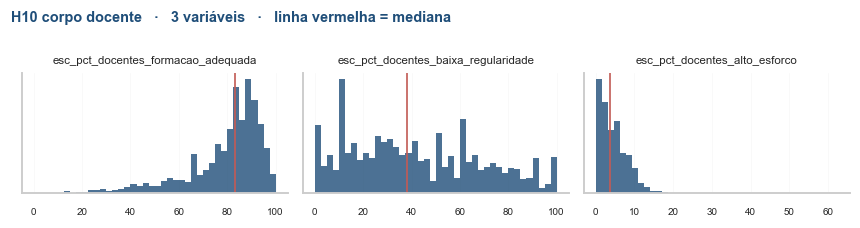

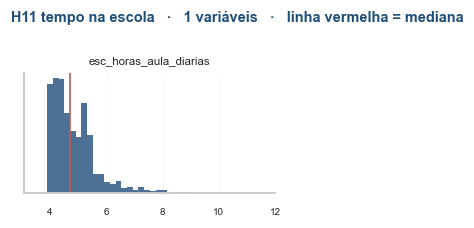

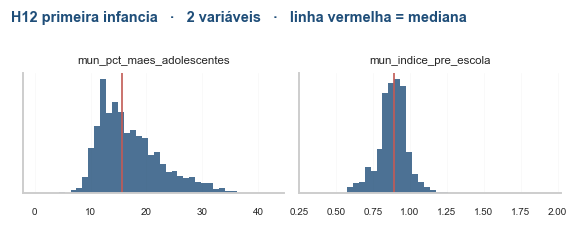

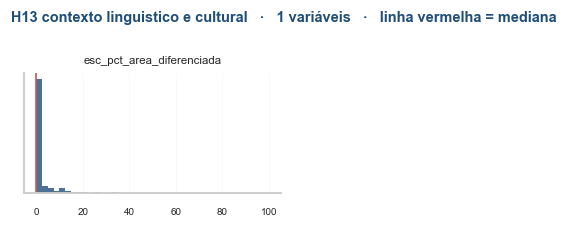

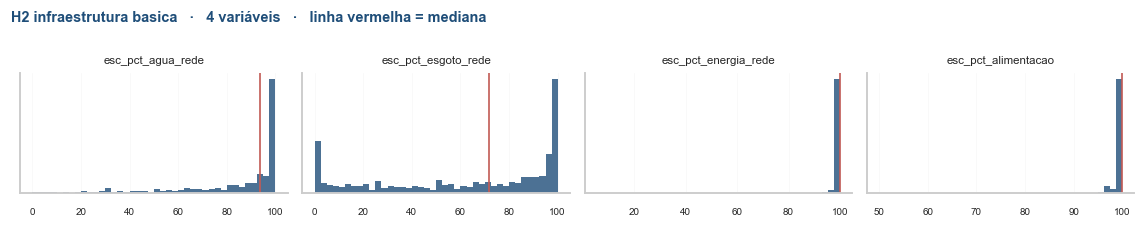

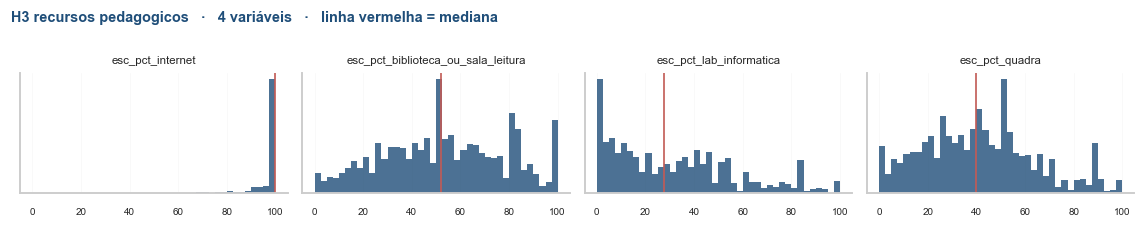

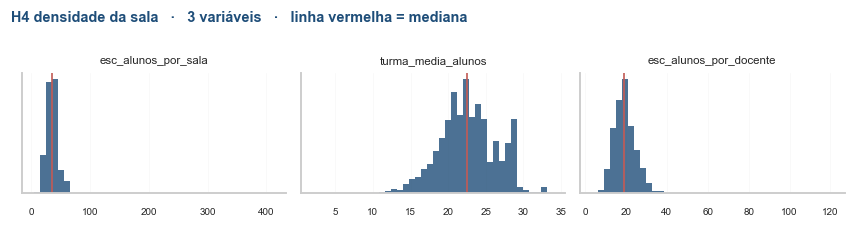

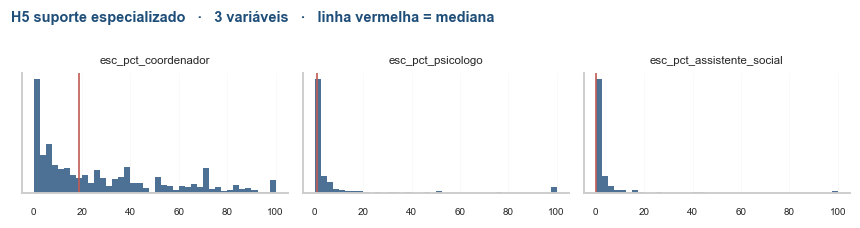

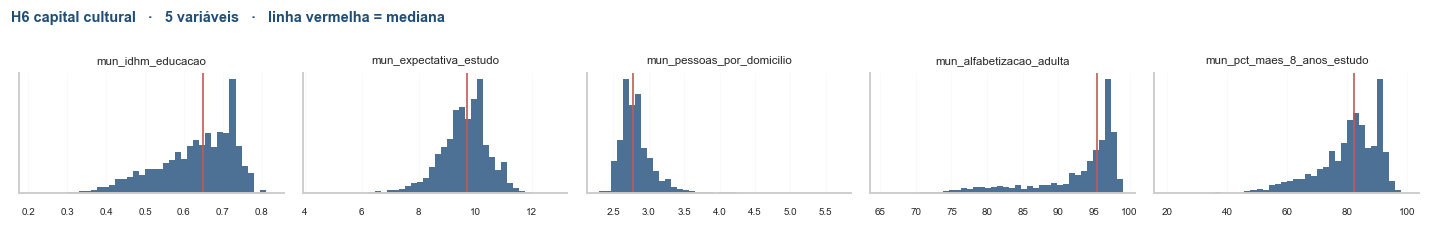

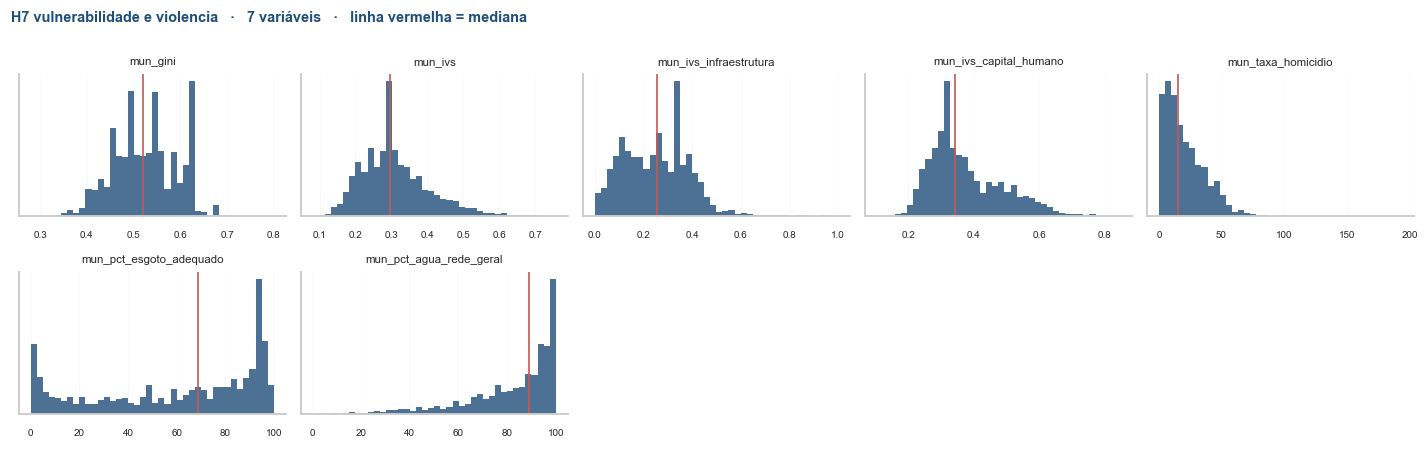

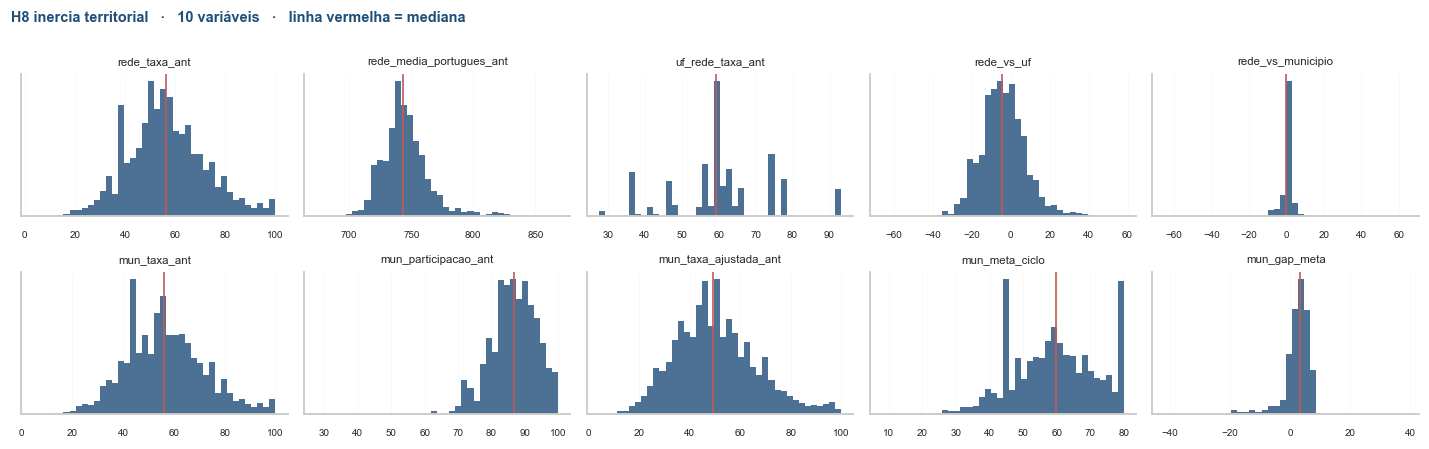

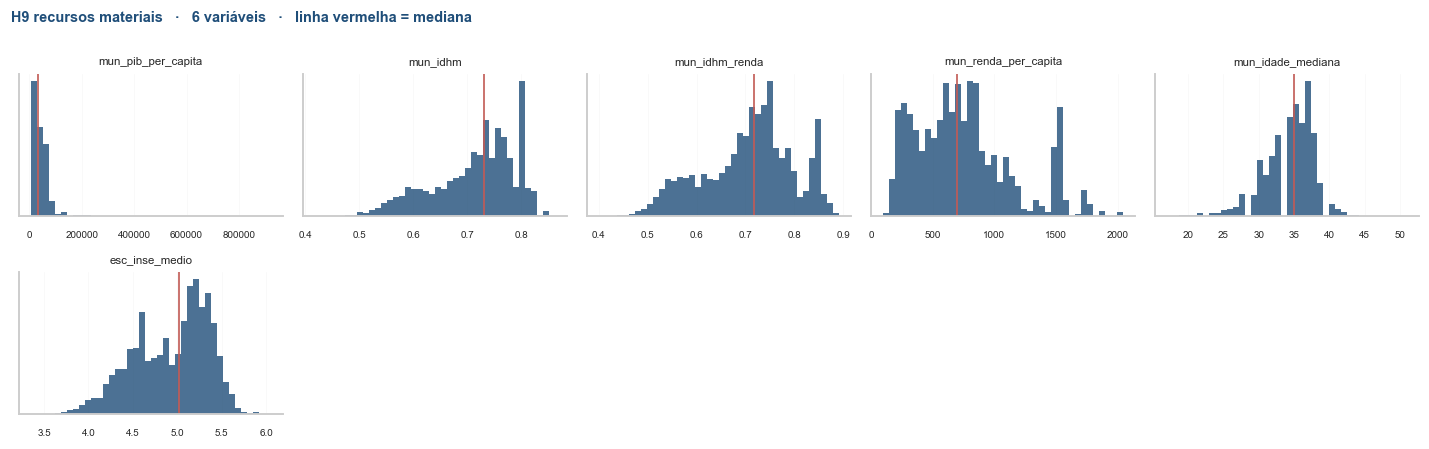

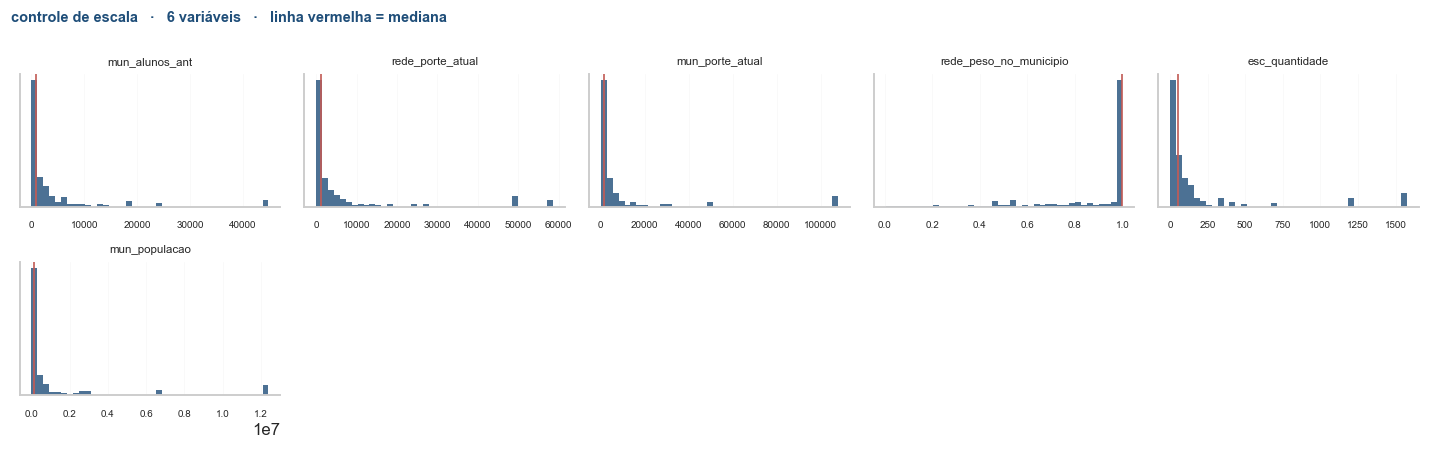

In [303]:
# --- 5.2 Histogramas agrupados por hipótese ---
hipotese_da_variavel = (dicionario.set_index("variavel")["hipotese"]
                        .reindex(NUMERICAS).fillna("sem hipótese"))

for bloco in sorted(hipotese_da_variavel.unique()):
    variaveis = [v for v in NUMERICAS if hipotese_da_variavel[v] == bloco]
    if not variaveis:
        continue

    n_col = min(5, len(variaveis))
    n_lin = int(np.ceil(len(variaveis) / n_col))
    fig, eixos = plt.subplots(n_lin, n_col,
                              figsize=(2.6 * n_col, 2.0 * n_lin))
    eixos = np.atleast_1d(eixos).ravel()

    for eixo, v in zip(eixos, variaveis):
        d = base[v].dropna()
        eixo.hist(d, bins=40, color="#1f4e79", alpha=.80, edgecolor="none")
        eixo.axvline(d.median(), color="#c25b56", lw=1.1)
        eixo.set_title(v, fontsize=7.5)
        eixo.set_yticks([])
        eixo.tick_params(axis="x", labelsize=6.5)
        eixo.grid(axis="x", alpha=.15, lw=.5)

    for eixo in eixos[len(variaveis):]:
        eixo.axis("off")

    fig.suptitle(f"{bloco}   ·   {len(variaveis)} variáveis   ·   "
                 "linha vermelha = mediana",
                 fontsize=9.5, y=1.005, x=.005, ha="left",
                 fontweight="bold", color="#1f4e79")
    plt.tight_layout()
    plt.show()

In [304]:
# --- 5.2b Concentração: quanto da massa está no extremo da escala ---
# Variável de cobertura concentrada perto do máximo discrimina pouco:
# a maior parte das observações fica numa faixa estreita.
def medir_concentracao(df: pd.DataFrame, colunas: list) -> pd.DataFrame:
    linhas = []
    for col in colunas:
        v = df[col].dropna()
        if len(v) < 100 or v.nunique() < 3:
            continue
        faixa = v.max() - v.min()
        if faixa <= 0:
            continue
        # fração das observações nos 10% superiores e inferiores da escala
        linhas.append({
            "variavel": col,
            "no_topo_da_escala_pct": round(
                100 * float((v >= v.min() + .9 * faixa).mean()), 1),
            "na_base_da_escala_pct": round(
                100 * float((v <= v.min() + .1 * faixa).mean()), 1),
            "valores_distintos": int(v.nunique()),
        })
    return pd.DataFrame(linhas)


concentracao = medir_concentracao(base, NUMERICAS).merge(
    dicionario[["variavel", "hipotese"]], on="variavel", how="left")

print("VARIÁVEIS CONCENTRADAS NO TOPO DA ESCALA (mais de 60% das observações)")
print("=" * 78)
topo = concentracao[concentracao["no_topo_da_escala_pct"] > 60].sort_values(
    "no_topo_da_escala_pct", ascending=False)
if len(topo):
    print(topo[["variavel", "hipotese", "no_topo_da_escala_pct",
                "valores_distintos"]].to_string(index=False))
else:
    print("Nenhuma.")
print()
print("VARIÁVEIS CONCENTRADAS NA BASE DA ESCALA (mais de 60% das observações)")
print("=" * 78)
na_base_da_escala = concentracao[concentracao["na_base_da_escala_pct"] > 60].sort_values(
    "na_base_da_escala_pct", ascending=False)
if len(na_base_da_escala):
    print(na_base_da_escala[["variavel", "hipotese", "na_base_da_escala_pct",
                             "valores_distintos"]].to_string(index=False))
else:
    print("Nenhuma.")
print()
print("Leitura: concentração alta em um extremo significa que a variável")
print("separa pouco as observações, porque quase todas assumem valores")
print("próximos. Isso não a invalida, porque pode ser que a minoria")
print("fora da concentração seja a de interesse, mas antecipa baixa")
print("importância no modelo e será confrontado na análise bivariada.")

VARIÁVEIS CONCENTRADAS NO TOPO DA ESCALA (mais de 60% das observações)
              variavel                 hipotese  no_topo_da_escala_pct  valores_distintos
   esc_pct_alimentacao H2 infraestrutura basica                   97.7                 81
  esc_pct_energia_rede H2 infraestrutura basica                   97.0                196
      esc_pct_internet  H3 recursos pedagogicos                   86.3                420
rede_peso_no_municipio       controle de escala                   70.2               1809

VARIÁVEIS CONCENTRADAS NA BASE DA ESCALA (mais de 60% das observações)
                      variavel                            hipotese  na_base_da_escala_pct  valores_distintos
            mun_pib_per_capita               H9 recursos materiais                   95.9               5186
           esc_alunos_por_sala                H4 densidade da sala                   87.9               5878
     esc_pct_area_diferenciada H13 contexto linguistico e cultural              

**Leitura.** Três formas se repetem nos histogramas:

1. **Concentradas perto de 100%:** alimentação escolar, energia elétrica e internet. Quase todas as redes já têm esses itens, e por isso as variáveis separam pouco os alunos.
2. **Concentradas perto de zero, com cauda longa:** as de porte (população, alunos, escolas e densidade demográfica) e as de presença rara (psicólogo, assistente social e escola em área diferenciada). Nas de porte, poucas cidades grandes esticam a escala.
3. **Sem concentração em um extremo:** taxa anterior, INSE, IDHM, formação docente, tamanho da turma e a maior parte das variáveis de contexto.

Duas variáveis aparecem concentradas na base por causa de um único extremo. `esc_alunos_por_sala` tem mediana de 34,7, mas uma rede estadual do Rio Grande do Sul, com uma escola e 29 alunos, registra 413 alunos por sala e estica a escala. `mun_pib_per_capita` é esticado por poucos municípios de produção industrial ou extrativa, com até 920 mil reais por habitante. Os extremos são examinados na seção 7.

📌 **Consequência para a modelagem.** As variáveis quase constantes, como alimentação e energia, devem ter importância baixa no modelo. Elas não são descartadas aqui: a decisão depende da relação com a resposta (seção 8). A transformação das variáveis de cauda longa é decidida na seção 12.

---

## 6. Análise univariada: variáveis categóricas

**Passos desta seção:** (6.1) frequência e cardinalidade de cada categórica; (6.2) distribuição das categorias; (6.3) identificação de categorias raras.

As variáveis categóricas exigem tratamento próprio no pré-processamento. Diferente das numéricas, elas não têm ordem nem escala, e precisam ser convertidas em representação numérica antes de entrar no modelo. Duas características determinam a escolha dessa conversão: a **cardinalidade**, isto é, quantas categorias distintas existem, e a **frequência de cada categoria**, que indica se há classes com poucas observações.

### 6.1 Cardinalidade e frequência

🎓 **Conceito, cardinalidade e a escolha da codificação:** a codificação `one-hot` cria uma coluna binária por categoria. Com poucas categorias o custo é baixo; com muitas, o número de colunas cresce e cada uma passa a conter poucas observações positivas, o que fragiliza a estimativa. A alternativa usual para cardinalidade alta é a codificação por alvo, que substitui a categoria pela taxa média de resposta observada nela. Essa técnica, se aplicada sem cuidado, **introduz vazamento**, porque usa a variável resposta para construir a explicativa.

O limiar prático costuma ser em torno de dez a quinze categorias. A célula abaixo mede a cardinalidade de cada variável para orientar essa decisão, que é registrada na seção 12.

In [305]:
# --- 6.1 Cardinalidade e frequência das variáveis categóricas ---
resumo_categoricas = []
for col in CATEGORICAS:
    vc = base[col].value_counts(dropna=False)
    resumo_categoricas.append({
        "variavel": col,
        "hipotese": mapa_hipotese.get(col, "não declarada"),
        "categorias": int(base[col].nunique(dropna=True)),
        "preenchido_pct": round(100 * base[col].notna().mean(), 1),
        "categoria_mais_comum": str(vc.index[0]),
        "frequencia_da_maior_pct": round(100 * vc.iloc[0] / len(base), 1),
        "menor_categoria_n": int(vc.min()),
        "categorias_abaixo_de_1pct": int((vc / len(base) < .01).sum()),
    })

resumo_categoricas = pd.DataFrame(resumo_categoricas).set_index("variavel")

print(f"{len(CATEGORICAS)} variáveis categóricas")
print("=" * 78)
print(resumo_categoricas.to_string())
print()
print("Leitura: cardinalidade baixa (até cerca de quinze categorias) permite")
print("codificação one-hot sem inflar o número de colunas. Cardinalidade alta")
print("exige alternativa, e a codificação por alvo precisa ser aplicada dentro")
print("da validação cruzada para não vazar a variável resposta.")

resumo_categoricas

3 variáveis categóricas
                         hipotese  categorias  preenchido_pct categoria_mais_comum  frequencia_da_maior_pct  menor_categoria_n  categorias_abaixo_de_1pct
variavel                                                                                                                                                 
rede_nome       controle do aluno           3           100.0            Municipal                     87.0                 24                          1
sigla_uf     controle territorial          26           100.0                   SP                     21.4              10234                          4
nome_regiao  controle territorial           5           100.0              Sudeste                     40.2             175205                          0

Leitura: cardinalidade baixa (até cerca de quinze categorias) permite
codificação one-hot sem inflar o número de colunas. Cardinalidade alta
exige alternativa, e a codificação por alvo precisa ser aplicada

,hipotese,categorias,preenchido_pct,categoria_mais_comum,frequencia_da_maior_pct,menor_categoria_n,categorias_abaixo_de_1pct
variavel,,,,,,,
rede_nome,controle do aluno,3,100.0,Municipal,87.0,24,1
sigla_uf,controle territorial,26,100.0,SP,21.4,10234,4
nome_regiao,controle territorial,5,100.0,Sudeste,40.2,175205,0


### 6.2 Distribuição das categorias

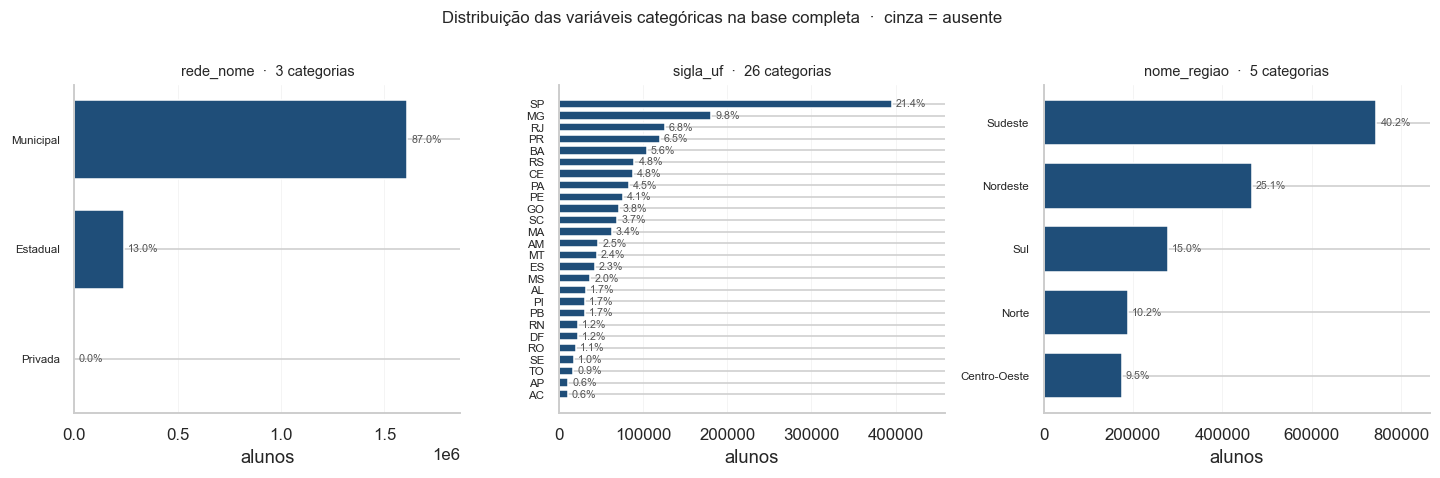

In [306]:
# --- 6.2 Distribuição das categorias ---
SEM_INFO = "(sem informação)"

fig, eixos = plt.subplots(1, len(CATEGORICAS),
                          figsize=(4.4 * len(CATEGORICAS), 4.2))
eixos = np.atleast_1d(eixos)

for eixo, col in zip(eixos, CATEGORICAS):
    vc = base[col].value_counts(dropna=False).sort_values()
    # o rótulo ausente precisa virar texto: o eixo categórico não aceita NaN
    rotulos = [SEM_INFO if pd.isna(v) else str(v) for v in vc.index]
    if len(vc) > 30:
        rotulos, vc = rotulos[-30:], vc.tail(30)

    cores = ["#b0b0b0" if r == SEM_INFO else "#1f4e79" for r in rotulos]
    eixo.barh(rotulos, vc.values, color=cores, height=.72)
    for i, valor in enumerate(vc.values):
        eixo.text(valor + max(vc) * .012, i, f"{100*valor/len(base):.1f}%",
                  va="center", fontsize=7, color="#555")
    eixo.set_xlim(0, max(vc) * 1.16)
    eixo.set_xlabel("alunos")
    eixo.set_title(f"{col}  ·  {base[col].nunique()} categorias", fontsize=9.5)
    eixo.tick_params(axis="y", labelsize=7.5)
    eixo.grid(axis="x", alpha=.22, lw=.6)

fig.suptitle("Distribuição das variáveis categóricas na base completa  "
             "·  cinza = ausente", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

for col in CATEGORICAS:
    ausentes = int(base[col].isna().sum())
    if ausentes:
        print(f"{col}: {ausentes:,} alunos sem informação "
              f"({ausentes/len(base):.1%})")

### 6.3 Categorias raras

🎓 **Conceito, categoria rara:** uma categoria com poucas observações produz estimativa instável. O modelo aprende um efeito a partir de um punhado de casos, e esse efeito não se sustenta em dados novos. Duas saídas são usuais: agrupar as categorias raras numa classe residual, ou aceitar a instabilidade e registrá-la como limitação.

O caso conhecido nesta base é a rede privada. A avaliação de alfabetização é aplicada na rede pública, e os poucos registros privados presentes não têm massa estatística nem contexto de rede correspondente no ciclo anterior, conforme registrado na decisão D-003.

In [307]:
# --- 6.3 Categorias com poucas observações ---
LIMIAR_RARO = 1000   # observações abaixo disso não sustentam estimativa estável

print(f"CATEGORIAS COM MENOS DE {LIMIAR_RARO:,} ALUNOS NA BASE")
print("=" * 78)
encontrou = False
for col in CATEGORICAS:
    vc = base[col].value_counts(dropna=False)
    raras = vc[vc < LIMIAR_RARO]
    if not len(raras):
        continue
    encontrou = True
    print(f"\n{col}")
    for categoria, n in raras.sort_values().items():
        taxa_cat = base.loc[base[col] == categoria, "alvo"].mean()
        print(f"    {str(categoria):<26} {n:>7,} alunos  "
              f"({100*n/len(base):>5.2f}%)   "
              f"taxa observada {100*taxa_cat:>5.1f}%")
if not encontrou:
    print("Nenhuma categoria abaixo do limiar.")

print()
print("Leitura: categoria rara produz estimativa instável, porque o efeito é")
print("aprendido a partir de poucas observações. O tratamento, que é")
print("agrupar numa classe residual ou manter e declarar a limitação,")
print("é decidido na")
print("seção 12, junto com a codificação.")

CATEGORIAS COM MENOS DE 1,000 ALUNOS NA BASE

rede_nome
    Privada                         24 alunos  ( 0.00%)   taxa observada  66.7%

Leitura: categoria rara produz estimativa instável, porque o efeito é
aprendido a partir de poucas observações. O tratamento, que é
agrupar numa classe residual ou manter e declarar a limitação,
é decidido na
seção 12, junto com a codificação.


**Leitura.** A base tem três variáveis categóricas, todas sem ausentes e de cardinalidade baixa ou moderada.

- `rede_nome`: 87,0% dos alunos estão na rede municipal, 13,0% na estadual e 24 na privada. A rede privada é a única categoria rara da base e segue a decisão D-003.
- `sigla_uf`: 26 categorias, porque Roraima não está na base. São Paulo reúne 21,4% dos alunos. Acre, Amapá, Tocantins e Sergipe ficam abaixo de 1% cada, mas todos com mais de 10 mil alunos, o que ainda sustenta uma estimativa estável. O Distrito Federal, como registrado na seção 3.3, não está na partição de treino.
- `nome_regiao`: 5 categorias, com o Sudeste reunindo 40,2% dos alunos. A região é uma agregação da UF, e toda a informação dela já está em `sigla_uf`.

📌 **Consequência para a modelagem.** Rede e região cabem em codificação one-hot sem custo. A UF, com 26 categorias, fica acima do limiar prático, mas não chega a exigir codificação por alvo. Essa escolha, a decisão de manter a região junto com a UF ou no lugar dela, o tratamento da rede privada e o da UF não vista no treino ficam para a seção 12.


---

## 7. Qualidade dos dados: valores extremos e ausências

**Passos desta seção:** (7.1) medir assimetria e peso das caudas; (7.2) visualizar a dispersão por bloco; (7.3) examinar os casos extremos; (7.4) diagnosticar os padrões de ausência; (7.5) verificar a viabilidade da imputação hierárquica.

A presença de valores extremos e de assimetria acentuada condiciona duas decisões da etapa seguinte: a transformação aplicada às variáveis numéricas e a escolha do algoritmo. Modelos lineares pressupõem efeito constante ao longo da escala e são sensíveis a caudas longas; modelos baseados em árvores dependem apenas da ordem dos valores e são indiferentes a elas.

### 7.1 Assimetria e peso das caudas

🎓 **Conceito, assimetria e curtose:** a assimetria mede o quanto a distribuição pende para um lado. Valor próximo de zero indica simetria; acima de 1 em módulo, assimetria pronunciada; acima de 2, forte. A curtose mede o peso das caudas em relação a uma distribuição normal: valor alto indica que observações distantes do centro são mais frequentes do que o esperado.

🎓 **Conceito, o critério de Tukey:** uma observação é convencionalmente considerada extrema quando está a mais de 1,5 amplitude interquartil abaixo do primeiro quartil ou acima do terceiro. O critério é uma convenção estatística, não um diagnóstico de erro: em variáveis naturalmente assimétricas, uma fração alta de observações fora desse intervalo é esperada e não indica problema.

In [308]:
# --- 7.1 Assimetria, curtose e fração fora do intervalo de Tukey ---
def diagnosticar_forma(df: pd.DataFrame, colunas: list) -> pd.DataFrame:
    linhas = []
    for col in colunas:
        v = pd.to_numeric(df[col], errors="coerce").dropna()
        if len(v) < 100 or v.nunique() < 3:
            continue
        q1, q3 = float(v.quantile(.25)), float(v.quantile(.75))
        iqr = q3 - q1
        fora = (float(((v < q1 - 1.5*iqr) | (v > q3 + 1.5*iqr)).mean())
                if iqr > 0 else 0.0)
        mediana = float(v.median())
        linhas.append({
            "variavel": col,
            "hipotese": mapa_hipotese.get(col, "não declarada"),
            "assimetria": round(float(v.skew()), 2),
            "curtose": round(float(v.kurtosis()), 2),
            "fora_de_tukey_pct": round(100 * fora, 1),
            "razao_p99_mediana": (round(float(v.quantile(.99)) / mediana, 1)
                                  if mediana > 0 else np.nan),
        })
    return pd.DataFrame(linhas).set_index("variavel")


forma = diagnosticar_forma(base, NUMERICAS)

# Limiar convencional: |assimetria| > 1 pede atenção, > 2 indica assimetria forte
forma["transformacao_sugerida"] = np.where(
    forma["assimetria"].abs() > 2, "logarítmica ou quantílica",
    np.where(forma["assimetria"].abs() > 1, "avaliar", "nenhuma"))

resumo = forma["transformacao_sugerida"].value_counts()
print(f"{len(forma)} variáveis numéricas diagnosticadas")
print()
for rotulo, n in resumo.items():
    print(f"  {rotulo:<26} {n:>3}")
print()
print("ASSIMETRIA MAIS PRONUNCIADA")
print("=" * 96)
print(forma[forma["assimetria"].abs() > 1]
      .sort_values("assimetria", key=abs, ascending=False)
      .head(12).to_string())

# O DataFrame fica disponível para inspeção e filtro no próprio notebook.
# Exemplos: forma.query("transformacao_sugerida != 'nenhuma'")
#           forma.sort_values("fora_de_tukey_pct", ascending=False)
forma

62 variáveis numéricas diagnosticadas

  nenhuma                     30
  avaliar                     16
  logarítmica ou quantílica   16

ASSIMETRIA MAIS PRONUNCIADA
                                                      hipotese  assimetria  curtose  fora_de_tukey_pct  razao_p99_mediana     transformacao_sugerida
variavel                                                                                                                                            
mun_pib_per_capita                       H9 recursos materiais        7.91   103.32                3.9                6.3  logarítmica ou quantílica
esc_pct_energia_rede                  H2 infraestrutura basica       -7.79    67.15                0.0                1.0  logarítmica ou quantílica
esc_pct_alimentacao                   H2 infraestrutura basica       -6.36    67.28                0.0                1.0  logarítmica ou quantílica
esc_pct_area_diferenciada  H13 contexto linguistico e cultural        3.99    19.24     

,hipotese,assimetria,curtose,fora_de_tukey_pct,razao_p99_mediana,transformacao_sugerida
variavel,,,,,,
rede_taxa_ant,H8 inercia territorial,0.30,0.09,2.0,1.7,nenhuma
rede_media_portugues_ant,H8 inercia territorial,1.33,3.75,5.0,1.1,avaliar
uf_rede_taxa_ant,H8 inercia territorial,0.16,0.41,15.9,1.6,nenhuma
rede_vs_uf,H8 inercia territorial,0.49,1.42,2.3,NaN,nenhuma
rede_vs_municipio,H8 inercia territorial,1.07,26.28,42.4,NaN,avaliar
mun_taxa_ant,H8 inercia territorial,0.31,0.04,0.5,1.7,nenhuma
mun_participacao_ant,H8 inercia territorial,-0.71,2.35,0.7,1.2,nenhuma
mun_taxa_ajustada_ant,H8 inercia territorial,0.47,0.14,2.1,1.9,nenhuma
mun_alunos_ant,controle de escala,3.63,13.60,11.9,50.5,logarítmica ou quantílica


### 7.2 Dispersão por bloco

Os boxplots abaixo mostram mediana, quartis e limites de Tukey de cada variável, agrupadas por hipótese e padronizadas para caberem no mesmo eixo.

⚠️ **Os pontos fora dos limites não são desenhados.** Com 1,85 milhão de observações, cada variável produziria dezenas de milhares de marcadores sobrepostos, ilegíveis e lentos de renderizar. A fração de observações extremas está reportada como número na seção 7.1, que é a informação que o desenho traria.

🎓 **Conceito, padronização para comparação visual:** as variáveis convivem em escalas incompatíveis: percentuais de 0 a 100, densidade de 0 a 13 mil, índices entre 0 e 1. Para exibi-las lado a lado, cada uma é convertida em escore padronizado, isto é, subtraída da sua média e dividida pelo seu desvio. A padronização preserva a **forma** da distribuição e permite comparar dispersões; ela não altera a variável na base.

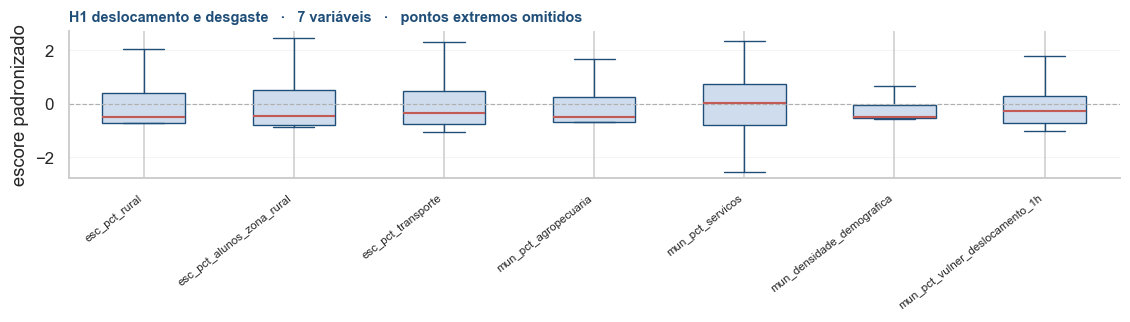

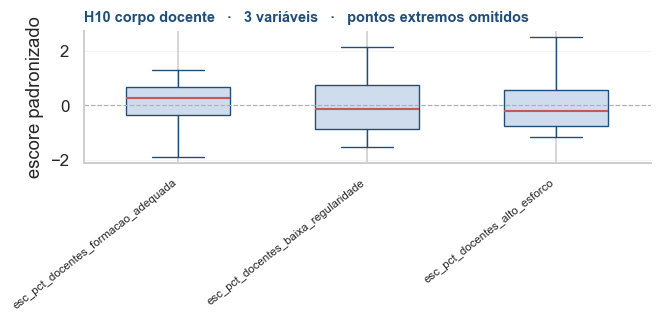

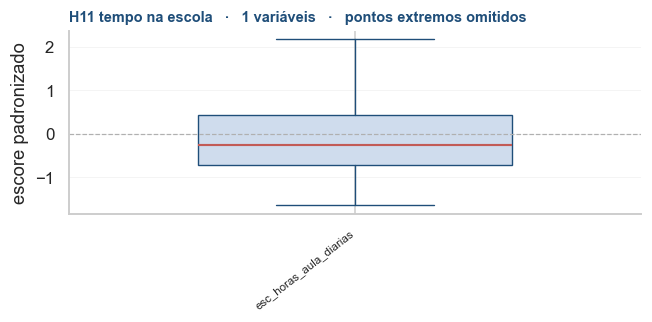

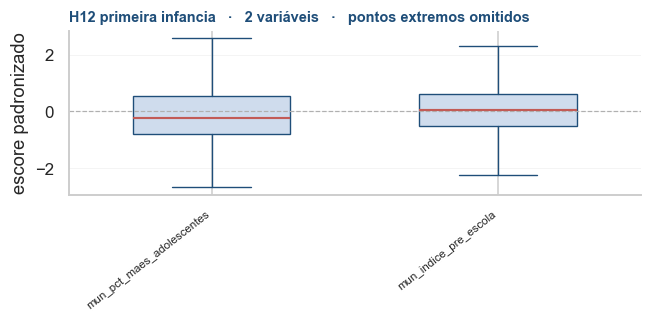

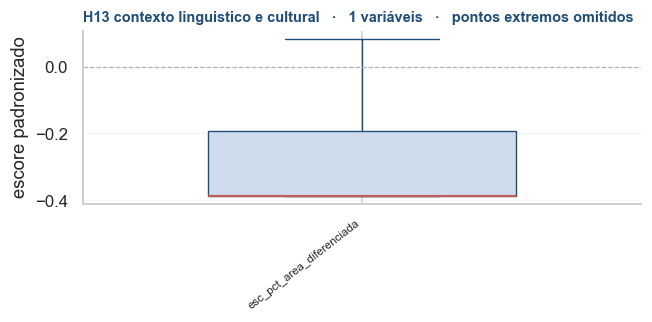

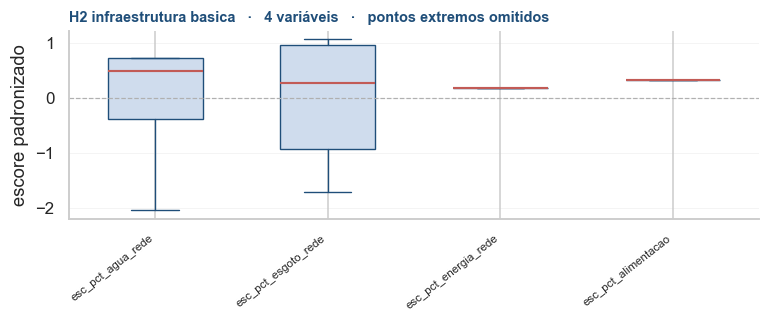

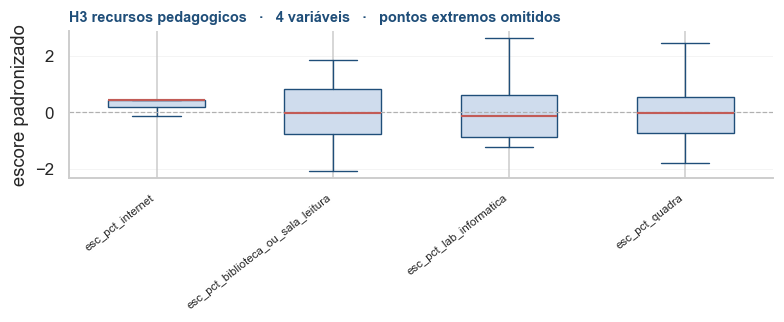

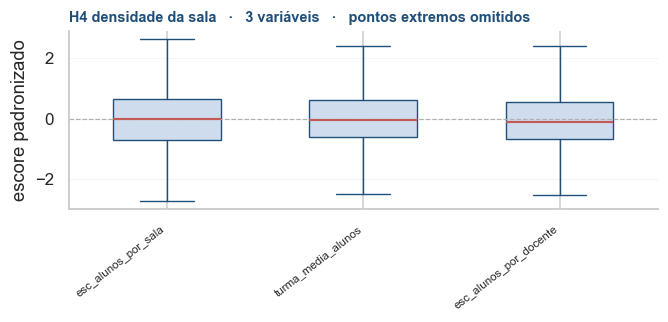

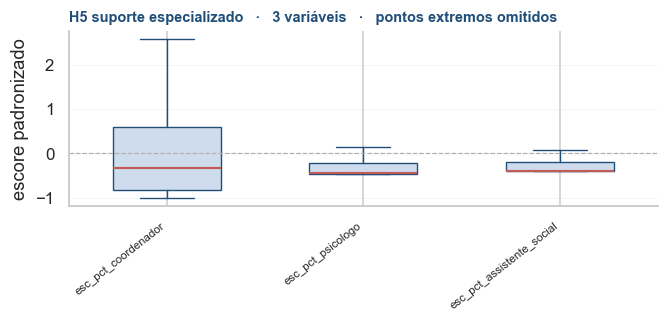

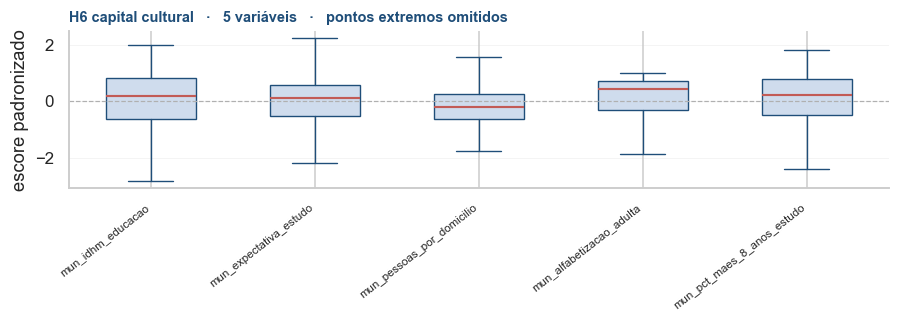

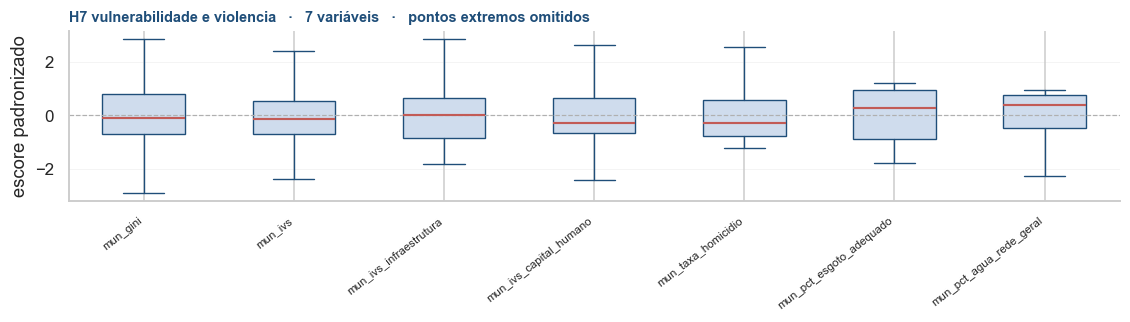

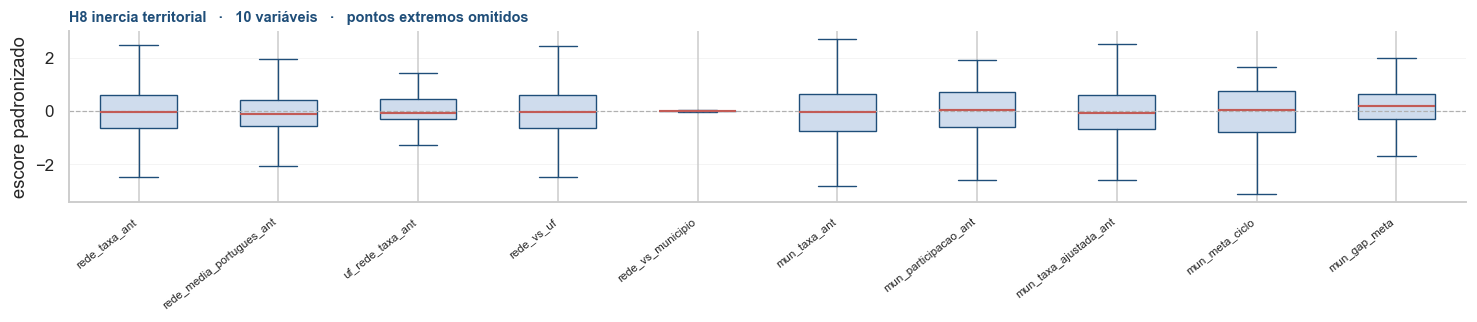

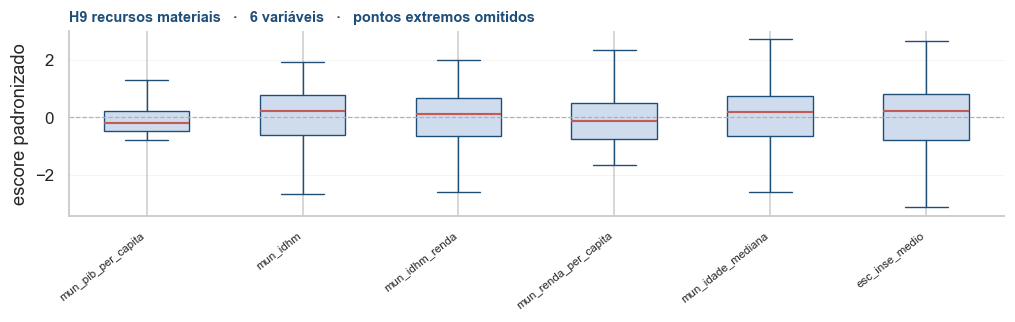

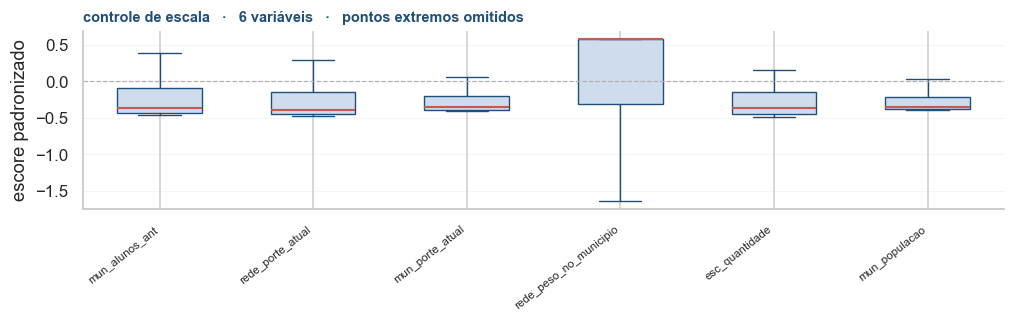

In [309]:
# --- 7.2 Boxplots padronizados, por bloco de hipótese ---
def padronizar(s: pd.Series) -> pd.Series:
    """Escore padronizado: preserva a forma e permite comparação visual."""
    v = pd.to_numeric(s, errors="coerce")
    desvio = v.std()
    return (v - v.mean()) / desvio if desvio and desvio > 0 else v * 0


blocos_numericos = sorted({mapa_hipotese.get(v, "não declarada")
                           for v in NUMERICAS})

for bloco in blocos_numericos:
    variaveis = [v for v in NUMERICAS
                 if mapa_hipotese.get(v, "não declarada") == bloco]
    if not variaveis:
        continue

    dados = [padronizar(base[v]).dropna().values for v in variaveis]
    fig, eixo = plt.subplots(figsize=(max(6, 1.05 * len(variaveis) + 3),
                                      3.0))
    caixas = eixo.boxplot(dados, vert=True, showfliers=False,
                          patch_artist=True, widths=.55,
                          medianprops={"color": "#c25b56", "linewidth": 1.4})
    for caixa in caixas["boxes"]:
        caixa.set(facecolor="#cfdced", edgecolor="#1f4e79", linewidth=.9)
    for parte in ("whiskers", "caps"):
        for artista in caixas[parte]:
            artista.set(color="#1f4e79", linewidth=.9)

    eixo.axhline(0, color="#b0b0b0", lw=.8, ls="--")
    eixo.set_xticks(range(1, len(variaveis) + 1))
    eixo.set_xticklabels(variaveis, rotation=38, ha="right", fontsize=7.5)
    eixo.set_ylabel("escore padronizado")
    eixo.set_title(f"{bloco}   ·   {len(variaveis)} variáveis   ·   "
                   "pontos extremos omitidos",
                   fontsize=9.5, loc="left", color="#1f4e79",
                   fontweight="bold")
    eixo.grid(axis="y", alpha=.22, lw=.6)
    plt.tight_layout()
    plt.show()

### 7.3 Exame dos casos extremos

Antes de decidir qualquer tratamento, é preciso distinguir dois tipos de valor extremo. O **erro de medida ou de construção** deve ser corrigido na origem, como ocorreu com a densidade de salas, cujo denominador estava errado. O **valor legítimo e raro** deve ser preservado: municípios muito densos, muito ricos ou muito violentos existem, e podem ser justamente os casos de interesse para política pública.

A célula abaixo examina as variáveis mais assimétricas nos dois extremos, para que essa distinção seja feita caso a caso e não por regra automática.

In [310]:
# --- 7.3 Os extremos das variáveis mais assimétricas ---
CANDIDATAS = forma.nlargest(6, "assimetria").index.tolist()

print("EXTREMOS DAS SEIS VARIÁVEIS MAIS ASSIMÉTRICAS")
print("=" * 84)
for col in CANDIDATAS:
    v = pd.to_numeric(base[col], errors="coerce").dropna()
    print(f"\n{col}   ({mapa_hipotese.get(col, 'não declarada')})")
    print(f"    mediana {v.median():>12,.1f}   "
          f"p99 {v.quantile(.99):>12,.1f}   máximo {v.max():>12,.1f}")

    # os municípios que ocupam o topo, para julgar se o valor é plausível
    topo = (base.loc[v.nlargest(200000).index, ["id_municipio", col]]
            .groupby("id_municipio")[col].first()
            .nlargest(5))
    print(f"    municípios no topo: "
          + ", ".join(f"{m} ({x:,.0f})" for m, x in topo.items()))

print()
print("=" * 84)
print("Leitura: valor extremo legítimo não deve ser removido. Municípios")
print("muito densos, muito ricos ou muito violentos existem e podem ser os")
print("casos de maior interesse. O tratamento a decidir na seção 12 é a")
print("transformação, que comprime a escala sem descartar observação, e não")
print("a exclusão de linhas.")

EXTREMOS DAS SEIS VARIÁVEIS MAIS ASSIMÉTRICAS

mun_pib_per_capita   (H9 recursos materiais)
    mediana     34,351.0   p99    216,073.0   máximo    920,828.0


    municípios no topo: 3115359 (920,828), 1502152 (894,763), 3161908 (684,163), 3133709 (610,742), 3204302 (580,174)

esc_pct_area_diferenciada   (H13 contexto linguistico e cultural)
    mediana          0.0   p99         55.8   máximo        100.0
    municípios no topo: 1705102 (100), 1713957 (100), 2509057 (100), 3204559 (100), 5204250 (100)

mun_alunos_ant   (controle de escala)
    mediana        889.0   p99     44,858.0   máximo     44,858.0
    municípios no topo: 3304557 (44,858), 1302603 (23,993), 2304400 (18,937), 3106200 (18,045), 2927408 (13,546)

mun_porte_atual   (controle de escala)
    mediana      1,305.0   p99    107,717.0   máximo    107,717.0
    municípios no topo: 3550308 (107,717), 3304557 (49,962), 1302603 (30,524), 5300108 (27,698), 3106200 (18,910)

esc_pct_assistente_social   (H5 suporte especializado)
    mediana          0.0   p99        100.0   máximo        100.0
    municípios no topo: 1100908 (100), 1301852 (100), 1501758 (100), 1702000 (100), 1703867

**Leitura.** Das 62 variáveis numéricas, 30 têm forma próxima da simétrica, 16 têm assimetria moderada e 16, assimetria forte. As de assimetria forte são de dois tipos, que pedem tratamentos diferentes:

1. **Cauda longa à direita:** PIB per capita, porte, população, número de escolas e as variáveis de presença rara (psicólogo, assistente social e área diferenciada). Nelas, a transformação logarítmica ou por quantis comprime a escala sem descartar observação.
2. **Concentração perto de 100%:** energia elétrica, alimentação e internet. A regra automática também sugere transformação para elas, mas a assimetria vem de quase todas as redes estarem no máximo, e não de uma cauda longa. Transformar não resolve; a questão é se elas informam alguma coisa, e isso é visto na seção 8.

Os extremos examinados são legítimos. No porte e na população, o topo é ocupado pelas capitais: São Paulo, Rio de Janeiro, Manaus, Brasília, Belo Horizonte, Salvador e Fortaleza. No PIB per capita, os cinco maiores valores, de 580 mil a 920 mil reais por habitante, estão em municípios de 5 mil a 39 mil habitantes cuja renda por pessoa, entre 420 e 517 reais de 2010, fica perto da mediana dos municípios da base (468 reais). É riqueza produzida no território sem ser apropriada pela população, o risco previsto na H9.

📌 **Consequência para a modelagem.** Nenhum extremo examinado é erro de construção, e nenhuma linha é excluída. A transformação das variáveis de cauda longa é decidida na seção 12 e só importa para modelos lineares, porque os modelos de árvore usam apenas a ordem dos valores.

### 7.4 Padrões de ausência

Detectados os valores extremos, resta o outro problema de qualidade: os dados ausentes. A pergunta a responder aqui não é quantos faltam, que o inventário da seção 1 já mostrou, e sim **por que faltam**, porque disso depende o tratamento.

🎓 **Conceito, mecanismos de ausência:** a estatística distingue três casos. Quando a falta não depende de nada observável (*missing completely at random*), qualquer imputação razoável é inofensiva. Quando depende de outras variáveis observadas (*missing at random*), a imputação deve condicionar-se a elas, tomando a média do estado em vez da média geral. Quando depende do próprio valor que falta (*missing not at random*), nenhuma imputação recupera a informação, e a ausência precisa ser sinalizada ao modelo como característica própria.

Distinguir os casos exige olhar dois aspectos: se as ausências ocorrem **em blocos**, com várias variáveis faltando juntas, o que denuncia origem comum, e se o grupo com ausência **difere no desfecho**, o que indicaria que a falta carrega informação.

In [311]:
# --- 7.4 Onde e como os dados faltam ---
faltantes = [c for c in FEATURES if base[c].isna().any()]

print("VARIÁVEIS COM AUSÊNCIA NA BASE COMPLETA")
print("=" * 70)
resumo_ausencia = (pd.DataFrame({
        "hipotese": [mapa_hipotese.get(c, "não declarada") for c in faltantes],
        "ausentes": base[faltantes].isna().sum().values,
        "pct": (100 * base[faltantes].isna().mean()).round(1).values},
        index=faltantes)
    .sort_values("pct", ascending=False))
print(resumo_ausencia.to_string())

print()
print("PADRÕES DE AUSÊNCIA")
print("=" * 70)
print("Cada linha é uma combinação distinta de variáveis faltando juntas.")
print("Ausência em bloco indica origem comum, e não falha aleatória.")
print()
mapa_letras = {c: str(i + 1) for i, c in enumerate(faltantes)}
padrao = base[faltantes].isna().apply(
    lambda linha: "".join("X" if v else "." for v in linha), axis=1)
contagem = padrao.value_counts()

for pat, n in contagem.head(8).items():
    quais = [faltantes[i] for i, ch in enumerate(pat) if ch == "X"]
    rotulo = "completo" if not quais else (
        f"{len(quais)} variáveis" if len(quais) > 3 else ", ".join(quais))
    print(f"  {n:>9,}  ({100*n/len(base):>5.1f}%)   {rotulo}")
if len(contagem) > 8:
    print(f"  {contagem.iloc[8:].sum():>9,}  "
          f"({100*contagem.iloc[8:].sum()/len(base):>5.1f}%)   "
          f"outras {len(contagem)-8} combinações, todas residuais")

print()
print("A AUSÊNCIA CARREGA INFORMAÇÃO?")
print("=" * 70)
print("Se o grupo com ausência tivesse desfecho muito distinto, a própria")
print("falta seria informativa e precisaria ser sinalizada ao modelo.")
print()
for col in resumo_ausencia.head(4).index:
    ausente = base[col].isna()
    dif = 100 * (base.loc[ausente, "alvo"].mean()
                 - base.loc[~ausente, "alvo"].mean())
    print(f"  {col:<26} ausente {100*base.loc[ausente,'alvo'].mean():>5.1f}%   "
          f"presente {100*base.loc[~ausente,'alvo'].mean():>5.1f}%   "
          f"diferença {dif:>+5.1f} pp")

resumo_ausencia

VARIÁVEIS COM AUSÊNCIA NA BASE COMPLETA
                                                                hipotese  ausentes   pct
mun_participacao_ant                              H8 inercia territorial    428119  23.1
mun_alunos_ant                                        controle de escala    428119  23.1
mun_taxa_ajustada_ant                             H8 inercia territorial    428119  23.1
mun_gap_meta                                      H8 inercia territorial    250035  13.5
mun_meta_ciclo                                    H8 inercia territorial    250035  13.5
rede_vs_municipio                                 H8 inercia territorial    200800  10.8
mun_taxa_ant                                      H8 inercia territorial    199609  10.8
rede_vs_uf                                        H8 inercia territorial     35582   1.9
rede_taxa_ant                                     H8 inercia territorial     35582   1.9
rede_media_portugues_ant                          H8 inercia territori

,hipotese,ausentes,pct
mun_participacao_ant,H8 inercia territorial,428119,23.1
mun_alunos_ant,controle de escala,428119,23.1
mun_taxa_ajustada_ant,H8 inercia territorial,428119,23.1
mun_gap_meta,H8 inercia territorial,250035,13.5
mun_meta_ciclo,H8 inercia territorial,250035,13.5
rede_vs_municipio,H8 inercia territorial,200800,10.8
mun_taxa_ant,H8 inercia territorial,199609,10.8
rede_vs_uf,H8 inercia territorial,35582,1.9
rede_taxa_ant,H8 inercia territorial,35582,1.9
rede_media_portugues_ant,H8 inercia territorial,35582,1.9


### 7.5 Viabilidade da imputação hierárquica

O tratamento natural para uma variável municipal ausente é substituí-la pela mediana do seu estado: municípios do mesmo estado compartilham política educacional, condições econômicas e características regionais, e a mediana estadual é uma estimativa melhor que a mediana nacional.

⚠️ Essa estratégia pressupõe que o estado seja conhecido. Numa versão anterior desta análise, a UF faltava para cerca de 10% dos alunos, justamente os que também não tinham histórico municipal, e a imputação hierárquica ficaria inviável onde era mais necessária. A causa era de origem: a UF vinha da tabela municipal do ciclo anterior, que só cobre os municípios avaliados naquele ano. A base passou a obter o território do Censo Demográfico de 2022, e a célula abaixo confirma que a lacuna foi fechada.

In [312]:
# --- 7.5 A imputação por estado é aplicável a todos os casos? ---
sem_uf = base["sigla_uf"].isna()
sem_historico = base["mun_taxa_ajustada_ant"].isna()

print("SOBREPOSIÇÃO ENTRE AS DUAS AUSÊNCIAS")
print("=" * 70)
print(f"  alunos sem sigla_uf                        {sem_uf.sum():>9,}")
print(f"  alunos sem histórico municipal             {sem_historico.sum():>9,}")
print(f"  sem histórico E sem UF, imputação inviável "
      f"{(sem_uf & sem_historico).sum():>9,}"
      f"  ({100*(sem_uf & sem_historico).sum()/max(sem_historico.sum(),1):.0f}%"
      f" dos sem histórico)")
print(f"  sem histórico mas com UF, imputável        "
      f"{(~sem_uf & sem_historico).sum():>9,}")
print()

# Os municípios sem UF na base: quantos são e onde de fato ficam
sem = base.loc[sem_uf, "id_municipio"]
print(f"  municípios sem UF na base analítica: {sem.nunique():,}")
print()
print("Leitura: a UF passou a vir do Censo Demográfico de 2022, que cobre")
print("todos os municípios do país, e deixou de faltar. A imputação pela")
print("mediana do estado é, portanto, aplicável a todos os alunos sem")
print("histórico municipal.")
print()
print("DECISÃO REGISTRADA")
print("=" * 70)
print("  1. sigla_uf e nome_regiao vêm de fonte completa, o Censo de 2022,")
print("     desde a construção da base; a ausência delas é zero.")
print("  2. as variáveis do histórico municipal, que faltam porque o")
print("     município não foi avaliado no ciclo anterior e não têm fonte")
print("     alternativa, são imputadas pela mediana do estado e acompanhadas")
print("     de um indicador de ausência, para que o modelo possa distinguir")
print("     valor observado de valor estimado.")
print("  3. a imputação é ajustada apenas na partição de treino e aplicada")
print("     às demais, dentro do pipeline, para não vazar informação.")

SOBREPOSIÇÃO ENTRE AS DUAS AUSÊNCIAS
  alunos sem sigla_uf                                0
  alunos sem histórico municipal               428,119
  sem histórico E sem UF, imputação inviável         0  (0% dos sem histórico)
  sem histórico mas com UF, imputável          428,119

  municípios sem UF na base analítica: 0

Leitura: a UF passou a vir do Censo Demográfico de 2022, que cobre
todos os municípios do país, e deixou de faltar. A imputação pela
mediana do estado é, portanto, aplicável a todos os alunos sem
histórico municipal.

DECISÃO REGISTRADA
  1. sigla_uf e nome_regiao vêm de fonte completa, o Censo de 2022,
     desde a construção da base; a ausência delas é zero.
  2. as variáveis do histórico municipal, que faltam porque o
     município não foi avaliado no ciclo anterior e não têm fonte
     alternativa, são imputadas pela mediana do estado e acompanhadas
     de um indicador de ausência, para que o modelo possa distinguir
     valor observado de valor estimado.
  3. a

**Leitura.** 73,7% dos alunos têm todas as variáveis preenchidas. As ausências se concentram nas variáveis de desempenho anterior (H8) e aparecem em blocos, cada um com uma origem conhecida:

- 12,3% dos alunos não têm participação, taxa ajustada e número de alunos de 2023: o município consta do indicador oficial, mas não tem microdados públicos, o ponto cego identificado na fase anterior.
- 10,7% não têm o indicador oficial de 2023 do município nem meta registrada; em parte deles (1,9% dos alunos), também falta o desempenho anterior da rede.
- 2,6% têm o histórico, mas não têm meta pactuada.

Fora do desempenho anterior, nenhuma variável passa de 1% de ausência; a maior é o INSE da rede, com 0,5%.

A ausência carrega pouca informação sobre o desfecho: os alunos sem os dados dos microdados têm taxa 1,7 ponto menor, e os sem meta, 3,8 pontos menor. É pouco, mas não é zero, o que sustenta a decisão registrada na 7.5: imputar pela mediana do estado e acrescentar um indicador de ausência, para que o modelo distinga valor observado de valor estimado. Como a UF vem do Censo de 2022, a imputação por estado é aplicável a todos os 428 mil alunos sem o histórico dos microdados.

📌 **Consequência para a modelagem.** A imputação e os indicadores de ausência são ajustados apenas na partição de treino e aplicados às demais, dentro do pipeline, para não vazar informação.

---

## 8. Análise bivariada: variáveis numéricas e a resposta

**Passos desta seção:** (8.1) estabelecer a magnitude alcançável por uma variável de contexto; (8.2) taxa de alfabetização por faixa de cada variável; (8.3) quantificar amplitude e monotonicidade de cada relação.

Aqui cada variável é confrontada com a variável resposta. O que se busca é a **forma** da relação, isto é, se existe gradiente, se ele é monotônico e onde está o degrau, e não apenas a sua força. A forma é o que orienta a transformação e a escolha do algoritmo; a força vem depois, na seção 11.

### 8.1 A magnitude alcançável por uma variável de contexto

Antes de comparar as relações, é preciso saber que magnitude esperar. Sem essa referência, um gradiente de três pontos percentuais pode parecer desprezível quando na verdade representa boa parte do que é possível capturar.

🎓 **Conceito, teto de uma variável agregada:** todas as variáveis explicativas desta base estão no grão do município ou da rede. Nenhuma distingue dois alunos da mesma rede no mesmo município, porque os microdados públicos do INEP não trazem atributos do estudante. Existe, portanto, um limite superior: a **melhor variável municipal concebível** não pode separar alunos que ela enxerga como idênticos.

Esse limite é mensurável. A taxa de alfabetização observada em cada município, calculada a partir da própria resposta, é a variável municipal mais informativa que poderia existir, e nenhuma outra pode superá-la. Ela **não entra no modelo**: serve apenas para medir o teto.

A decomposição da variância separa o que vem da diferença **entre** municípios, que o contexto alcança, do que vem da diferença **dentro** de cada município, que nenhuma variável desta base pode capturar.

In [313]:
# --- 8.1 Teto estrutural das variáveis de contexto ---
# A taxa observada do próprio município é construída a partir da resposta.
# Não é variável do modelo: serve só para medir o limite superior.
taxa_do_municipio = treino.groupby("id_municipio")["alvo"].transform("mean")
teto = float(np.corrcoef(taxa_do_municipio, treino["alvo"])[0, 1])

media_geral = float(treino["alvo"].mean())
var_total = float(treino["alvo"].var(ddof=0))
var_entre = float(((taxa_do_municipio - media_geral) ** 2).mean())
var_dentro = var_total - var_entre

# amplitude da melhor variável possível, na mesma unidade dos gráficos adiante
melhor = pd.DataFrame({"x": taxa_do_municipio, "alvo": treino["alvo"]})
melhor["faixa"] = pd.qcut(melhor["x"].rank(method="first"), 5, labels=False)
extremos = melhor.groupby("faixa")["alvo"].mean()
amplitude_maxima = 100 * (extremos.iloc[-1] - extremos.iloc[0])

print("TETO ESTRUTURAL DAS VARIÁVEIS DE CONTEXTO")
print("=" * 66)
print(f"  correlação da taxa do município com o resultado do aluno  {teto:>6.3f}")
print(f"  variância do resultado explicada pelo município           {teto**2:>6.1%}")
print(f"  amplitude entre o primeiro e o último quintil               "
      f"{amplitude_maxima:>5.1f} pp")
print()
print("DE ONDE VEM A VARIAÇÃO DO RESULTADO INDIVIDUAL")
print(f"  entre municípios, alcançável pelo contexto   {var_entre/var_total:>6.1%}")
print(f"  dentro do município, fora do nosso alcance   {var_dentro/var_total:>6.1%}")
print("=" * 66)
print()
print("Leitura: nenhuma variável desta base pode superar essa amplitude.")
print("Os gradientes das próximas células devem ser lidos como fração dela,")
print("e não em termos absolutos.")

TETO ESTRUTURAL DAS VARIÁVEIS DE CONTEXTO
  correlação da taxa do município com o resultado do aluno   0.307
  variância do resultado explicada pelo município             9.4%
  amplitude entre o primeiro e o último quintil                42.5 pp

DE ONDE VEM A VARIAÇÃO DO RESULTADO INDIVIDUAL
  entre municípios, alcançável pelo contexto     9.4%
  dentro do município, fora do nosso alcance    90.6%

Leitura: nenhuma variável desta base pode superar essa amplitude.
Os gradientes das próximas células devem ser lidos como fração dela,
e não em termos absolutos.


### 8.2 Taxa de alfabetização por faixa

🎓 **Conceito, por que a taxa por faixa e não a correlação:** a variável resposta é binária e as explicativas são contínuas. A correlação de Pearson entre as duas é matematicamente válida e tem nome próprio, correlação bisserial por pontos, mas enxerga apenas relação **monotônica e linear**, e seu valor máximo fica limitado pelo equilíbrio das classes. Uma relação em forma de U aparece como correlação próxima de zero.

Dividir os alunos em faixas de igual tamanho e calcular a proporção de alfabetizados em cada uma mostra a **forma** da relação, revela não monotonicidade e é diretamente interpretável: "alunos no quintil mais baixo têm X% de alfabetização, contra Y% no mais alto".

⚠️ **Os gráficos trazem os dois cortes.** A linha grossa são os quintis, que agrupam cerca de 600 municípios por faixa; a linha fina são os decis, com cerca de 300. Menos faixas significam menor erro amostral e menos inversões espúrias, ao custo de resolução. Sobrepor os dois permite ver a forma fina sem confundir oscilação de granularidade com característica da relação. A seção 8.4 quantifica essa diferença.

A correlação linear, que o enunciado do projeto pede explicitamente, é calculada na seção 9, ao lado da matriz entre as explicativas.

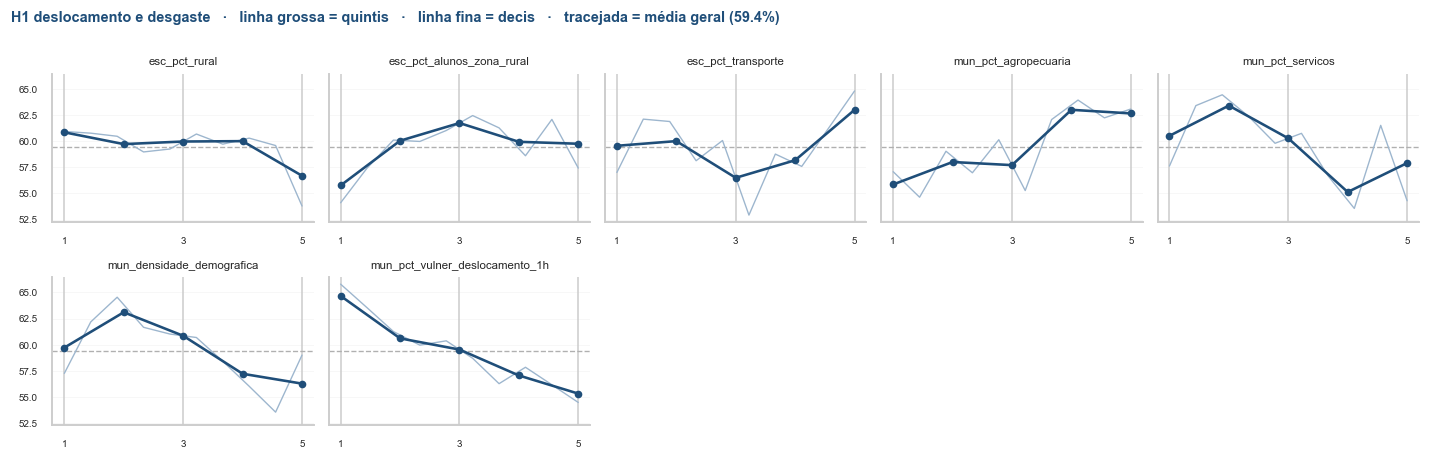

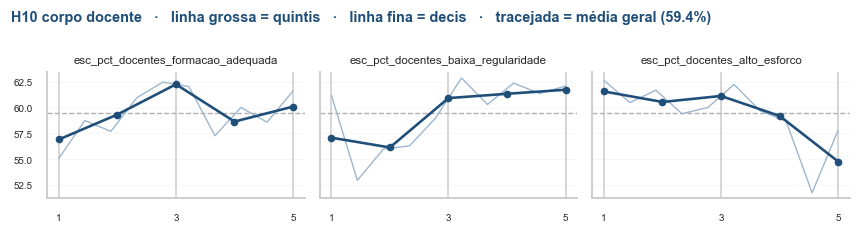

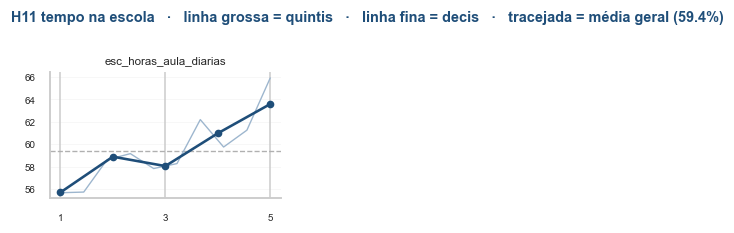

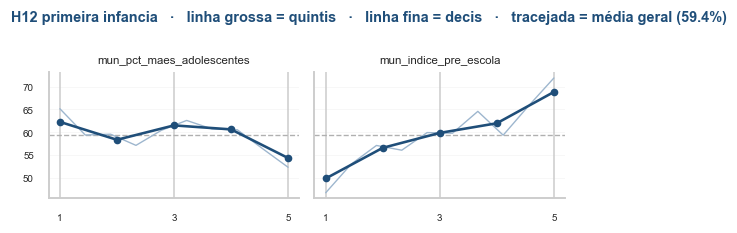

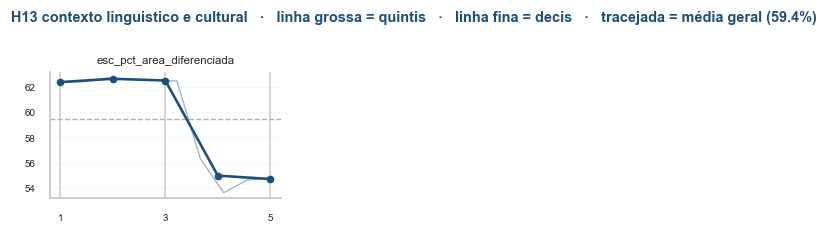

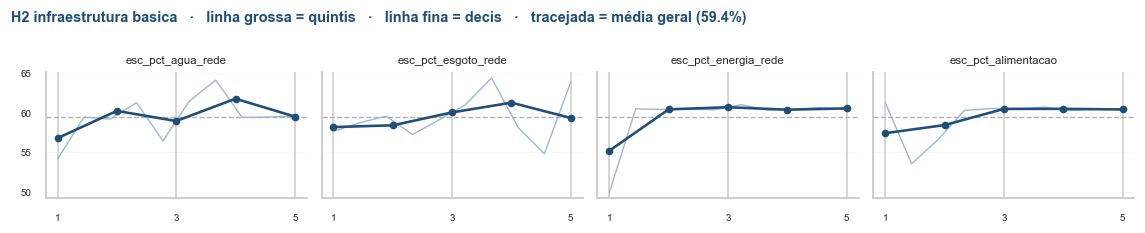

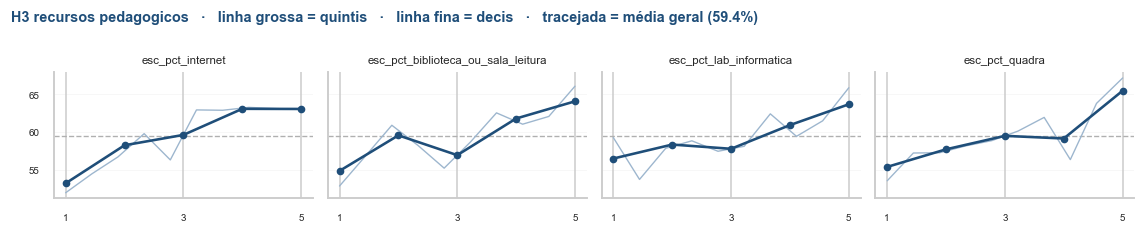

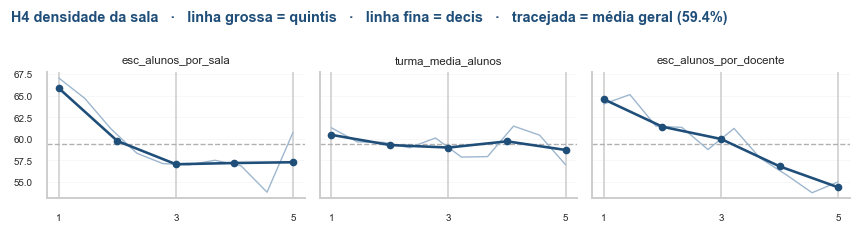

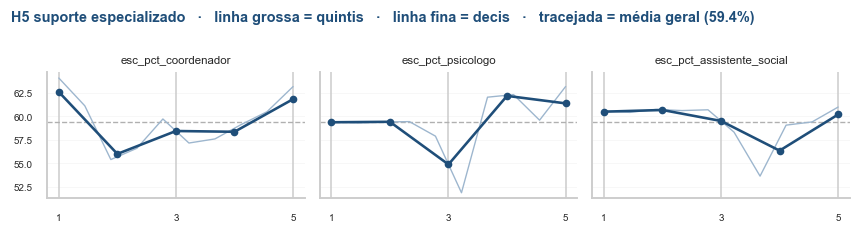

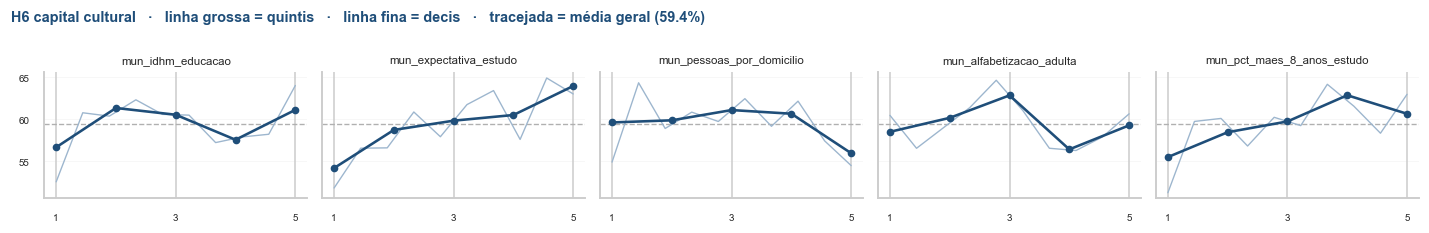

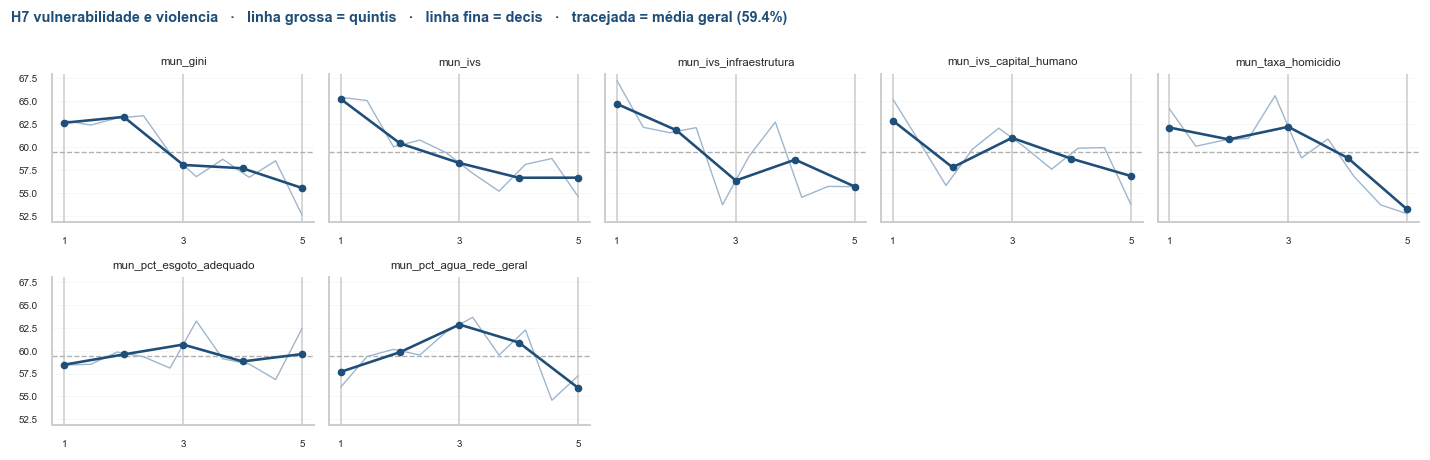

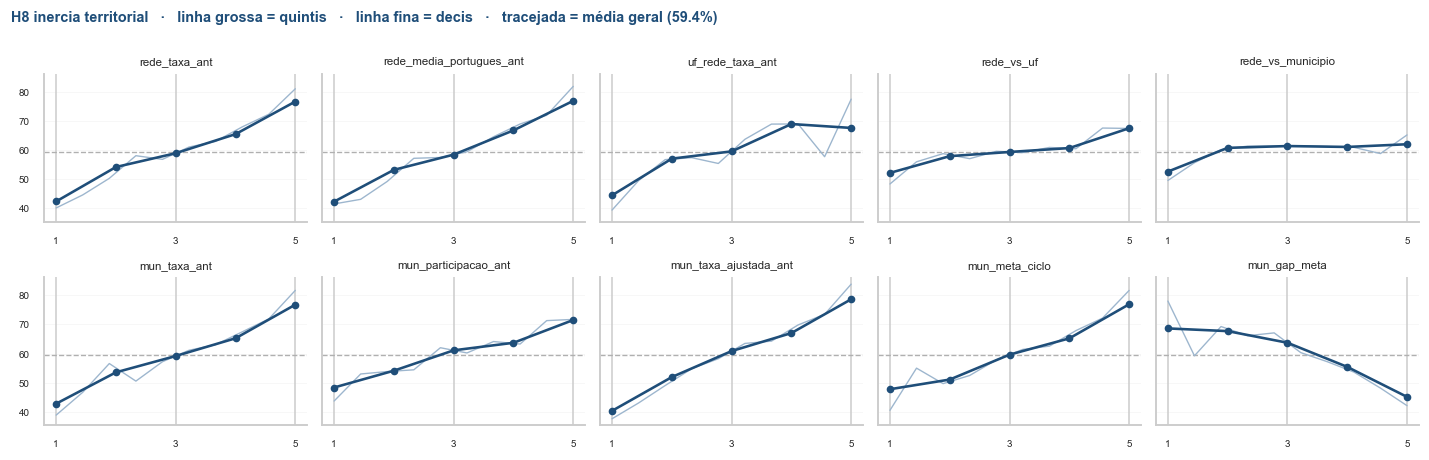

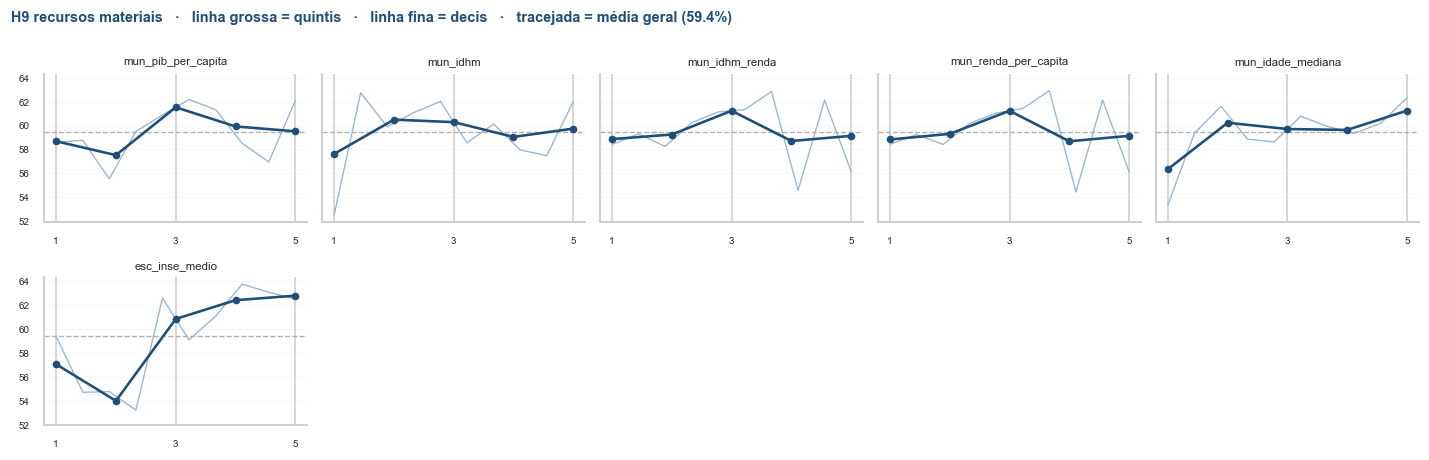

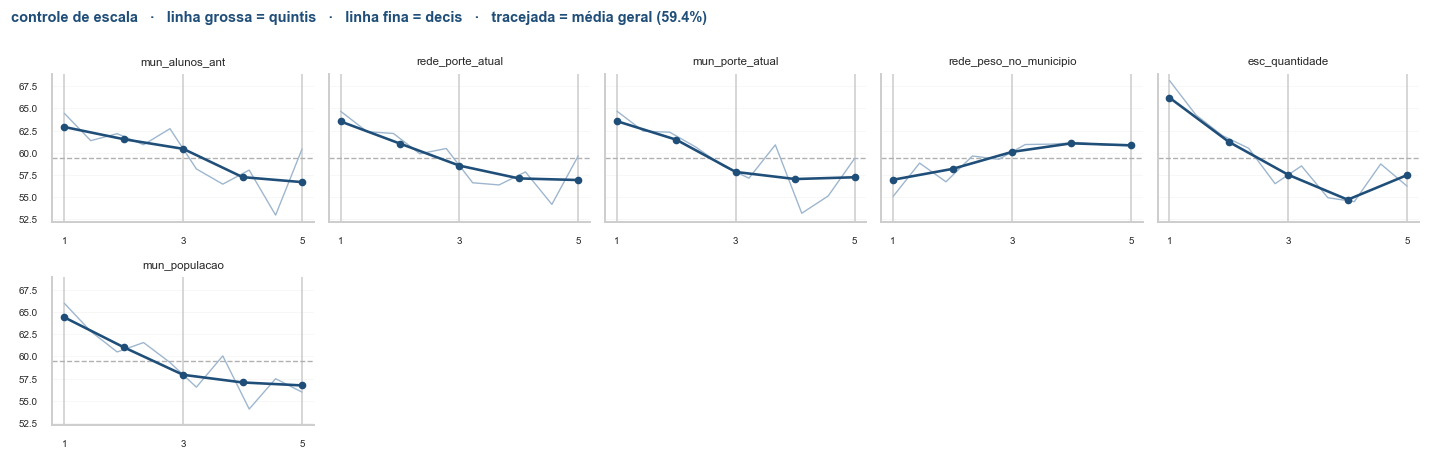

In [314]:
# --- 8.2 Taxa de alfabetização por faixa, em quintis e decis ---
def taxa_por_faixa(df: pd.DataFrame, variavel: str, n: int = 5) -> pd.DataFrame:
    """Taxa observada da resposta em faixas de igual tamanho da variável.

    O rank antes do corte evita que valores repetidos concentrem a massa
    numa faixa só, o que ocorreria em variáveis com muitos empates.
    """
    d = df[[variavel, "alvo", "id_municipio"]].dropna()
    if d[variavel].nunique() < n:
        return pd.DataFrame()
    d = d.assign(faixa=pd.qcut(d[variavel].rank(method="first"), n,
                               labels=range(1, n + 1)))
    return (d.groupby("faixa", observed=True)
            .agg(alunos=("alvo", "size"), taxa=("alvo", "mean"),
                 municipios=("id_municipio", "nunique"),
                 valor=(variavel, "mean"))
            .assign(taxa=lambda x: 100 * x["taxa"]))


taxa_global = 100 * float(treino["alvo"].mean())

for bloco in blocos_numericos:
    variaveis = [v for v in NUMERICAS
                 if mapa_hipotese.get(v, "não declarada") == bloco]
    if not variaveis:
        continue

    n_col = min(5, len(variaveis))
    n_lin = int(np.ceil(len(variaveis) / n_col))
    fig, eixos = plt.subplots(n_lin, n_col,
                              figsize=(2.6 * n_col, 2.05 * n_lin),
                              sharey=True)
    eixos = np.atleast_1d(eixos).ravel()

    for eixo, v in zip(eixos, variaveis):
        g5 = taxa_por_faixa(treino, v, 5)
        g10 = taxa_por_faixa(treino, v, 10)
        if g5.empty:
            eixo.axis("off")
            continue
        eixo.axhline(taxa_global, color="#b0b0b0", lw=.9, ls="--", zorder=1)
        if not g10.empty:
            # decis em traço fino: mostram a forma fina, com mais ruído
            eixo.plot(np.linspace(1, 5, 10), g10["taxa"], "-",
                      color="#9db6ce", lw=.9, zorder=2)
        eixo.plot(g5.index.astype(int), g5["taxa"], "o-", color="#1f4e79",
                  lw=1.7, ms=4, zorder=3)
        eixo.set_title(v, fontsize=7.5)
        eixo.set_xticks([1, 3, 5])
        eixo.tick_params(labelsize=6.5)
        eixo.grid(axis="y", alpha=.2, lw=.5)

    for eixo in eixos[len(variaveis):]:
        eixo.axis("off")

    fig.suptitle(f"{bloco}   ·   linha grossa = quintis   ·   "
                 f"linha fina = decis   ·   tracejada = média geral "
                 f"({taxa_global:.1f}%)",
                 fontsize=9.5, y=1.005, x=.005, ha="left",
                 fontweight="bold", color="#1f4e79")
    plt.tight_layout()
    plt.show()

### 8.3 Amplitude e monotonicidade

O gráfico mostra a forma; esta célula a quantifica, com duas medidas.

A **amplitude** é a diferença em pontos percentuais entre o último e o primeiro quintil. Ela responde quanto a variável separa os extremos, e é lida como fração do teto medido em 8.1.

A **monotonicidade** é a correlação de postos entre o número da faixa e a taxa observada nela. Valor próximo de 1 indica gradiente que sobe de forma consistente; próximo de −1, gradiente que desce; próximo de zero, relação sem direção estável, que pode ser não monotônica ou apenas ruído.

🎓 **Por que a monotonicidade importa para a modelagem:** relação monotônica é bem representada por modelos lineares e por transformações simples. Relação não monotônica exige modelo capaz de captar a curva, como árvores ou termos de interação, e é um argumento concreto na escolha do algoritmo, feita na seção 12.

In [315]:
# --- 8.3 Amplitude e monotonicidade, em quintis ---
# Os quintis são a referência: com o dobro de municípios por faixa, o erro
# amostral cai e a forma da relação aparece com menos ruído. Os decis ficam
# na 8.4, para separar a inversão real do artefato de granularidade.
linhas = []
for v in NUMERICAS:
    g = taxa_por_faixa(treino, v, 5)
    if g.empty or len(g) < 3:
        continue
    faixas = pd.Series(g.index.astype(int), dtype="float64")
    taxas = pd.Series(g["taxa"].to_numpy(), dtype="float64")
    # correlação de postos entre o número da faixa e a taxa observada nela
    monotonicidade = float(faixas.corr(taxas, method="spearman"))
    amplitude = float(taxas.iloc[-1] - taxas.iloc[0])
    linhas.append({
        "variavel": v,
        "hipotese": mapa_hipotese.get(v, "não declarada"),
        "taxa_primeiro_quintil": round(float(taxas.iloc[0]), 1),
        "taxa_ultimo_quintil": round(float(taxas.iloc[-1]), 1),
        "amplitude_pp": round(amplitude, 1),
        "pct_do_teto": round(100 * abs(amplitude) / amplitude_maxima, 0),
        "monotonicidade": round(monotonicidade, 2),
        "municipios_por_quintil": int(g["municipios"].median()),
    })

bivariada = (pd.DataFrame(linhas)
             .sort_values("amplitude_pp", key=abs, ascending=False)
             .set_index("variavel"))

# A classificação da forma fica concentrada na seção 8.4, que pesa a
# magnitude das inversões e as compara com o erro amostral. Aqui ficam
# apenas as medidas brutas.

print(f"{len(bivariada)} variáveis numéricas confrontadas com a resposta")
print(f"amplitude máxima possível (teto da seção 8.1): "
      f"{amplitude_maxima:.1f} pontos percentuais")
print()
print("AS QUINZE DE MAIOR AMPLITUDE")
print("=" * 112)
print(bivariada.head(15).to_string())

# O DataFrame fica disponível para inspeção e filtro no próprio notebook.
# Exemplos: bivariada.query("hipotese.str.startswith('H1')")
#           bivariada.nsmallest(10, "monotonicidade")
bivariada

62 variáveis numéricas confrontadas com a resposta
amplitude máxima possível (teto da seção 8.1): 42.5 pontos percentuais

AS QUINZE DE MAIOR AMPLITUDE
                                         hipotese  taxa_primeiro_quintil  taxa_ultimo_quintil  amplitude_pp  pct_do_teto  monotonicidade  municipios_por_quintil
variavel                                                                                                                                                        
mun_taxa_ajustada_ant      H8 inercia territorial                   40.3                 78.7          38.3         90.0             1.0                     526
rede_media_portugues_ant   H8 inercia territorial                   42.3                 76.9          34.6         82.0             1.0                     640
rede_taxa_ant              H8 inercia territorial                   42.3                 76.6          34.3         81.0             1.0                     664
mun_taxa_ant               H8 inercia terri

,hipotese,taxa_primeiro_quintil,taxa_ultimo_quintil,amplitude_pp,pct_do_teto,monotonicidade,municipios_por_quintil
variavel,,,,,,,
mun_taxa_ajustada_ant,H8 inercia territorial,40.3,78.7,38.3,90.0,1.0,526
rede_media_portugues_ant,H8 inercia territorial,42.3,76.9,34.6,82.0,1.0,640
rede_taxa_ant,H8 inercia territorial,42.3,76.6,34.3,81.0,1.0,664
mun_taxa_ant,H8 inercia territorial,42.8,76.8,34.0,80.0,1.0,560
mun_meta_ciclo,H8 inercia territorial,47.8,76.9,29.2,69.0,1.0,469
mun_gap_meta,H8 inercia territorial,68.6,45.1,-23.5,55.0,-1.0,517
mun_participacao_ant,H8 inercia territorial,48.4,71.5,23.2,55.0,1.0,522
uf_rede_taxa_ant,H8 inercia territorial,44.4,67.6,23.1,55.0,0.9,824
mun_indice_pre_escola,H12 primeira infancia,49.9,68.8,18.9,45.0,1.0,677


### 8.4 Diagnóstico robusto da forma, e a comparação entre variáveis acionáveis

A classificação da célula anterior tem duas fragilidades que precisam ser corrigidas antes de qualquer conclusão.

**A primeira é a medida de forma.** A correlação de postos sobre dez pontos pune uma inversão pequena com o mesmo peso de uma desordem real. Uma variável cujo gradiente é claro e consistente, mas que tem um decil fora de ordem, aparece como "tendência com ruído" ao lado de outra que oscila sem direção. São situações distintas e a distinção importa: a primeira sustenta a hipótese, a segunda não.

Duas medidas resolvem isso:

- a **consistência de direção** é a fração dos nove degraus entre decis que seguem o sentido do gradiente geral. Ela responde se a variável sobe de forma sustentada, tolerando inversão isolada;
- o **ruído relativo** é a soma das variações contrárias dividida pela soma de todas as variações. Ele mede o peso das inversões: valor baixo significa que elas são pequenas diante do movimento principal.

**A segunda fragilidade é o termo de comparação.** As variáveis da H8 medem o desempenho passado do mesmo território cujo desempenho futuro se quer prever. A associação forte que elas exibem é, em boa medida, tautológica: dizer que um município com baixa alfabetização em 2023 terá baixa alfabetização em 2024 descreve persistência, não explica causa, e não oferece alavanca, porque **nenhum gestor pode alterar o passado**.

Comparar as demais hipóteses contra esse patamar achata todas elas e esconde as diferenças que importam para política pública. Por isso a segunda parte desta célula mostra também o ranking **só entre as variáveis acionáveis**, sem a H8 e os controles de escala e território. É uma segunda leitura, para a pergunta sobre o que um gestor pode mudar: a H8 e os controles continuam no conjunto de variáveis que segue para a modelagem.

> ⚠️ Isso não elimina a H8 do modelo. Ela permanece, tanto por ser boa preditora quanto por ser o termo de controle contra o qual o ganho das demais será medido na etapa de modelagem. O que muda aqui é apenas o termo de comparação da leitura exploratória.

In [316]:
# --- 8.4 Fidelidade de direção, em dois níveis de granularidade ---
def diagnosticar_gradiente(df: pd.DataFrame, variavel: str,
                           n: int = 10) -> dict:
    """Mede a forma do gradiente pesando as inversões pela sua magnitude.

    ruido_relativo: soma das variações contrárias sobre a soma de todas.
        Pondera cada inversão pelo seu tamanho. Contar degraus fora de
        ordem sem pesar magnitude trata um tropeço de dois pontos como
        se fosse um de dez.

    erro_amostral_pp: incerteza esperada da taxa de cada faixa. O tamanho
        efetivo da amostra não é o número de alunos, e sim o de municípios:
        a variável é constante dentro do município, e alunos do mesmo
        território não são observações independentes. Inversão menor que
        essa faixa não é distinguível do acaso.
    """
    d = df[[variavel, "alvo", "id_municipio"]].dropna()
    if d[variavel].nunique() < n:
        return {}
    d = d.assign(faixa=pd.qcut(d[variavel].rank(method="first"), n,
                               labels=range(1, n + 1)))
    g = d.groupby("faixa", observed=True).agg(
        alunos=("alvo", "size"), taxa=("alvo", "mean"),
        municipios=("id_municipio", "nunique"))
    taxas = 100 * g["taxa"].to_numpy()

    degraus = np.diff(taxas)
    amplitude = float(taxas[-1] - taxas[0])
    sentido = np.sign(amplitude) if amplitude != 0 else 1
    contra = degraus[np.sign(degraus) == -sentido]
    total = float(np.abs(degraus).sum())

    p = float(g["taxa"].mean())
    n_efetivo = float(g["municipios"].median())
    erro = 100 * np.sqrt(p * (1 - p) / n_efetivo)
    maior = float(np.abs(contra).max()) if len(contra) else 0.0

    return {"amplitude_pp": round(amplitude, 1),
            "ruido_relativo": round(float(np.abs(contra).sum()) / total, 2)
            if total > 0 else np.nan,
            "maior_inversao_pp": round(maior, 1),
            "erro_amostral_pp": round(float(erro), 1),
            "inversao_real": bool(maior > erro),
            "municipios_por_faixa": int(g["municipios"].median())}


def montar(n: int, sufixo: str) -> pd.DataFrame:
    linhas = []
    for v in NUMERICAS:
        d = diagnosticar_gradiente(treino, v, n)
        if d:
            linhas.append({"variavel": v, **d})
    return (pd.DataFrame(linhas).set_index("variavel")
            .add_suffix(sufixo))


# Menos faixas significam mais municípios em cada uma, e portanto menor
# erro amostral: parte das inversões observadas nos decis desaparece nos
# quintis. Comparar os dois cortes separa a inversão real do artefato de
# granularidade.
por_decil = montar(10, "_d")
por_quintil = montar(5, "_q")

gradiente = (por_quintil.join(por_decil, how="inner")
             .assign(hipotese=lambda d: [mapa_hipotese.get(v, "não declarada")
                                         for v in d.index]))

# Classificação da forma, em cinco níveis.
#
# A primeira pergunta não é sobre a forma, e sim sobre a existência do
# gradiente: se a amplitude inteira da variável é menor que o erro
# amostral da faixa, não há gradiente a classificar, e chamá-la de
# monotônica seria descrever ruído. Essa checagem vem antes de todas.
#
# Entre as que têm gradiente, o corte seguinte também não usa limiar
# convencionado: a variável é monotônica quando nenhuma de suas inversões
# supera o erro amostral, isto é, quando as quebras de ordem observadas
# são indistinguíveis do acaso. Só os dois últimos cortes usam limiar
# sobre o ruído relativo, que é o peso das variações contrárias no
# movimento total: até um quarto dele a direção domina com folga; até
# quase metade ainda há direção discernível; acima disso não há.
LIMIAR_BAIXO, LIMIAR_ALTO = .25, .45

tem_gradiente = (gradiente["amplitude_pp_q"].abs()
                 > gradiente["erro_amostral_pp_q"])

gradiente["padrao"] = np.select(
    [~tem_gradiente,
     ~gradiente["inversao_real_q"],
     gradiente["ruido_relativo_q"] <= LIMIAR_BAIXO,
     gradiente["ruido_relativo_q"] <= LIMIAR_ALTO],
    ["sem gradiente",
     "monotônica",
     "tendência com baixo ruído",
     "tendência com alto ruído"],
    default="sem direção estável")

ORDEM_PADRAO = ["monotônica", "tendência com baixo ruído",
                "tendência com alto ruído", "sem direção estável",
                "sem gradiente"]
gradiente["padrao"] = pd.Categorical(gradiente["padrao"],
                                     categories=ORDEM_PADRAO, ordered=True)

COLS = ["hipotese", "amplitude_pp_q", "ruido_relativo_q",
        "maior_inversao_pp_q", "erro_amostral_pp_q", "inversao_real_q",
        "municipios_por_faixa_q", "ruido_relativo_d", "maior_inversao_pp_d",
        "inversao_real_d", "padrao"]
gradiente = gradiente[COLS]

print("O CORTE EM QUINTIS REDUZ AS INVERSÕES?")
print("=" * 72)
print(f"  ruído relativo mediano em decis    "
      f"{gradiente['ruido_relativo_d'].median():.2f}")
print(f"  ruído relativo mediano em quintis  "
      f"{gradiente['ruido_relativo_q'].median():.2f}")
print(f"  municípios por faixa: decis {por_decil['municipios_por_faixa_d'].median():.0f}"
      f"  ->  quintis {por_quintil['municipios_por_faixa_q'].median():.0f}")
print()
print(f"  inversões acima do ruído amostral, em decis    "
      f"{int(gradiente['inversao_real_d'].sum()):>2} de {len(gradiente)}")
print(f"  inversões acima do ruído amostral, em quintis  "
      f"{int(gradiente['inversao_real_q'].sum()):>2} de {len(gradiente)}")
print()
print("CLASSIFICAÇÃO DA FORMA, EM QUINTIS")
print(f"  amplitude menor que o erro amostral: "
      f"{int((~tem_gradiente).sum())} de {len(gradiente)} variáveis")
print(gradiente["padrao"].value_counts().reindex(ORDEM_PADRAO).to_string())
print()
print("Leitura: a inversão que desaparece ao agrupar em quintis era efeito")
print("de granularidade, não característica da relação. A que permanece, e")
print("supera o erro amostral, é não monotonicidade real e precisa de")
print("modelo capaz de captá-la.")

gradiente.sort_values("amplitude_pp_q", key=abs, ascending=False)

O CORTE EM QUINTIS REDUZ AS INVERSÕES?
  ruído relativo mediano em decis    0.33
  ruído relativo mediano em quintis  0.08
  municípios por faixa: decis 322  ->  quintis 634

  inversões acima do ruído amostral, em decis    49 de 62
  inversões acima do ruído amostral, em quintis  20 de 62

CLASSIFICAÇÃO DA FORMA, EM QUINTIS
  amplitude menor que o erro amostral: 11 de 62 variáveis
padrao
monotônica                   39
tendência com baixo ruído     4
tendência com alto ruído      8
sem direção estável           0
sem gradiente                11

Leitura: a inversão que desaparece ao agrupar em quintis era efeito
de granularidade, não característica da relação. A que permanece, e
supera o erro amostral, é não monotonicidade real e precisa de
modelo capaz de captá-la.


,hipotese,amplitude_pp_q,ruido_relativo_q,maior_inversao_pp_q,erro_amostral_pp_q,inversao_real_q,municipios_por_faixa_q,ruido_relativo_d,maior_inversao_pp_d,inversao_real_d,padrao
variavel,,,,,,,,,,,
mun_taxa_ajustada_ant,H8 inercia territorial,38.3,0.00,0.0,2.1,False,526,0.00,0.0,False,monotônica
rede_media_portugues_ant,H8 inercia territorial,34.6,0.00,0.0,1.9,False,640,0.00,0.0,False,monotônica
rede_taxa_ant,H8 inercia territorial,34.3,0.00,0.0,1.9,False,664,0.03,1.3,False,monotônica
mun_taxa_ant,H8 inercia territorial,34.0,0.00,0.0,2.1,False,560,0.11,6.0,True,monotônica
mun_meta_ciclo,H8 inercia territorial,29.2,0.00,0.0,2.3,False,469,0.10,5.3,True,monotônica
mun_gap_meta,H8 inercia territorial,-23.5,0.00,0.0,2.2,False,517,0.19,10.1,True,monotônica
mun_participacao_ant,H8 inercia territorial,23.2,0.00,0.0,2.1,False,522,0.08,1.8,False,monotônica
uf_rede_taxa_ant,H8 inercia territorial,23.1,0.05,1.3,1.7,False,824,0.21,11.2,True,monotônica
mun_indice_pre_escola,H12 primeira infancia,18.9,0.00,0.0,1.9,False,677,0.17,5.2,True,monotônica


In [317]:
# --- 8.4b Todas as variáveis acionáveis, sem a H8 e sem controles ---
NAO_ACIONAVEIS = ("H8", "controle")
acionaveis = (gradiente[~gradiente["hipotese"].str.startswith(NAO_ACIONAVEIS)]
              .sort_values("amplitude_pp_q", key=abs, ascending=False))

print(f"{len(acionaveis)} VARIÁVEIS ACIONÁVEIS, ORDENADAS POR AMPLITUDE")
print("(exclui a H8, tautológica, e os controles de escala e território)")
print("=" * 118)
print(acionaveis.to_string())

print()
print("RESUMO POR HIPÓTESE")
print("=" * 118)
resumo = (acionaveis.assign(amp=lambda d: d["amplitude_pp_q"].abs())
          .groupby("hipotese")
          .agg(variaveis=("amp", "size"),
               amplitude_maxima=("amp", "max"),
               amplitude_mediana=("amp", "median"),
               monotonicas=("padrao",
                            lambda s: (s == "monotônica").sum()),
               baixo_ruido=("padrao",
                            lambda s: (s == "tendência com baixo ruído").sum()),
               alto_ruido=("padrao",
                           lambda s: (s == "tendência com alto ruído").sum()),
               sem_direcao=("padrao",
                            lambda s: (s == "sem direção estável").sum()),
               sem_gradiente=("padrao",
                              lambda s: (s == "sem gradiente").sum()))
          .sort_values("amplitude_maxima", ascending=False).round(1))
print(resumo.to_string())

print()




46 VARIÁVEIS ACIONÁVEIS, ORDENADAS POR AMPLITUDE
(exclui a H8, tautológica, e os controles de escala e território)
                                                                hipotese  amplitude_pp_q  ruido_relativo_q  maior_inversao_pp_q  erro_amostral_pp_q  inversao_real_q  municipios_por_faixa_q  ruido_relativo_d  maior_inversao_pp_d  inversao_real_d                     padrao
variavel                                                                                                                                                                                                                                                                       
mun_indice_pre_escola                              H12 primeira infancia            18.9              0.00                  0.0                 1.9            False                     677              0.17                  5.2             True                 monotônica
esc_alunos_por_docente                              H4 densidade da s

**Leitura.** No conjunto, a H8 domina: a taxa ajustada do município em 2023 separa os alunos em 38,3 pontos percentuais entre o primeiro e o último quintil, 90% do teto medido na 8.1. Entre as variáveis acionáveis, a maior amplitude é a da oferta de pré-escola (18,9 pontos, 45% do teto, monotônica); as seguintes ficam entre 7 e 10 pontos.

O resultado de cada hipótese, comparado com o que foi declarado em `docs/hipoteses.md` antes da medição (amplitude entre o primeiro e o último quintil, em pontos percentuais):

| Hipótese | O que se viu | Resultado |
|---|---|---|
| H1 deslocamento | deslocamento de mais de 1h até o trabalho −9,3 e escola rural −4,2, no sentido previsto; residência rural +4,0, transporte escolar +3,4, peso da agropecuária +6,8 e densidade −3,4, no sentido contrário | parcial: o tempo de deslocamento vai no sentido previsto, as medidas de ruralidade não |
| H2 infraestrutura básica | energia +5,4, alimentação +3,0, água +2,7 com alto ruído, esgoto sem gradiente | fraca: energia e alimentação estão perto de 100% em quase todas as redes |
| H3 recursos pedagógicos | quadra +10,1, internet +9,9, biblioteca ou sala de leitura +9,3, laboratório +7,2 | gradiente confirmado, mas a biblioteca não supera a quadra: pelo critério declarado, os recursos marcam a capacidade da rede, e não o mecanismo pedagógico |
| H4 densidade da sala | alunos por professor −10,2 e alunos por sala −8,6, monotônicas; tamanho da turma sem gradiente | confirmada para alunos por professor; o tamanho da turma não separa |
| H5 suporte especializado | psicólogo +2,0; coordenador e assistente social sem gradiente | não confirmada |
| H6 capital cultural | expectativa de anos de estudo +9,8; mães com 8 anos de estudo +5,2; alfabetização adulta sem gradiente | parcial: supera as variáveis de renda, como previsto, mas a medida das mães não foi a mais forte |
| H7 vulnerabilidade e violência | IVS de infraestrutura −9,0, homicídio −8,9, IVS −8,6, Gini −7,1, IVS de capital humano −6,0 | confirmada na direção; o capital humano não superou a infraestrutura, como se esperava |
| H9 recursos materiais | PIB, renda e IDHM renda sem gradiente; INSE da rede +5,7, com alto ruído | não confirmada no município; no grão da rede, o INSE tem efeito moderado |
| H10 corpo docente | alto esforço −6,8, monotônica; formação adequada +3,2, com alto ruído; baixa regularidade +4,6, no sentido contrário | parcial: só a carga de trabalho vai no sentido previsto |
| H11 tempo na escola | horas-aula diárias +7,9, monotônica | confirmada |
| H12 primeira infância | pré-escola +18,9 e mães adolescentes −7,9 | confirmada; a pré-escola é a variável acionável de maior amplitude |
| H13 contexto linguístico e cultural | escola em área diferenciada −7,7, monotônica | confirmada |

Os sinais contrários à H1 têm um ponto em comum: agropecuária, residência rural e transporte a favor, densidade contra. É o padrão visto na seção 3.1, em que os alunos das cidades grandes e densas alfabetizam menos. Como a análise é bivariada, esses sinais podem refletir o porte do município, e não a ruralidade.

📌 **Consequência para a modelagem.** Cada gradiente desta seção pode refletir outra variável correlacionada: os recursos pedagógicos com o INSE, como mostrou a 3.5, e as medidas de ruralidade com o porte. O que cada variável acrescenta às demais é medido na seção 10, pela redundância, e na modelagem, pelo ganho sobre a H8. As 11 variáveis sem gradiente, entre elas renda, PIB e alfabetização adulta, são candidatas a importância baixa.

---

## 9. Correlações

**Passos desta seção:** (9.1) a correlação de cada variável com a resposta; (9.2) a correlação entre as variáveis explicativas.

A seção 8 mostrou a forma de cada relação, faixa por faixa. Esta seção resume cada relação num único número, a correlação, que o enunciado pede explicitamente, e usa a mesma medida para comparar as explicativas entre si. As duas perguntas se completam: uma variável bem correlacionada com a resposta pode não acrescentar nada ao modelo se repetir outra que já está nele.

🎓 **Conceito, duas correlações.** A de **Pearson** mede relação linear; entre uma variável contínua e uma resposta binária, ela recebe o nome de correlação bisserial por pontos. A de **Spearman** aplica a mesma conta aos postos, isto é, à posição de cada valor na ordenação: capta qualquer relação monotônica, mesmo que não linear, e não é arrastada pelos valores extremos vistos na seção 7. As duas são calculadas, e a leitura usa a de Spearman.

📌 **Como ler os valores.** As correlações com a resposta serão pequenas em termos absolutos, porque o teto medido na 8.1 é de 0,307: nenhuma variável de contexto pode passar dele. O valor de cada variável deve ser lido como fração desse teto.

**O que se espera, declarado antes da medição:**

1. nenhuma correlação com a resposta passa do teto de 0,307;
2. a ordem das variáveis acompanha a amplitude medida na seção 8;
3. entre as explicativas, as correlações mais altas aparecem dentro de uma mesma hipótese: as variantes do desempenho anterior (H8), o IDHM e as suas dimensões, o IVS e as suas dimensões, e as medidas de porte.

### 9.1 Correlação com a resposta

As variáveis da H8 e os controles aparecem em cinza no gráfico, pelo mesmo motivo da seção 8.4: a correlação delas com a resposta é, em boa parte, persistência do próprio resultado. A última coluna da tabela traz a amplitude da seção 8, para conferir se as duas medidas contam a mesma história.

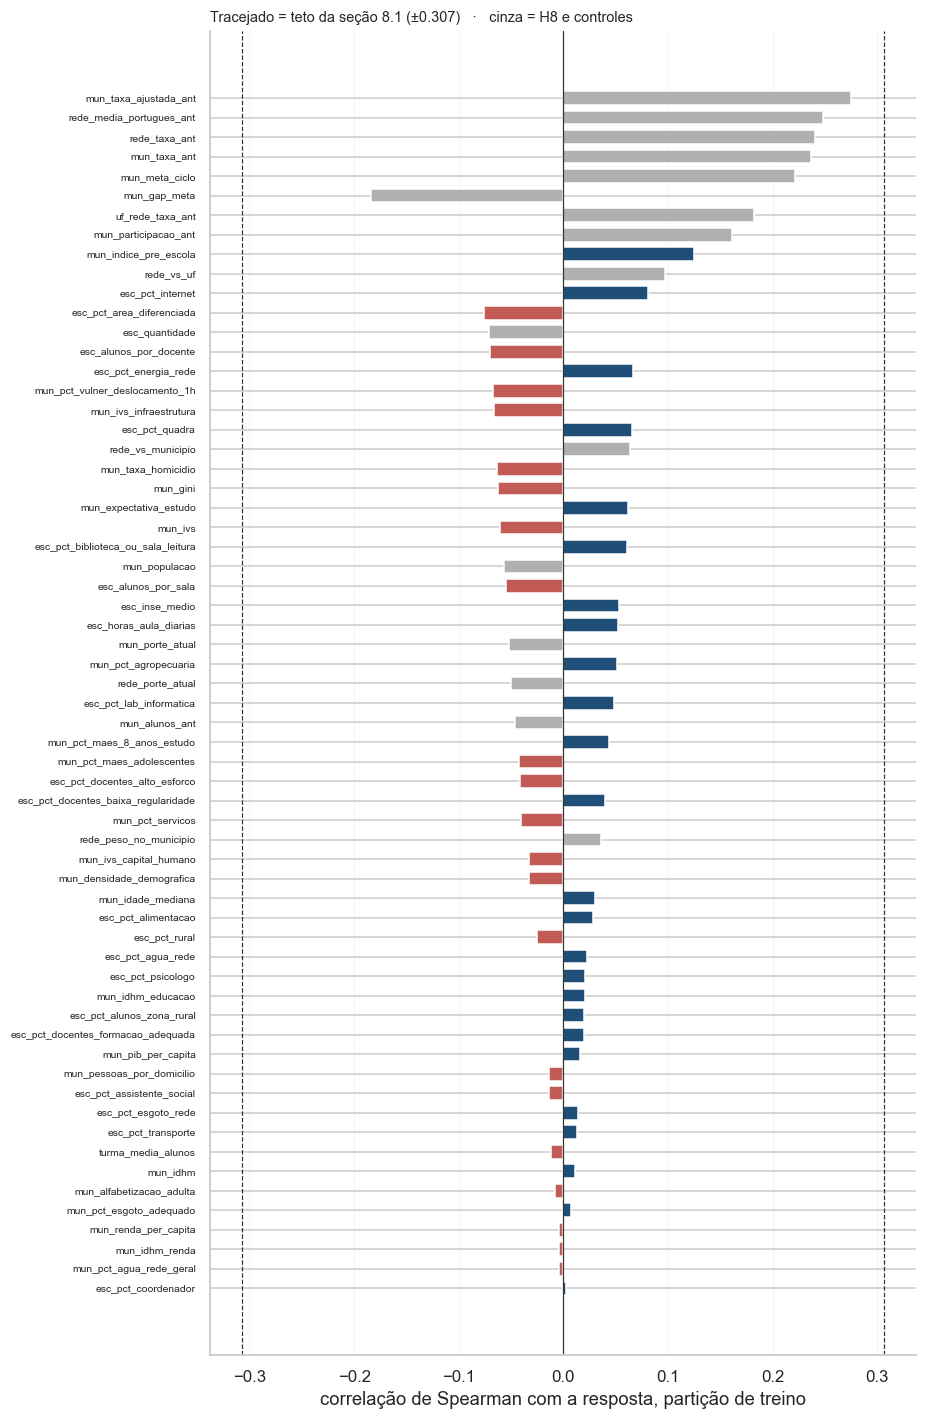

62 variáveis numéricas   ·   teto da seção 8.1: 0.307
  maior correlação absoluta                   0.275
  variáveis acima do teto                     0
  concordância com a amplitude da seção 8     0.95   (correlação entre os dois rankings)
  sentido diferente da seção 8, com gradiente 0

AS QUINZE ACIONÁVEIS MAIS CORRELACIONADAS
                                                               hipotese  pearson  spearman  pct_do_teto  amplitude_pp_q                     padrao
mun_indice_pre_escola                             H12 primeira infancia    0.120     0.125         41.0            18.9                 monotônica
esc_pct_internet                                H3 recursos pedagogicos    0.057     0.081         26.0             9.9                 monotônica
esc_pct_area_diferenciada           H13 contexto linguistico e cultural   -0.045    -0.076         25.0            -7.7                 monotônica
esc_alunos_por_docente                             H4 densidade da sala   -0.0

,hipotese,pearson,spearman,pct_do_teto,amplitude_pp_q,padrao
mun_taxa_ajustada_ant,H8 inercia territorial,0.277,0.275,90.0,38.3,monotônica
rede_media_portugues_ant,H8 inercia territorial,0.247,0.248,81.0,34.6,monotônica
rede_taxa_ant,H8 inercia territorial,0.245,0.240,78.0,34.3,monotônica
mun_taxa_ant,H8 inercia territorial,0.244,0.237,77.0,34.0,monotônica
mun_meta_ciclo,H8 inercia territorial,0.224,0.221,72.0,29.2,monotônica
mun_gap_meta,H8 inercia territorial,-0.181,-0.184,60.0,-23.5,monotônica
uf_rede_taxa_ant,H8 inercia territorial,0.190,0.182,59.0,23.1,monotônica
mun_participacao_ant,H8 inercia territorial,0.156,0.161,53.0,23.2,monotônica
mun_indice_pre_escola,H12 primeira infancia,0.120,0.125,41.0,18.9,monotônica
rede_vs_uf,H8 inercia territorial,0.104,0.097,32.0,15.3,monotônica


In [318]:
# --- 9.1 Correlação de cada variável com a resposta ---
# Pearson entre uma variável contínua e uma resposta binária é a correlação
# bisserial por pontos. A de Spearman usa os postos: capta relação monotônica
# mesmo quando ela não é linear e não é arrastada pelos valores extremos.
numericas_treino = treino[NUMERICAS].astype("float64")
postos = numericas_treino.rank()          # os postos servem também à 9.2
postos_alvo = treino["alvo"].rank()

correlacao = pd.DataFrame({
    "hipotese": [mapa_hipotese.get(v, "não declarada") for v in NUMERICAS],
    "pearson": numericas_treino.corrwith(treino["alvo"]).round(3).to_numpy(),
    "spearman": postos.corrwith(postos_alvo).round(3).to_numpy(),
}, index=NUMERICAS)
correlacao["pct_do_teto"] = (100 * correlacao["spearman"].abs() / teto).round(0)
correlacao = (correlacao.join(gradiente[["amplitude_pp_q", "padrao"]])
              .sort_values("spearman", key=abs, ascending=False))

NAO_ACIONAVEIS = ("H8", "controle")
acionavel = ~correlacao["hipotese"].str.startswith(NAO_ACIONAVEIS)

# gráfico: todas as variáveis, da mais para a menos correlacionada
ordem = correlacao.iloc[::-1]
cores = np.where(~acionavel.loc[ordem.index], "#b0b0b0",
                 np.where(ordem["spearman"] > 0, "#1f4e79", "#c25b56"))
fig, eixo = plt.subplots(figsize=(8.5, 0.19 * len(ordem) + 1.2))
eixo.barh(ordem.index, ordem["spearman"], color=cores, height=.7)
eixo.axvline(0, color="#333", lw=.8)
for x in (-teto, teto):
    eixo.axvline(x, color="#333", ls="--", lw=.8)
eixo.set_xlabel("correlação de Spearman com a resposta, partição de treino")
eixo.set_title(f"Tracejado = teto da seção 8.1 (±{teto:.3f})   ·   "
               "cinza = H8 e controles", fontsize=9.5, loc="left")
eixo.tick_params(axis="y", labelsize=6.8)
eixo.grid(axis="x", alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

# as duas medidas contam a mesma história? ordem e sentido
concordancia = correlacao["spearman"].abs().corr(
    correlacao["amplitude_pp_q"].abs(), method="spearman")
sentido_diferente = correlacao[
    (np.sign(correlacao["spearman"]) != np.sign(correlacao["amplitude_pp_q"]))
    & (correlacao["padrao"] != "sem gradiente")]

print(f"{len(correlacao)} variáveis numéricas   ·   teto da seção 8.1: {teto:.3f}")
print(f"  maior correlação absoluta                   {correlacao['spearman'].abs().max():.3f}")
print(f"  variáveis acima do teto                     {int((correlacao['spearman'].abs() > teto).sum())}")
print(f"  concordância com a amplitude da seção 8     {concordancia:.2f}"
      "   (correlação entre os dois rankings)")
print(f"  sentido diferente da seção 8, com gradiente {len(sentido_diferente)}"
      + (f": {', '.join(sentido_diferente.index)}" if len(sentido_diferente) else ""))
print()
print("AS QUINZE ACIONÁVEIS MAIS CORRELACIONADAS")
print("=" * 104)
print(correlacao[acionavel].head(15).to_string())

# O DataFrame fica disponível para inspeção e filtro no próprio notebook.
# Exemplo: correlacao.query("hipotese.str.startswith('H10')")
correlacao

**Leitura.** As duas primeiras expectativas se confirmam. A maior correlação com a resposta é de 0,275, da taxa ajustada do município em 2023 (H8), e nenhuma variável passa do teto de 0,307. A ordem das variáveis quase repete a da seção 8: a correlação entre os dois rankings é de 0,95, e nenhuma variável com gradiente troca de sentido.

Entre as variáveis acionáveis, a oferta de pré-escola lidera, com 0,125, ou 41% do teto; as demais ficam entre 0,05 e 0,08, abaixo de um quarto dele. Pearson e Spearman ficam próximos. A diferença é maior nas variáveis concentradas perto de um extremo, como internet (0,057 contra 0,081), área diferenciada (−0,045 contra −0,076) e energia (0,041 contra 0,067), em que a correlação linear subestima a relação.

📌 **Consequência para a modelagem.** A correlação confirma, por outra medida, o que a seção 8 mostrou. Correlações individuais pequenas são o esperado nesta base e não indicam variáveis inúteis: o que cada uma acrescenta é medido em conjunto, na modelagem.

### 9.2 Correlação entre as explicativas

A matriz abaixo usa a mesma medida, a correlação de Spearman, agora entre cada par de variáveis explicativas. As colunas estão ordenadas por hipótese, e as linhas finas separam os blocos: se as variáveis de uma hipótese medem o mesmo conceito, o bloco aparece como um quadrado escuro sobre a diagonal.

Um par com correlação acima de 0,8, em módulo, indica duas variáveis que dizem quase a mesma coisa. Esta seção só identifica esses pares; quantos conceitos distintos restam e qual variável de cada par fica são assuntos da seção 10.

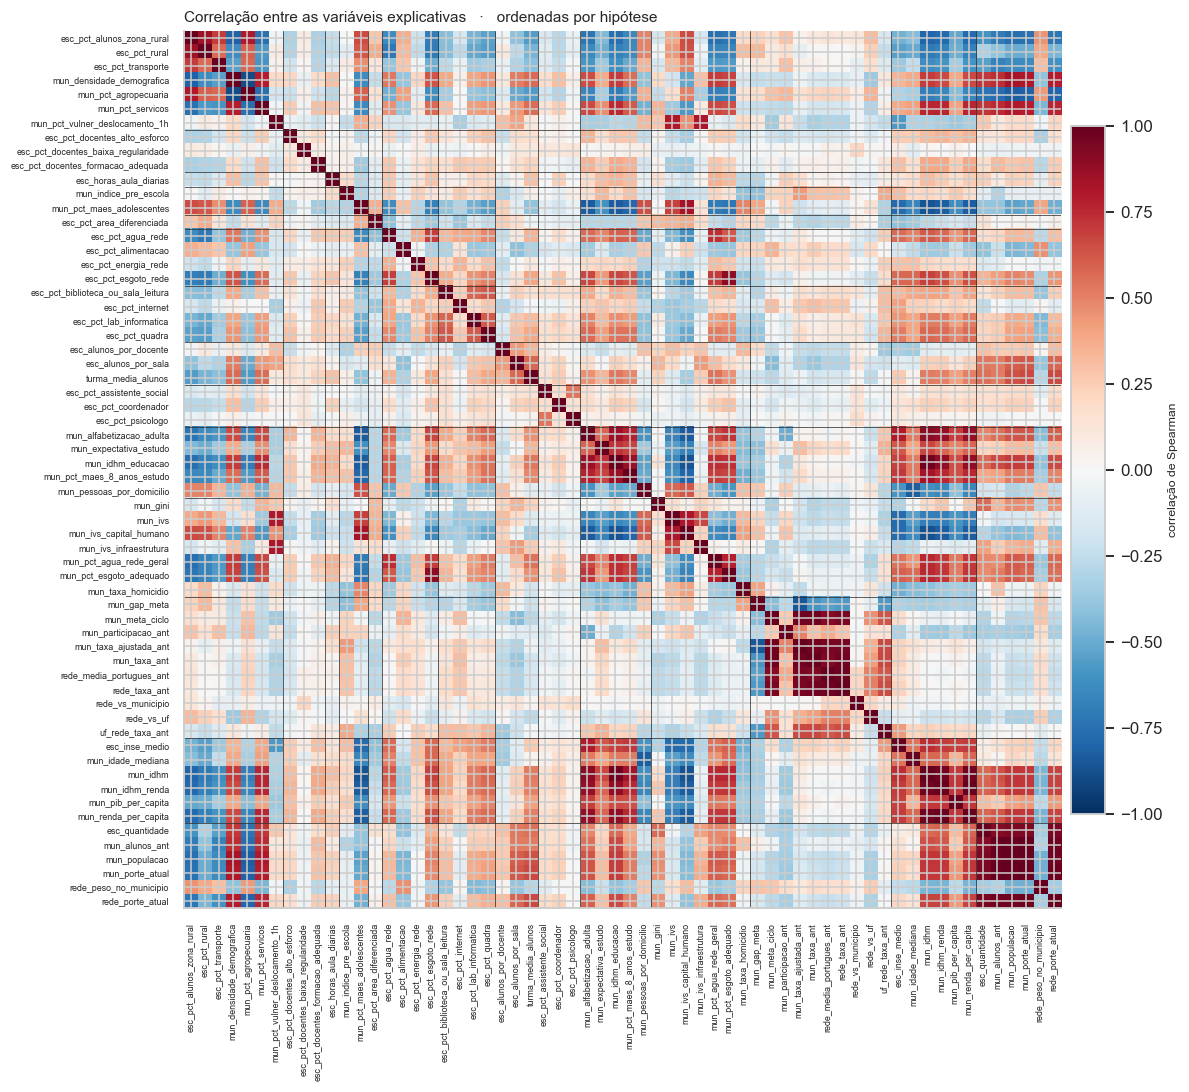

1,891 pares de variáveis numéricas
  pares com correlação acima de 0.8 em módulo     57
  pares acima de 0,9                               25
  dentro da mesma hipótese                         30
  entre hipóteses diferentes                       27
  variáveis envolvidas em algum desses pares       31 de 62

PARES ACIMA DE 0.8
                    variavel_a                 variavel_b  spearman                     hipotese_a                     hipotese_b  mesma_hipotese
                mun_idhm_renda       mun_renda_per_capita     1.000          H9 recursos materiais          H9 recursos materiais            True
                mun_alunos_ant            mun_porte_atual     0.996             controle de escala             controle de escala            True
                 mun_populacao            mun_porte_atual     0.990             controle de escala             controle de escala            True
                mun_alunos_ant              mun_populacao     0.987             contro

In [319]:
# --- 9.2 Correlação entre as variáveis explicativas ---
# Mesma medida da 9.1, no grão do aluno, sobre os postos já calculados.
# A ordem segue as hipóteses, para que os blocos apareçam na diagonal.
LIMIAR_PAR = .8
ordem_vars = sorted(NUMERICAS, key=lambda v: (mapa_hipotese.get(v, "~"), v))
matriz = postos[ordem_vars].corr()

fig, eixo = plt.subplots(figsize=(11, 10))
imagem = eixo.imshow(matriz.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
eixo.set_xticks(range(len(ordem_vars)))
eixo.set_yticks(range(len(ordem_vars)))
eixo.set_xticklabels(ordem_vars, rotation=90, fontsize=5.8)
eixo.set_yticklabels(ordem_vars, fontsize=5.8)
blocos = [mapa_hipotese.get(v, "~") for v in ordem_vars]
for i in range(1, len(blocos)):
    if blocos[i] != blocos[i - 1]:
        eixo.axhline(i - .5, color="#333", lw=.5)
        eixo.axvline(i - .5, color="#333", lw=.5)
barra = fig.colorbar(imagem, ax=eixo, fraction=.035, pad=.01)
barra.set_label("correlação de Spearman", fontsize=8)
eixo.set_title("Correlação entre as variáveis explicativas   ·   "
               "ordenadas por hipótese", fontsize=10, loc="left")
plt.tight_layout()
plt.show()

# os pares acima do limiar, cada um contado uma vez
triangulo = matriz.where(np.triu(np.ones(matriz.shape, dtype=bool), k=1))
pares = triangulo.stack().dropna().rename("spearman")
pares.index.names = ["variavel_a", "variavel_b"]
pares = pares.reset_index()
pares["hipotese_a"] = pares["variavel_a"].map(mapa_hipotese)
pares["hipotese_b"] = pares["variavel_b"].map(mapa_hipotese)
pares["mesma_hipotese"] = pares["hipotese_a"] == pares["hipotese_b"]
fortes = (pares[pares["spearman"].abs() >= LIMIAR_PAR]
          .sort_values("spearman", key=abs, ascending=False)
          .round({"spearman": 3}))

envolvidas = sorted(set(fortes["variavel_a"]) | set(fortes["variavel_b"]))
print(f"{len(pares):,} pares de variáveis numéricas")
print(f"  pares com correlação acima de {LIMIAR_PAR} em módulo   {len(fortes):>4}")
print(f"  pares acima de 0,9                             "
      f"{int((pares['spearman'].abs() >= .9).sum()):>4}")
print(f"  dentro da mesma hipótese                       "
      f"{int(fortes['mesma_hipotese'].sum()):>4}")
print(f"  entre hipóteses diferentes                     "
      f"{int((~fortes['mesma_hipotese']).sum()):>4}")
print(f"  variáveis envolvidas em algum desses pares     {len(envolvidas):>4} de {len(NUMERICAS)}")
print()
print(f"PARES ACIMA DE {LIMIAR_PAR}")
print("=" * 118)
print(fortes.to_string(index=False))

**Leitura.** Dos 1.891 pares de variáveis, 57 têm correlação acima de 0,8 em módulo, e 25 acima de 0,9. Eles envolvem 31 das 62 variáveis numéricas e se concentram em três blocos:

1. **Porte:** população, alunos avaliados em 2023 e em 2024 e número de escolas dizem praticamente a mesma coisa, com correlações entre 0,91 e 0,996.
2. **Desempenho anterior (H8):** as taxas do município e da rede, a proficiência média e a meta ficam entre 0,91 e 0,97.
3. **Condição socioeconômica do município:** IDHM e as suas dimensões, renda, alfabetização adulta, IVS de capital humano, escolaridade das mães e mães adolescentes formam um bloco só, com correlações entre 0,82 e 1,0. `mun_idhm_renda` e `mun_renda_per_capita` são, na prática, a mesma medida (1,000), porque a primeira é calculada a partir da segunda.

A terceira expectativa se confirma só em parte: 30 dos 57 pares estão dentro de uma mesma hipótese, mas 27 cruzam hipóteses, quase todos no bloco socioeconômico. No grão do município, as variáveis de H6 (capital cultural), H7 (capital humano), H9 (renda) e H12 (mães adolescentes) medem praticamente o mesmo conceito. As medidas de ruralidade da H1 também se ligam ao porte: a densidade tem correlação de −0,895 com o peso da agropecuária e de 0,822 com a população.

📌 **Consequência para a modelagem.** A comparação entre capital cultural (H6) e renda (H9), prevista em `docs/hipoteses.md`, não pode ser feita com essas variáveis, porque no município elas andam juntas. Para os modelos de árvore, pares redundantes não prejudicam a predição, mas dividem a importância entre si e distorcem o ranking da seção 11; para os modelos lineares, instabilizam os coeficientes. A seção 10 decide quantos conceitos distintos existem e qual variável representa cada bloco.

---

## 10. Multicolinearidade

**Passos desta seção:** (10.1) agrupar as variáveis que medem o mesmo conceito; (10.2) conferir, pelo fator de inflação da variância, se um representante por grupo resolve a redundância.

A seção 9 encontrou 57 pares de variáveis com correlação acima de 0,8. Esta seção responde à pergunta do roteiro: quantos conceitos distintos existem, de fato, entre as 62 variáveis numéricas.

🎓 **Conceito, multicolinearidade:** ocorre quando uma variável explicativa pode ser prevista, com pouca margem de erro, a partir das outras. Nos modelos lineares, os coeficientes ficam instáveis: pequenas mudanças nos dados trocam o peso de uma variável para a outra, e o sinal de cada uma perde interpretação. Nos modelos de árvore, a predição não piora, mas a importância se reparte entre as variáveis redundantes, e o ranking deixa de mostrar qual conceito importa.

**O que se espera, declarado antes da medição:** os três blocos da 9.2 (porte, desempenho anterior e condição socioeconômica do município) formam um grupo cada, e a maior parte das variáveis de escola fica isolada.

### 10.1 Grupos de variáveis que medem o mesmo conceito

A regra de agrupamento usa o limiar da 9.2, com uma exigência: um grupo só se forma se **todas** as correlações entre os seus membros passarem de 0,8 em módulo. Sem essa exigência, variáveis ligadas duas a duas formariam cadeias, em que A se parece com B, B se parece com C, mas A e C têm pouco em comum. A tabela traz, para cada grupo, a menor correlação entre os seus membros.

Em cada grupo, a variável proposta como **representante** é a mais correlacionada com a resposta (9.1). A proposta é o ponto de partida da seção 12, que pode preferir outra variável do grupo por ser mais fácil de interpretar ou de transformar em ação.

In [320]:
# --- 10.1 Grupos de variáveis que medem o mesmo conceito ---
import textwrap

# Dois grupos só se unem se TODAS as correlações entre os seus membros
# passarem de LIMIAR_PAR (0,8, o mesmo da 9.2). A cada passo, une o par de
# grupos cuja menor correlação é a mais alta; para quando nenhum par passa
# do limiar. Assim nenhum grupo vira uma cadeia de variáveis ligadas só
# duas a duas.
nomes = list(matriz.index)
absoluta = matriz.abs().fillna(0).to_numpy()
indices = [[k] for k in range(len(nomes))]
while True:
    melhor, par = LIMIAR_PAR, None
    for i in range(len(indices)):
        for j in range(i + 1, len(indices)):
            menor = absoluta[np.ix_(indices[i], indices[j])].min()
            if menor >= melhor:
                melhor, par = menor, (i, j)
    if par is None:
        break
    i, j = par
    indices[i] += indices.pop(j)

# o primeiro de cada grupo é o representante: o mais correlacionado com a resposta
grupos = [sorted((nomes[k] for k in g), key=lambda x: -abs(correlacao.loc[x, "spearman"]))
          for g in indices]

representantes = [g[0] for g in grupos]
redundantes = sorted([g for g in grupos if len(g) > 1], key=len, reverse=True)

linhas = []
for n, membros in enumerate(redundantes, 1):
    interna = matriz.loc[membros, membros].abs().to_numpy()
    linhas.append({
        "grupo": n,
        "variaveis": len(membros),
        "representante": membros[0],
        "correlacao_com_resposta": correlacao.loc[membros[0], "spearman"],
        "menor_correlacao_interna": round(float(
            interna[np.triu_indices(len(membros), k=1)].min()), 2),
        "hipoteses": ", ".join(sorted({mapa_hipotese[m].split()[0] for m in membros})),
        "demais": ", ".join(membros[1:]),
    })
grupos_redundantes = pd.DataFrame(linhas).set_index("grupo")

em_grupo = sum(len(g) for g in redundantes)
print(f"{len(ordem_vars)} variáveis numéricas  ->  {len(grupos)} conceitos distintos")
print(f"  variáveis isoladas, sem par acima de {LIMIAR_PAR}       {len(grupos) - len(redundantes):>3}")
print(f"  variáveis reunidas em grupos                     {em_grupo:>3}"
      f"  (em {len(redundantes)} grupos)")
print()
for n, r in grupos_redundantes.iterrows():
    print(f"GRUPO {n}  ·  {r['variaveis']} variáveis  ·  hipóteses {r['hipoteses']}"
          f"  ·  menor correlação interna {r['menor_correlacao_interna']:.2f}")
    print(f"   representante  {r['representante']}"
          f"  (correlação com a resposta {r['correlacao_com_resposta']:+.3f})")
    print(textwrap.fill(r["demais"], width=100, initial_indent="   demais         ",
                        subsequent_indent=" " * 18))
    print()

grupos_redundantes

62 variáveis numéricas  ->  43 conceitos distintos
  variáveis isoladas, sem par acima de 0.8        35
  variáveis reunidas em grupos                      27  (em 8 grupos)

GRUPO 1  ·  7 variáveis  ·  hipóteses H12, H6, H7, H9  ·  menor correlação interna 0.83
   representante  mun_pct_maes_adolescentes  (correlação com a resposta -0.042)
   demais         mun_ivs_capital_humano, mun_idhm_educacao, mun_idhm, mun_alfabetizacao_adulta,
                  mun_idhm_renda, mun_renda_per_capita

GRUPO 2  ·  5 variáveis  ·  hipóteses H8  ·  menor correlação interna 0.91
   representante  mun_taxa_ajustada_ant  (correlação com a resposta +0.275)
   demais         rede_media_portugues_ant, rede_taxa_ant, mun_taxa_ant, mun_meta_ciclo

GRUPO 3  ·  5 variáveis  ·  hipóteses controle  ·  menor correlação interna 0.91
   representante  esc_quantidade  (correlação com a resposta -0.071)
   demais         mun_populacao, mun_porte_atual, rede_porte_atual, mun_alunos_ant

GRUPO 4  ·  2 variáveis  ·  hi

,variaveis,representante,correlacao_com_resposta,menor_correlacao_interna,hipoteses,demais
grupo,,,,,,
1,7,mun_pct_maes_adolescentes,-0.042,0.83,"H12, H6, H7, H9","mun_ivs_capital_humano, mun_idhm_educacao, mun..."
2,5,mun_taxa_ajustada_ant,0.275,0.91,H8,"rede_media_portugues_ant, rede_taxa_ant, mun_t..."
3,5,esc_quantidade,-0.071,0.91,controle,"mun_populacao, mun_porte_atual, rede_porte_atu..."
4,2,esc_pct_rural,-0.025,0.84,H1,esc_pct_alunos_zona_rural
5,2,mun_pct_agropecuaria,0.051,0.90,H1,mun_densidade_demografica
6,2,mun_pct_vulner_deslocamento_1h,-0.067,0.81,"H1, H7",mun_ivs_infraestrutura
7,2,esc_pct_esgoto_rede,0.014,0.90,"H2, H7",mun_pct_esgoto_adequado
8,2,mun_idade_mediana,0.030,0.82,"H6, H9",mun_pessoas_por_domicilio


**Leitura.** As 62 variáveis numéricas se reduzem a 43 conceitos distintos: 35 variáveis não têm par acima de 0,8, e as outras 27 formam 8 grupos, todos coesos, com correlação interna mínima entre 0,81 e 0,91. A expectativa se confirma:

- **Condição socioeconômica do município** (grupo 1, 7 variáveis): IDHM e as suas dimensões, renda, alfabetização adulta, IVS de capital humano e mães adolescentes. Reúne variáveis de H6, H7, H9 e H12, que no município medem o mesmo conceito.
- **Desempenho anterior** (grupo 2, 5 variáveis): as taxas do município e da rede, a proficiência média e a meta.
- **Porte** (grupo 3, 5 variáveis): população, alunos avaliados em 2023 e em 2024 e número de escolas.

As variáveis de escola ficam, em geral, isoladas. Os grupos restantes são pares: escola rural e residência rural (H1), agropecuária e densidade (H1), deslocamento até o trabalho e IVS de infraestrutura, do qual ele é componente, esgoto das escolas e esgoto dos domicílios, e idade mediana e pessoas por domicílio.

📌 **Os representantes são uma proposta.** O critério foi a maior correlação com a resposta, e em alguns grupos outra variável pode servir melhor ao trabalho. No porte, a população é mais fácil de interpretar que o número de escolas; no par agropecuária e densidade, a densidade é a medida direta do conceito da H1. A escolha final é feita na seção 12.

### 10.2 Fator de inflação da variância

🎓 **Conceito, fator de inflação da variância (VIF):** mede o quanto uma variável pode ser prevista pelas demais. Ele vale 1/(1 − R²), em que R² é a fração da variação da variável explicada por todas as outras juntas. VIF igual a 1 indica nenhuma redundância; acima de 10, limiar convencional, as outras explicam mais de 90% da variável. Ao contrário da correlação da 9.2, que olha um par de cada vez, o VIF considera todas as variáveis ao mesmo tempo, e por isso pega também a redundância que só aparece na combinação de várias.

O VIF é calculado a partir da matriz de correlação da 9.2, pela diagonal da sua inversa, em dois conjuntos: as 62 variáveis numéricas e o conjunto que fica com um representante por grupo.

In [321]:
# --- 10.2 Fator de inflação da variância, antes e depois dos representantes ---
# O VIF de cada variável é o elemento da diagonal da inversa da matriz de
# correlação (aqui, a de postos da 9.2). Com variáveis quase idênticas a
# matriz fica perto de singular, e o VIF cresce sem limite.
LIMIAR_VIF = 10


def calcular_vif(colunas: list) -> pd.Series:
    r = matriz.loc[colunas, colunas].to_numpy()
    return pd.Series(np.diag(np.linalg.inv(r)), index=colunas)


vif_todas = calcular_vif(ordem_vars)
vif_repr = calcular_vif(representantes)

resumo_vif = pd.DataFrame({
    "variaveis": [len(vif_todas), len(vif_repr)],
    "vif_acima_de_10": [int((vif_todas > LIMIAR_VIF).sum()),
                        int((vif_repr > LIMIAR_VIF).sum())],
    "vif_mediano": [round(vif_todas.median(), 1), round(vif_repr.median(), 1)],
    "vif_maximo": [round(vif_todas.max(), 1), round(vif_repr.max(), 1)],
}, index=["todas as variáveis", "um representante por grupo"])

print("FATOR DE INFLAÇÃO DA VARIÂNCIA")
print("=" * 78)
print(resumo_vif.to_string())
print()
print("AS DEZ MAIORES, COM TODAS AS VARIÁVEIS")
print(vif_todas.sort_values(ascending=False).head(10).round(1).to_string())
print()
restantes = vif_repr[vif_repr > LIMIAR_VIF].sort_values(ascending=False)
print(f"REPRESENTANTES AINDA ACIMA DE {LIMIAR_VIF}: {len(restantes)}")
if len(restantes):
    print(restantes.round(1).to_frame("vif")
          .assign(hipotese=lambda d: d.index.map(mapa_hipotese)).to_string())

FATOR DE INFLAÇÃO DA VARIÂNCIA
                            variaveis  vif_acima_de_10  vif_mediano  vif_maximo
todas as variáveis                 62               19          4.9     31727.7
um representante por grupo         43                0          2.4         7.7

AS DEZ MAIORES, COM TODAS AS VARIÁVEIS
mun_renda_per_capita    31727.7
mun_idhm_renda          31692.9
mun_porte_atual           152.3
mun_idhm                  138.3
mun_populacao             119.8
rede_taxa_ant              82.9
rede_porte_atual           60.1
mun_taxa_ant               54.7
mun_idhm_educacao          45.6
esc_quantidade             27.4

REPRESENTANTES AINDA ACIMA DE 10: 0


**Leitura.** Com as 62 variáveis, 19 têm VIF acima de 10. Os valores mais altos são os de renda per capita e IDHM renda (cerca de 31.700), que são, na prática, a mesma medida, seguidos das variáveis de porte, do IDHM e das taxas do desempenho anterior. Com um representante por grupo, nenhuma das 43 variáveis passa de 10: o maior VIF é 7,7 e o mediano, 2,4.

📌 **Consequência para a modelagem.** Um representante por grupo é suficiente para eliminar a multicolinearidade. O conjunto de 43 conceitos é o ponto de partida da seção 11, para que a importância de cada conceito não se reparta entre variáveis redundantes, e da seção 12, que decide o que entra no modelo.

---

## 11. Variáveis relevantes

**Passos desta seção:** (11.1) o ranking dos 43 conceitos; (11.2) o resultado por hipótese.

Esta seção não traz medida nova. Ela organiza o que as seções 8 a 10 mediram, agora sobre os 43 conceitos da seção 10, e não sobre as 62 variáveis. A diferença importa: com variáveis redundantes, um mesmo conceito aparece várias vezes no ranking, e conceitos com poucas variáveis parecem menos relevantes do que são.

O critério de ordenação é a correlação de Spearman com a resposta (9.1), lida como fração do teto de 0,307 (8.1). Ao lado ficam a amplitude e a forma da relação (seção 8) e o número de variáveis que cada conceito representa.

### 11.1 Ranking dos conceitos

Cada linha é um conceito, identificado pela variável que o representa. Na coluna `hipoteses_do_grupo` estão todas as hipóteses a que pertencem as variáveis do grupo: o conceito de condição socioeconômica do município, por exemplo, reúne variáveis de H6, H7, H9 e H12. O gráfico mostra os 43 conceitos. Os da H8 e os controles aparecem em cinza: entram no modelo, mas não respondem à pergunta sobre o que um gestor pode mudar.

In [ ]:
# --- 11.1 Ranking dos 43 conceitos ---
membros_do_grupo = {g[0]: g for g in grupos}

ranking = pd.DataFrame({
    "hipotese": [mapa_hipotese[v] for v in representantes],
    "representa": [len(membros_do_grupo[v]) for v in representantes],
    "hipoteses_do_grupo": [", ".join(sorted({mapa_hipotese[m].split()[0]
                                             for m in membros_do_grupo[v]}))
                           for v in representantes],
}, index=representantes)
ranking = (ranking.join(correlacao[["spearman", "pct_do_teto", "amplitude_pp_q", "padrao"]])
           .sort_values("spearman", key=abs, ascending=False))
ranking.insert(0, "posicao", range(1, len(ranking) + 1))
acionavel_conceito = ~ranking["hipotese"].str.startswith(NAO_ACIONAVEIS)

# gráfico: os 43 conceitos, em fração do teto; H8 e controles em cinza
ordem = ranking.iloc[::-1]
rotulos = [f"{v}  (+{n - 1})" if n > 1 else v
           for v, n in zip(ordem.index, ordem["representa"])]
cores = np.where(~acionavel_conceito.loc[ordem.index], "#b0b0b0",
                 np.where(ordem["spearman"] > 0, "#1f4e79", "#c25b56"))
fig, eixo = plt.subplots(figsize=(8.5, 0.22 * len(ordem) + 1.2))
eixo.barh(rotulos, ordem["pct_do_teto"], color=cores, height=.7)
for i, valor in enumerate(ordem["pct_do_teto"]):
    eixo.text(valor + .6, i, f"{valor:.0f}%", va="center", fontsize=7, color="#555")
eixo.set_xlim(0, ordem["pct_do_teto"].max() + 8)
eixo.set_xlabel("correlação com a resposta, em % do teto da seção 8.1")
eixo.set_title("Os 43 conceitos   ·   azul = relação positiva, vermelho = negativa, "
               "cinza = H8 e controles\n"
               "(+n) = variáveis redundantes que o conceito representa",
               fontsize=9, loc="left")
eixo.tick_params(axis="y", labelsize=7)
eixo.grid(axis="x", alpha=.22, lw=.6)
plt.tight_layout()
plt.show()

print(f"{len(ranking)} conceitos   ·   {int(acionavel_conceito.sum())} acionáveis   ·   "
      f"{int((~acionavel_conceito).sum())} da H8 e de controle")
print()
print("OS DEZ CONCEITOS ACIONÁVEIS MAIS CORRELACIONADOS")
print("=" * 118)
print(ranking[acionavel_conceito].head(10).to_string())

# O DataFrame completo fica disponível para inspeção no próprio notebook.
ranking

**Leitura.** Os quatro primeiros lugares são da H8: a taxa ajustada do município em 2023 (90% do teto), a distância até a meta (60%), a mediana da rede no estado (59%) e a participação em 2023 (53%). O primeiro conceito acionável, em quinto lugar, é a oferta de pré-escola, com 41% do teto; nenhum outro acionável passa de 26%.

Depois dela vem um bloco de onze conceitos próximos entre si, entre 20% e 26% do teto: internet, área diferenciada, alunos por professor, deslocamento até o trabalho, energia, quadra, homicídio, Gini, expectativa de estudo, IVS e biblioteca ou sala de leitura. Dentro desse bloco, a ordem não é confiável: as correlações vão de 0,061 a 0,081, e com cerca de 3.300 municípios no treino o erro de cada uma é da ordem de 0,02.

O conceito de condição socioeconômica do município, que reúne sete variáveis, fica em 26º lugar, com 14% do teto.

### 11.2 Resultado por hipótese

A tabela abaixo resume, para cada hipótese, quantos conceitos a representam, qual deles está mais correlacionado com a resposta e quantos têm relação monotônica ou nenhum gradiente. Um conceito que reúne variáveis de várias hipóteses conta para todas elas.

In [ ]:
# --- 11.2 Resultado por hipótese, sobre os conceitos ---
nome_hipotese = {h.split()[0]: h for h in mapa_hipotese.values()}
por_hipotese = (ranking[acionavel_conceito]
                .assign(h=lambda d: d["hipoteses_do_grupo"].str.split(", "))
                .explode("h"))
por_hipotese = por_hipotese[~por_hipotese["h"].str.startswith(NAO_ACIONAVEIS)]

linhas = []
for h, d in por_hipotese.groupby("h"):
    melhor = d["spearman"].abs().idxmax()
    linhas.append({
        "hipotese": nome_hipotese[h],
        "conceitos": len(d),
        "melhor_conceito": melhor,
        "spearman": d.loc[melhor, "spearman"],
        "pct_do_teto": d.loc[melhor, "pct_do_teto"],
        "monotonicos": int((d["padrao"] == "monotônica").sum()),
        "sem_gradiente": int((d["padrao"] == "sem gradiente").sum()),
    })
resultado_hipoteses = (pd.DataFrame(linhas).set_index("hipotese")
                       .sort_values("pct_do_teto", ascending=False))

h8 = ranking[ranking["hipotese"].str.startswith("H8")]
print("RESULTADO POR HIPÓTESE, SOBRE OS CONCEITOS ACIONÁVEIS")
print("=" * 118)
print(resultado_hipoteses.to_string())
print()
print(f"Referência, fora desta tabela por não ser acionável, mas no conjunto de variáveis:")
print(f"  H8, com {len(h8)} conceitos; o melhor, {h8.index[0]}, "
      f"tem {h8['pct_do_teto'].iloc[0]:.0f}% do teto.")

**Leitura.** Sobre os conceitos, a H12 (primeira infância) lidera, com 41% do teto, puxada pela pré-escola. Em seguida vem um bloco de oito hipóteses com o melhor conceito entre 20% e 26% do teto (H3, H13, H4, H7, H2, H1 e H6), depois H9 e H11 (17%), H10 (13%) e, por último, H5 (7%), sem conceito monotônico e com dois sem gradiente.

Dois resultados pedem cuidado na leitura. H1 e H7 têm o mesmo melhor conceito, o deslocamento até o trabalho, porque ele forma um grupo com o IVS de infraestrutura, e as duas hipóteses dividem a mesma evidência. E o melhor conceito da H2 é a energia elétrica, que está perto de 100% em quase todas as redes (seção 5): o gradiente vem das poucas redes abaixo desse patamar.

📌 **Consequência para a modelagem.** A H5 (suporte especializado) é a única hipótese sem evidência de relação com a resposta, e é a candidata clara a ficar de fora. As demais seguem para a seção 12 com os seus conceitos. O ranking é bivariado: o que cada conceito acrescenta ao desempenho anterior (H8) é medido na modelagem.

---

## 12. Síntese e decisões

**Passos desta seção:** (12.1) o conjunto de variáveis que segue para a modelagem; (12.2) o tratamento de cada variável; (12.3) a lista gravada para a etapa seguinte.

Esta seção transforma os achados das seções anteriores em decisões. Cada decisão remete à evidência que a sustenta, e todas são registradas no [diário de decisões](../docs/decisoes.md).

### 12.1 O conjunto de variáveis

**Uma lista, lida de duas formas.** O conjunto que segue para a modelagem inclui todas as hipóteses com evidência de relação com a resposta, inclusive a H8 e os controles. A H8 é uma defasagem da própria resposta: entra como o preditor mais forte e como referência, porque a modelagem mede o quanto as demais variáveis acrescentam a ela. A separação entre a H8 e as variáveis acionáveis, usada nas seções 8.4 e 11, serve para interpretar o resultado, e não para escolher variáveis.

As regras:

1. **Um representante por grupo de variáveis redundantes (seção 10).** Em três grupos, o representante proposto na 10.1, que era o mais correlacionado com a resposta, é trocado por outra variável do mesmo grupo:

| Grupo | Proposto na 10.1 | Escolhido | Motivo |
|---|---|---|---|
| desempenho anterior | `mun_taxa_ajustada_ant` | `rede_taxa_ant` | a taxa ajustada falta para 23,1% dos alunos, e a da rede, para 1,9%; e a da rede distingue a rede estadual da municipal no mesmo município (D-003) |
| porte | `esc_quantidade` | `mun_populacao` | é mais fácil de interpretar, com correlação próxima |
| agropecuária e densidade | `mun_pct_agropecuaria` | `mun_densidade_demografica` | é a medida direta do conceito da H1 |

2. **Sai a H5 (suporte especializado):** psicólogo, coordenador pedagógico e assistente social. É a única hipótese sem evidência de relação com a resposta (11.2). Os conceitos sem gradiente de outras hipóteses permanecem: a análise é bivariada, e o que eles acrescentam em combinação com os demais é medido na modelagem.
3. **As três categóricas ficam.** A região é redundante com a UF, mas é a única informação territorial para o Distrito Federal, que não aparece na partição de treino (seção 3.3).

### 12.2 O tratamento de cada variável

| Tema | Decisão | Evidência |
|---|---|---|
| **Ausências** | imputação pela mediana da UF, ajustada só no treino e aplicada às demais partições dentro do pipeline; nas variáveis de desempenho anterior, um indicador de ausência por bloco: rede sem histórico, município sem indicador oficial, município sem microdados e município sem meta | 7.4 e 7.5: as ausências vêm em blocos de origem conhecida, e a UF está completa |
| **Escala e cauda longa** | nos modelos lineares, transformação logarítmica nas variáveis com assimetria positiva acima de 2 e, em seguida, padronização de todas as variáveis numéricas; nos modelos de árvore, nenhuma das duas | 7.1; a padronização iguala as escalas, mas não corrige a assimetria, e os modelos de árvore usam apenas a ordem dos valores |
| **Codificação** | one-hot para rede, UF e região; a UF não vista no treino recebe zero em todas as colunas de UF, e a região supre a informação | 6 |
| **Rede privada** | os 24 alunos ficam fora da modelagem: não têm contexto de rede no ciclo anterior e não sustentam estimativa (D-003); o modelo prevê para as redes públicas, que são o objeto da avaliação | 6.3 |
| **Rio Grande do Sul** | mantido, sem indicador próprio, porque a UF já identifica o estado; o desempenho do modelo no RS é examinado à parte na etapa de avaliação | 4.2 |
| **Peso amostral** | decidido na etapa de modelagem, como previsto no diário de decisões | desenv_01, 2.2 |

### 12.3 A lista para a modelagem

A célula abaixo aplica as regras, confere que toda variável da base recebeu uma decisão e grava a lista em `reports/variaveis_modelagem.csv`, que a etapa de modelagem lê. O arquivo traz, para cada variável, se ela entra ou sai, o motivo e os tratamentos que recebe.

In [324]:
# --- 12.3 Aplicar as regras e gravar a lista para a modelagem ---
# Representante escolhido, quando difere do proposto na 10.1 (ver 12.1)
TROCAS = {"mun_taxa_ajustada_ant": "rede_taxa_ant",
          "esc_quantidade": "mun_populacao",
          "mun_pct_agropecuaria": "mun_densidade_demografica"}
HIPOTESE_FORA = "H5"
ASSIMETRIA_LOG = 2
# indicador de ausência: nome do indicador -> variável cuja ausência define o bloco
INDICADORES = {"sem_rede_ant": "rede_taxa_ant",
               "sem_municipio_ant": "rede_vs_municipio",
               "sem_microdados_ant": "mun_participacao_ant",
               "sem_meta": "mun_gap_meta"}
MOTIVO_CATEGORICA = {
    "rede_nome": "a rede privada (24 alunos) fica fora da modelagem",
    "sigla_uf": "a UF não vista no treino recebe zero em todas as colunas",
    "nome_regiao": "redundante com a UF, mas informa a região da UF não vista no treino"}

# Travas: as trocas partem de representantes da 10.1 e ficam no mesmo grupo
nao_propostos = [p for p in TROCAS if p not in representantes]
if nao_propostos:
    raise RuntimeError(f"Trocas sobre variáveis que não são representantes: {nao_propostos}")
representante_de = {}
for g in grupos:
    escolhido = TROCAS.get(g[0], g[0])
    if escolhido not in g:
        raise RuntimeError(f"{escolhido} não pertence ao grupo de {g[0]}")
    for v in g:
        representante_de[v] = escolhido

linhas = []
for v in NUMERICAS:
    hipotese = mapa_hipotese[v]
    rep = representante_de[v]
    outros = [m for m, r in representante_de.items() if r == rep and m != v]
    if v != rep:
        situacao, motivo = "sai", f"redundante, representada por {rep} (10.1)"
    elif hipotese.startswith(HIPOTESE_FORA):
        situacao, motivo = "sai", "hipótese sem evidência de relação com a resposta (11.2)"
    else:
        situacao = "entra"
        motivo = (f"representa também {', '.join(outros)}" if outros
                  else "sem variável redundante")
    entra = situacao == "entra"
    linhas.append({
        "variavel": v, "hipotese": hipotese, "tipo": "numérica",
        "situacao": situacao, "motivo": motivo,
        "imputacao": "mediana da UF" if entra and treino[v].isna().any() else "",
        "indicador_ausencia": (next((n for n, x in INDICADORES.items() if x == v), "")
                               if entra else ""),
        "transformacao": ("logarítmica, só em modelo linear"
                          if entra and forma.loc[v, "assimetria"] > ASSIMETRIA_LOG
                          and treino[v].min() >= 0 else ""),
        "codificacao": "",
    })
for v in CATEGORICAS:
    linhas.append({
        "variavel": v, "hipotese": mapa_hipotese[v], "tipo": "categórica",
        "situacao": "entra", "motivo": MOTIVO_CATEGORICA[v], "imputacao": "",
        "indicador_ausencia": "", "transformacao": "", "codificacao": "one-hot"})
lista = pd.DataFrame(linhas).set_index("variavel")

# Travas: toda variável recebeu uma decisão, e os indicadores dependem de variáveis que ficam
if sorted(lista.index) != sorted(FEATURES):
    raise RuntimeError("Há variáveis da base sem decisão, ou decisões sem variável.")
orfaos = [n for n, v in INDICADORES.items() if lista.loc[v, "situacao"] != "entra"]
if orfaos:
    raise RuntimeError(f"Indicadores de ausência sobre variáveis que saíram: {orfaos}")

entram = lista[lista["situacao"] == "entra"]
redundantes_fora = (lista["situacao"] == "sai") & lista["motivo"].str.startswith("redundante")
print(f"{len(FEATURES)} variáveis explicativas na base")
print(f"  entram na modelagem              {len(entram):>3}  "
      f"({int((entram['tipo'] == 'numérica').sum())} numéricas, "
      f"{int((entram['tipo'] == 'categórica').sum())} categóricas)")
print(f"  mais indicadores de ausência     {len(INDICADORES):>3}")
print(f"  saem por redundância             {int(redundantes_fora.sum()):>3}")
print(f"  saem com a H5                    "
      f"{int(((lista['situacao'] == 'sai') & ~redundantes_fora).sum()):>3}")
print()
print("TROCAS DE REPRESENTANTE (partição de treino)")
for proposto, escolhido in TROCAS.items():
    print(f"  {proposto:<24} correlação {correlacao.loc[proposto, 'spearman']:+.3f}"
          f"   ausente {100 * treino[proposto].isna().mean():4.1f}%"
          f"   ->   {escolhido:<26} correlação {correlacao.loc[escolhido, 'spearman']:+.3f}"
          f"   ausente {100 * treino[escolhido].isna().mean():4.1f}%")
print()
print("TRATAMENTOS")
print(f"  imputação pela mediana da UF   "
      f"{int((entram['imputacao'] != '').sum())} variáveis")
print(f"  transformação logarítmica      "
      f"{', '.join(entram.index[entram['transformacao'] != ''])}")
print(f"  indicadores de ausência        {', '.join(INDICADORES)}")

lista.to_csv("../reports/variaveis_modelagem.csv", encoding="utf-8")
print()
print("Lista gravada em reports/variaveis_modelagem.csv")

entram

65 variáveis explicativas na base
  entram na modelagem               43  (40 numéricas, 3 categóricas)
  mais indicadores de ausência       4
  saem por redundância              19
  saem com a H5                      3

TROCAS DE REPRESENTANTE (partição de treino)
  mun_taxa_ajustada_ant    correlação +0.275   ausente 23.8%   ->   rede_taxa_ant              correlação +0.240   ausente  0.9%
  esc_quantidade           correlação -0.071   ausente  0.0%   ->   mun_populacao              correlação -0.057   ausente  0.0%
  mun_pct_agropecuaria     correlação +0.051   ausente  0.0%   ->   mun_densidade_demografica  correlação -0.033   ausente  0.0%

TRATAMENTOS
  imputação pela mediana da UF   18 variáveis
  transformação logarítmica      esc_pct_area_diferenciada, mun_pib_per_capita, mun_populacao, mun_densidade_demografica, mun_pct_vulner_deslocamento_1h
  indicadores de ausência        sem_rede_ant, sem_municipio_ant, sem_microdados_ant, sem_meta

Lista gravada em reports/variaveis_mod

,hipotese,tipo,situacao,motivo,imputacao,indicador_ausencia,transformacao,codificacao
variavel,,,,,,,,
rede_taxa_ant,H8 inercia territorial,numérica,entra,"representa também mun_taxa_ajustada_ant, rede_...",mediana da UF,sem_rede_ant,,
uf_rede_taxa_ant,H8 inercia territorial,numérica,entra,sem variável redundante,mediana da UF,,,
rede_vs_uf,H8 inercia territorial,numérica,entra,sem variável redundante,mediana da UF,,,
rede_vs_municipio,H8 inercia territorial,numérica,entra,sem variável redundante,mediana da UF,sem_municipio_ant,,
mun_participacao_ant,H8 inercia territorial,numérica,entra,sem variável redundante,mediana da UF,sem_microdados_ant,,
mun_gap_meta,H8 inercia territorial,numérica,entra,sem variável redundante,mediana da UF,sem_meta,,
rede_peso_no_municipio,controle de escala,numérica,entra,sem variável redundante,,,,
esc_alunos_por_sala,H4 densidade da sala,numérica,entra,sem variável redundante,,,,
turma_media_alunos,H4 densidade da sala,numérica,entra,sem variável redundante,mediana da UF,,,


**Leitura.** Das 65 variáveis explicativas, 43 seguem para a modelagem (40 numéricas e 3 categóricas), acompanhadas de 4 indicadores de ausência. Saem 22: 19 por redundância e as 3 da H5.

As três trocas de representante têm custos diferentes:

- **Desempenho anterior:** a taxa da rede tem correlação um pouco menor que a taxa ajustada (0,240 contra 0,275), mas falta para 0,9% dos alunos do treino, contra 23,8%. Com a taxa ajustada, quase um quarto dos alunos teria o preditor mais forte da base substituído por uma estimativa.
- **Porte:** a população perde pouco em relação ao número de escolas (−0,057 contra −0,071).
- **Densidade:** é a troca de maior custo, porque a correlação cai de 0,051 para −0,033, em módulo. O sinal muda porque densidade e agropecuária andam em sentidos opostos. A densidade fica pela interpretação direta da H1; se a modelagem mostrar perda, a troca pode ser revista.

Quanto aos tratamentos, 18 variáveis recebem imputação pela mediana da UF, e 5 recebem transformação logarítmica caso o algoritmo seja linear: área diferenciada, PIB per capita, população, densidade e deslocamento até o trabalho.

📌 **Consequência para a modelagem.** A etapa seguinte parte da lista gravada em `reports/variaveis_modelagem.csv`. Ficam para ela as decisões que esta análise não toma: o algoritmo, o uso do peso amostral e a métrica principal.

---

## Principais achados e questões em aberto

Esta seção reúne o que a análise mostrou, para consulta rápida. Cada item remete à seção em que está a evidência, e o conjunto ampara o README do projeto.

### Mensagens principais

1. **O modelo tem um teto baixo, e ele é estrutural.** Todas as variáveis explicativas estão no grão da rede ou do município. A diferença entre municípios responde por 9,4% da variação do resultado individual; os outros 90,6% acontecem entre alunos do mesmo município e ficam fora do alcance desta base (8.1). O modelo tende a estimar bem o risco de territórios e redes, e mal o de um aluno específico.
2. **A fronteira da classificação é estreita.** 59,8% dos alunos da base foram alfabetizados, e o corte de 743 pontos cai sobre a região mais densa das notas: 32,4% dos alunos estão a menos de 20 pontos dele (2.1 e 2.2). A acurácia não serve como métrica principal, e o modelo deve ser lido pela probabilidade.
3. **O território pesa, e a média esconde os casos.** Entre os estados, a taxa vai de 36,0% na Bahia a 85,3% no Ceará (3.3). As cidades grandes puxam o resultado para baixo: no Sudeste, 62,3% dos alunos são alfabetizados, contra 70,5% na média dos municípios, e a capital paulista, com 94 mil alunos, alfabetiza 56,6%, menos que 7 em cada 10 municípios do estado (3.1 e 3.4).
4. **O resultado anterior é o preditor mais forte.** A correlação entre as taxas municipais de 2023 e 2024 é de 0,665 (4.2), e a taxa do município em 2023 alcança 90% do teto de associação possível (11.1). O Rio Grande do Sul é a exceção: queda mediana de 18,8 pontos em 2024, o ano das enchentes, com 91,7% dos municípios abaixo da meta (4.1 e 4.2).
5. **Entre os fatores que um gestor pode mudar, a pré-escola se destaca.** A oferta de pré-escola separa os alunos em 18,9 pontos entre o primeiro e o último quintil e alcança 41% do teto (8.4 e 11.1). Os demais fatores acionáveis ficam entre 20% e 26% do teto, sem ordem confiável entre si: internet, escola em área diferenciada, alunos por professor, deslocamento até o trabalho, energia elétrica, quadra, violência, desigualdade de renda e expectativa de anos de estudo.
6. **A riqueza do município não separa os alunos; o público atendido pela rede acompanha parte das diferenças.** PIB, renda e IDHM renda não têm gradiente com a alfabetização (8.4). A vantagem da rede estadual sobre a municipal, de 5,0 pontos no mesmo município, cai para 1,8 ponto onde as duas redes atendem famílias de nível socioeconômico semelhante (3.5).
7. **Há menos conceitos do que variáveis.** As 62 variáveis numéricas se reduzem a 43 conceitos distintos (10.1). No município, capital cultural, capital humano, renda e maternidade na adolescência formam um único bloco, que esta base não consegue separar.

### Resultado das hipóteses

| Resultado | Hipóteses |
|---|---|
| Confirmada | H7 vulnerabilidade e violência, H11 tempo na escola, H12 primeira infância, H13 contexto linguístico e cultural |
| Parcial | H1 deslocamento (o tempo de deslocamento vai no sentido previsto, a ruralidade não), H4 densidade da sala (alunos por professor sim, tamanho da turma não), H6 capital cultural, H10 corpo docente (só a carga de trabalho) |
| Gradiente sem o mecanismo previsto | H3 recursos pedagógicos: a biblioteca não supera a quadra, e os recursos acompanham a capacidade e o público da rede (3.5) |
| Fraca ou não confirmada | H2 infraestrutura básica, H5 suporte especializado, H9 recursos materiais |
| Referência | H8 inércia territorial, o preditor mais forte |

Os resultados vêm das seções 8.4 e 11.2.

### O que isso significa para a política pública

Os resultados são associações observadas, e não efeitos causais: indicam onde investigar, e não o que funciona.

- **A priorização deve ser feita município a município.** Estados e regiões misturam situações opostas: o Nordeste reúne o estado de menor e o de maior taxa, e a capital paulista fica abaixo da maior parte do próprio estado (3.2 a 3.4).
- **As capitais concentram o problema em números absolutos.** A rede municipal da capital paulista alfabetiza 48,5% dos seus 41,8 mil alunos, contra 63,0% da rede estadual na mesma cidade, com famílias de nível socioeconômico semelhante (3.5).
- **A primeira infância é a pista mais promissora** entre as variáveis acionáveis, com a pré-escola à frente de qualquer recurso da escola.
- **A comparação entre redes precisa considerar o público atendido.** Sem esse ajuste, atribui-se à escola uma diferença que vem das famílias.

### O que segue para a modelagem

- **Variáveis:** 43, com 4 indicadores de ausência, gravadas em `reports/variaveis_modelagem.csv` (12.3).
- **Tratamentos:** imputação pela mediana da UF, ajustada no treino; codificação one-hot; transformação logarítmica só se o algoritmo for linear; rede privada fora; Rio Grande do Sul mantido e avaliado à parte (12.2).
- **Avaliação:** métricas de probabilidade, como AUC e calibração, em vez de acurácia, e desempenho verificado também nos municípios pequenos, que uma métrica por aluno sub-representa (2.2 e 3.1).

### Limitações

- A base é observacional e não permite conclusão causal.
- Os microdados públicos não trazem a escola nem atributos do aluno, e a variação dentro do município fica fora do alcance.
- Parte do contexto é defasada: Atlas do Desenvolvimento Humano de 2010, indicadores docentes de 2022 e INSE de 2021.
- Roraima não está na base, e o Distrito Federal não está na partição de treino (3.3).
- A análise por variável é bivariada: parte dos gradientes pode vir de outra variável correlacionada, como o porte ou o nível socioeconômico.

### Questões em aberto

1. Quanto as variáveis acionáveis acrescentam ao desempenho anterior? É o teste que decide se o enriquecimento da base se justificou, e ele é feito na modelagem.
2. A associação da pré-escola se mantém entre municípios de condição socioeconômica semelhante?
3. Por que a rede estadual da capital paulista alfabetiza 14,5 pontos a mais que a municipal, com famílias de nível socioeconômico semelhante? A base não mede gestão pedagógica nem material didático.
4. Quanto da queda do Rio Grande do Sul se deve às enchentes? A resposta exige uma medida de quanto cada município foi atingido.
5. Capital cultural e renda se separam no grão do aluno? Os questionários do SAEB, com a escolaridade dos pais de cada aluno, permitiriam o teste que o município não permite.
6. O registro de coordenador pedagógico em 7% das escolas da rede municipal da capital paulista reflete a realidade ou a forma de registro no Censo Escolar?